# belief eye neural analysis


## imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys
import os
from pathlib import Path
import configparser
config = configparser.ConfigParser()
config.read_file(open('privateconfig'))
resdir = Path(config['Datafolder']['data'])
workdir = Path(config['Codefolder']['workspace'])
os.chdir(workdir)

In [3]:
# analysis
from scipy.io import loadmat
from sklearn.decomposition import FastICA
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression

In [4]:
# misc
import pickle
from collections import defaultdict

In [5]:
from neural_plot_ult import *
import time
tic=time.time()
import warnings
warnings.filterwarnings('ignore')

# load data

In [6]:
df = pd.read_pickle(resdir/'0417_m51df.pkl')
(df.session.unique())


array([38, 41, 40, 42, 43])

In [7]:
# df=df[df.session==list(df.session.unique())[4]]

In [8]:
def process_one(y):
    related_taskvar=np.array(normalize_z(y))
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    related_taskvar[~mask]=0
    return related_taskvar, mask

def process(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    related_taskvar=np.vstack(rawtaskvar).T
    # related_taskvar=np.clip(related_taskvar,-4,4)
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    mask=np.all(mask, axis=1)
    related_taskvar=related_taskvar[mask]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar
def process_list(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    mask=[(a > -4) & (a < 4) for a in rawtaskvar]
    mask=np.all(mask)
    related_taskvar=[a[mask] for a in rawtaskvar]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar

In [9]:
# error distribution
def get_stop_error(row):
    return ((row.fx[-1]-row.mx[-1])**2+(row.fy[-1]-row.my[-1])**2)**0.5
df['state_error']=df.apply(get_stop_error, axis=1)
def get_stop_error(row):
    return ((row.fx[-1]-row.bmx[-1])**2+(row.fy[-1]-row.bmy[-1])**2)**0.5
df['belief_error']=df.apply(get_stop_error, axis=1)

# time ratio
df['time_ratio']=df.apply(lambda x: x.timer/x.timer[-1], axis=1)


In [10]:
sessdf=df
state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessdf.ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())
timeratio=np.concatenate(sessdf.time_ratio.to_numpy())
timer=np.concatenate(sessdf.timer.to_numpy())
countdown=np.concatenate(sessdf.countdown.to_numpy())


In [11]:
sessdf.columns

Index(['trial', 'session', 'fullon', 'density', 'eye_hori', 'eye_vert',
       'ff_hori', 'ff_vert', 'fx', 'fy', 'mx', 'my', 'mv', 'mw', 'PPC',
       'PPC_var', 'PFC', 'PFC_var', 'MST', 'MST_var', 'error', 'error_sign',
       'target_angle', 'target_distance', 'state', 'action', 'task',
       'likelihood', 'belief', 'rawcov', 'bmx', 'bmy', 'heading',
       'belief_heading', 'timer', 'countdown', 'belief_ff_hori',
       'belief_ff_vert', 'angle_from_start', 'belief_angle_from_start',
       'relcov', 'state_error', 'belief_error', 'time_ratio'],
      dtype='object')

In [12]:
# # make a df by time (each row is a time, instead of a trial)
# sessdf['density_t']=sessdf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
# sessdf['fullon_t']=sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
# sessdf['error_t']=sessdf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)
# sessdf['triallen_t']=sessdf.apply(lambda x: np.array([[len(x.mx)]*len(x.mx)]).reshape(-1), axis=1)
# sessdf['trial_t']=sessdf.apply(lambda x: np.array([[x.trial]*len(x.mx)]).reshape(-1), axis=1)


# timedf=pd.DataFrame({'timer':timer})
# # timedf['rawcov']=list(np.vstack(sessdf['rawcov'].to_numpy()))
# timedf['belief']=np.concatenate(sessdf.belief_ff_hori.to_numpy())
# timedf['state']=np.concatenate(sessdf.ff_hori.to_numpy())
# timedf['eye']=np.concatenate(sessdf.eye_hori.to_numpy())
# timedf['timeratio']=np.concatenate(sessdf.time_ratio.to_numpy())
# timedf['mv']=np.concatenate(sessdf.mv.to_numpy())
# timedf['mw']=np.concatenate(sessdf.mw.to_numpy())
# timedf['belief_heading']=np.concatenate(sessdf.belief_heading.to_numpy())
# timedf['timer']=np.concatenate(sessdf.timer.to_numpy())
# timedf['countdown']=np.concatenate(sessdf.countdown.to_numpy())
# timedf['belief_angle_from_start']=np.concatenate(sessdf.belief_angle_from_start.to_numpy())
# timedf['PPC']=list(np.vstack(sessdf.PPC.to_numpy()))
# timedf['PPC_var']=list(np.vstack(sessdf.PPC_var.to_numpy()))

# timedf['uncertainty']=list(np.concatenate(sessdf.relcov.to_numpy()))

# timedf['density']=np.concatenate(sessdf.density_t.to_numpy())
# timedf['fullon']=np.concatenate(sessdf.fullon_t.to_numpy())
# timedf['error']=np.concatenate(sessdf.error_t.to_numpy())
# timedf['trial']=np.concatenate(sessdf.trial_t.to_numpy())


# timedf['dbelief']=np.concatenate(sessdf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
# timedf['deye']=np.concatenate(sessdf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
# timedf['dneural']=list(np.vstack(sessdf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


# timedf.head()
# timedf = timedf.dropna(subset=['eye', 'state', 'belief'])

# basic

Analyzing session 41
Number of trials: 1538
Visible target data points: 42544
Hidden target data points: 357573


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


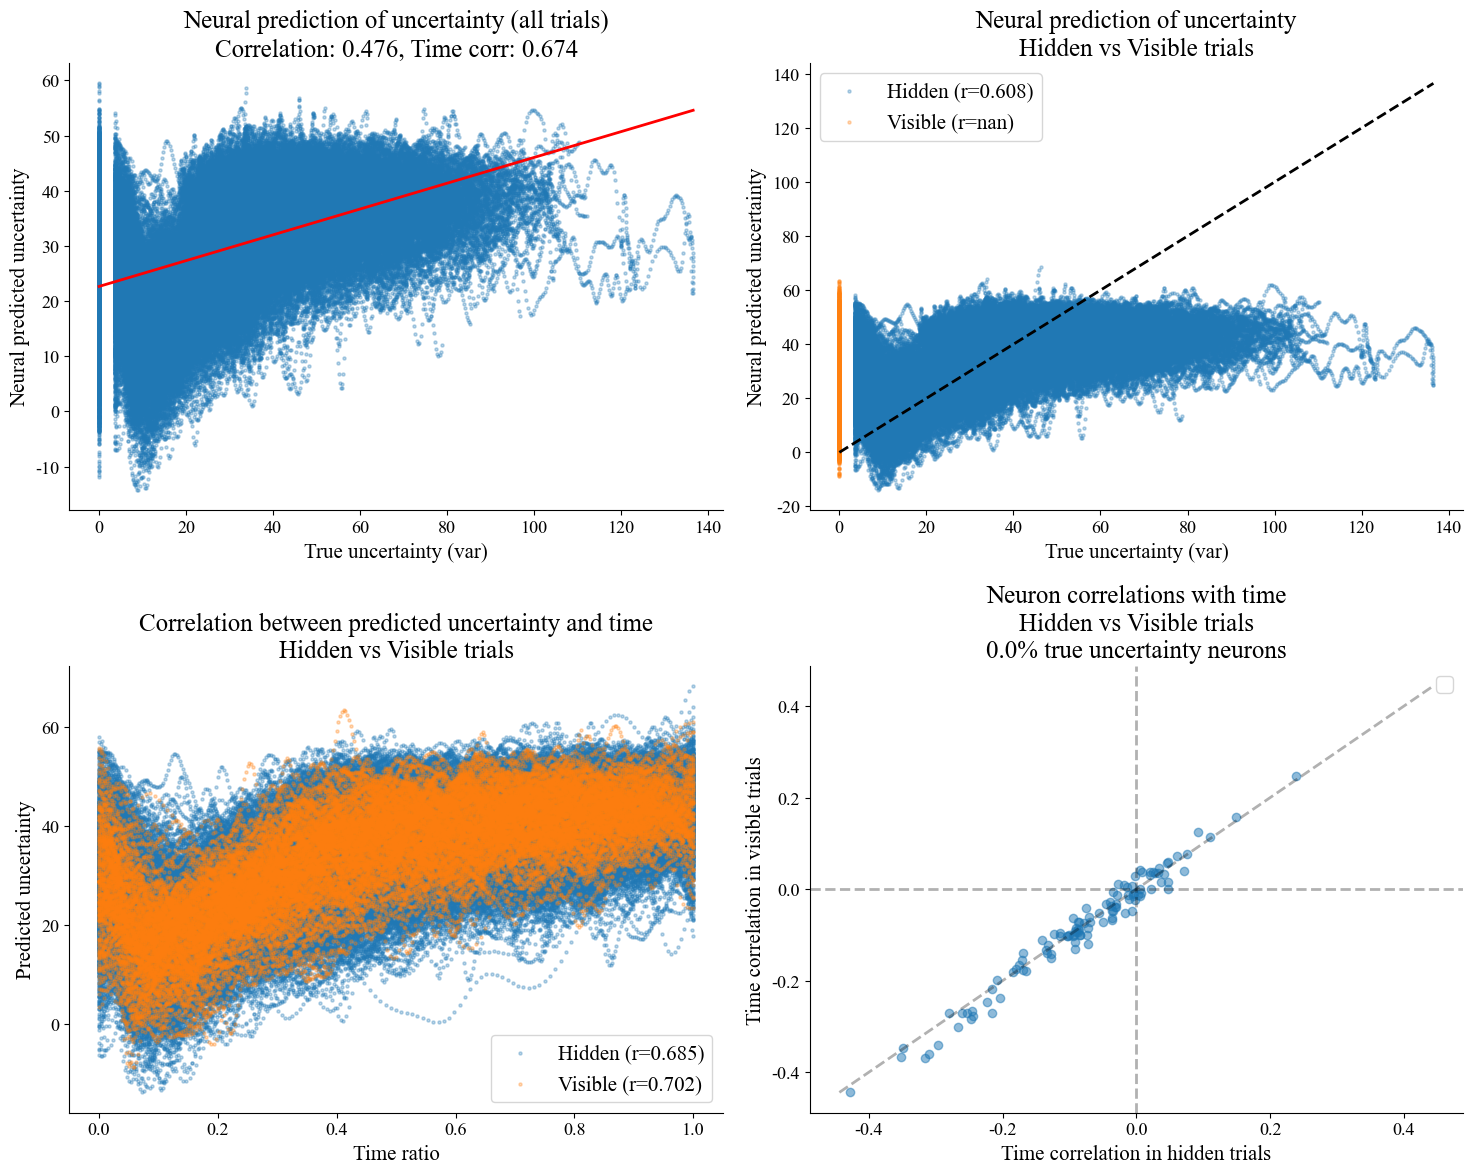

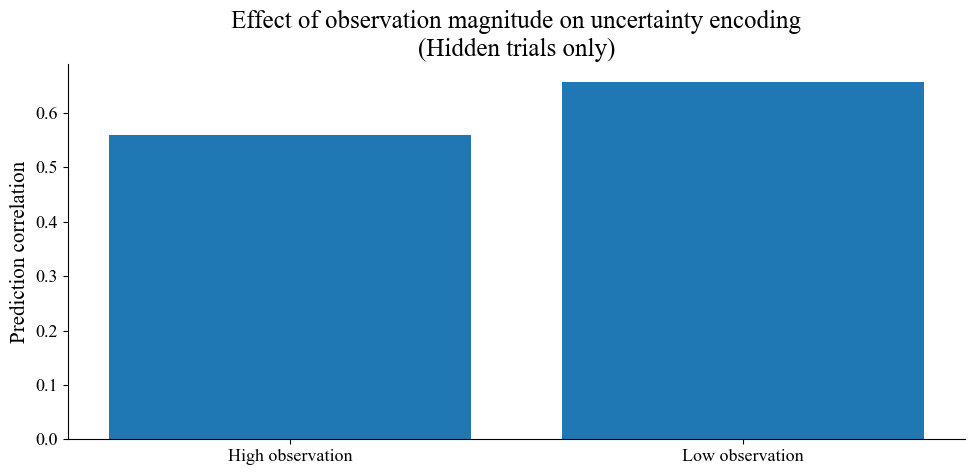


==== UNCERTAINTY ANALYSIS RESULTS ====
Session: 41, Number of neurons: 112

Overall uncertainty encoding:
  Neural prediction of uncertainty: r = 0.476 (p: 0.000e+00)
  Correlation with time: r = 0.674 (p: 0.000e+00)
  Neurons correlating more with uncertainty than time: 11.6%

Visibility condition analysis:
  Hidden trials model performance: r = 0.608 (p: 0.000e+00)
  Hidden model on visible trials: r = nan (p: nan)
  Time correlation in hidden trials: r = 0.685
  Time correlation in visible trials: r = 0.702
  Potential true uncertainty neurons: 0 (0.0%)

Observation magnitude effect (hidden trials):
  High observation correlation: r = 0.559
  Low observation correlation: r = 0.657
  Prediction is better during low observation periods


In [13]:
def analyze_uncertainty_with_visibility(df, session_id=41):
    """
    Analyze how neural activity encodes uncertainty differently in fully visible target trials
    versus trials with hidden targets for a specific session
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from scipy.stats import pearsonr
    from sklearn.model_selection import cross_val_predict
    
    # Filter to just the specified session
    print(f"Analyzing session {session_id}")
    sessdf = df[df.session == session_id]
    
    # Basic session information
    print(f"Number of trials: {len(sessdf)}")
    
    # Create timedf for this session (similar to your original code)
    timedf = pd.DataFrame({'timer': np.concatenate(sessdf.timer.to_numpy())})
    timedf['belief'] = np.concatenate(sessdf.belief_ff_hori.to_numpy())
    timedf['state'] = np.concatenate(sessdf.ff_hori.to_numpy())
    timedf['eye'] = np.concatenate(sessdf.eye_hori.to_numpy())
    timedf['timeratio'] = np.concatenate(sessdf.time_ratio.to_numpy())
    timedf['mv'] = np.concatenate(sessdf.mv.to_numpy())
    timedf['mw'] = np.concatenate(sessdf.mw.to_numpy())
    timedf['belief_heading'] = np.concatenate(sessdf.belief_heading.to_numpy())
    timedf['timer'] = np.concatenate(sessdf.timer.to_numpy())
    timedf['countdown'] = np.concatenate(sessdf.countdown.to_numpy())
    timedf['belief_angle_from_start'] = np.concatenate(sessdf.belief_angle_from_start.to_numpy())
    timedf['PPC'] = list(np.vstack(sessdf.PPC.to_numpy()))
    timedf['PPC_var'] = list(np.vstack(sessdf.PPC_var.to_numpy()))
    
    timedf['uncertainty'] = list(np.concatenate(sessdf.relcov.to_numpy()))
    
    # Extract trial information and visibility condition
    sessdf['fullon_t'] = sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
    sessdf['trial_t'] = sessdf.apply(lambda x: np.array([[x.trial]*len(x.mx)]).reshape(-1), axis=1)
    
    timedf['fullon'] = np.concatenate(sessdf.fullon_t.to_numpy())
    timedf['trial'] = np.concatenate(sessdf.trial_t.to_numpy())
    
    # Clean timedf
    timedf = timedf.dropna(subset=['eye', 'state', 'belief'])
    
    # Extract variables for analysis
    neural_data = np.stack(timedf.PPC.to_numpy())
    uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    uncertainty_var = uncertainty**2  # variance
    time_ratio = timedf.timeratio.to_numpy()
    observations = np.abs(timedf.mw.to_numpy())  # absolute angular velocity
    fullon = timedf.fullon.to_numpy()  # Target visibility
    trial_ids = timedf.trial.to_numpy()
    
    # Separate data by visibility condition
    visible_mask = fullon == 1
    hidden_mask = fullon == 0
    
    # Check if we have both visibility conditions
    print(f"Visible target data points: {np.sum(visible_mask)}")
    print(f"Hidden target data points: {np.sum(hidden_mask)}")
    
    # 1. First, analyze uncertainty encoding in neural data for all trials
    # Train a model to predict uncertainty from neural activity
    uncertainty_model = LinearRegression()
    predicted_uncertainty = cross_val_predict(uncertainty_model, neural_data, uncertainty_var, cv=5)
    all_uncertainty_corr, all_uncertainty_p = pearsonr(predicted_uncertainty, uncertainty_var)
    
    # Correlation between predicted uncertainty and time
    time_corr, time_p = pearsonr(predicted_uncertainty, time_ratio)
    
    # 2. Compare neuron-by-neuron correlations with uncertainty vs time
    neuron_uncertainty_corrs = []
    neuron_time_corrs = []
    
    for i in range(neural_data.shape[1]):
        u_corr, _ = pearsonr(neural_data[:, i], uncertainty_var)
        t_corr, _ = pearsonr(neural_data[:, i], time_ratio)
        
        neuron_uncertainty_corrs.append(u_corr)
        neuron_time_corrs.append(t_corr)
    
    # Identify neurons that correlate more with uncertainty than time
    uncertainty_dominant = np.abs(neuron_uncertainty_corrs) > np.abs(neuron_time_corrs)
    percent_uncertainty_dominant = np.mean(uncertainty_dominant) * 100
    
    # 3. Compare uncertainty encoding between hidden and visible trials
    # Only proceed if we have sufficient data for both conditions
    if np.sum(visible_mask) > 10 and np.sum(hidden_mask) > 10:
        # Extract data for each condition
        hidden_neural = neural_data[hidden_mask]
        hidden_uncertainty = uncertainty_var[hidden_mask]
        hidden_time = time_ratio[hidden_mask]
        
        visible_neural = neural_data[visible_mask]
        visible_uncertainty = uncertainty_var[visible_mask]
        visible_time = time_ratio[visible_mask]
        
        # Train model on hidden trials and test on both conditions
        hidden_model = LinearRegression()
        hidden_model.fit(hidden_neural, hidden_uncertainty)
        
        # Predict for both conditions
        hidden_pred = hidden_model.predict(hidden_neural)
        visible_pred = hidden_model.predict(visible_neural)
        
        # Calculate correlations
        hidden_corr, hidden_p = pearsonr(hidden_pred, hidden_uncertainty)
        visible_corr, visible_p = pearsonr(visible_pred, visible_uncertainty)
        
        # Correlation with time
        hidden_time_corr, _ = pearsonr(hidden_pred, hidden_time)
        visible_time_corr, _ = pearsonr(visible_pred, visible_time)
        
        # 4. Examine neuron-by-neuron correlations with time across visibility conditions
        neuron_hidden_time_corrs = []
        neuron_visible_time_corrs = []
        
        for i in range(neural_data.shape[1]):
            # Skip if insufficient data
            if len(hidden_neural) > 5 and len(visible_neural) > 5:
                h_time_corr, _ = pearsonr(hidden_neural[:, i], hidden_time)
                v_time_corr, _ = pearsonr(visible_neural[:, i], visible_time)
                
                neuron_hidden_time_corrs.append(h_time_corr)
                neuron_visible_time_corrs.append(v_time_corr)
        
        # Identify potential true uncertainty neurons
        # These neurons should correlate positively with time in hidden trials
        # but not in visible trials (where true uncertainty doesn't increase with time)
        true_uncertainty_neurons = []
        for i in range(len(neuron_hidden_time_corrs)):
            if (neuron_hidden_time_corrs[i] > 0.3 and 
                (abs(neuron_visible_time_corrs[i]) < 0.1 or neuron_visible_time_corrs[i] < 0)):
                true_uncertainty_neurons.append(i)
        
        true_uncertainty_percent = len(true_uncertainty_neurons) / neural_data.shape[1] * 100
        
        # 5. Observation magnitude effect on uncertainty encoding
        # Divide into high vs low observation periods
        median_obs = np.median(observations)
        high_obs_mask = observations > median_obs
        low_obs_mask = observations <= median_obs
        
        # Further split by visibility
        high_obs_hidden = high_obs_mask & hidden_mask
        low_obs_hidden = low_obs_mask & hidden_mask
        
        # Train models for high/low observation in hidden trials
        if np.sum(high_obs_hidden) > 10 and np.sum(low_obs_hidden) > 10:
            high_obs_model = LinearRegression()
            high_obs_model.fit(neural_data[high_obs_hidden], uncertainty_var[high_obs_hidden])
            high_obs_pred = high_obs_model.predict(neural_data[high_obs_hidden])
            high_obs_corr, _ = pearsonr(high_obs_pred, uncertainty_var[high_obs_hidden])
            
            low_obs_model = LinearRegression()
            low_obs_model.fit(neural_data[low_obs_hidden], uncertainty_var[low_obs_hidden])
            low_obs_pred = low_obs_model.predict(neural_data[low_obs_hidden])
            low_obs_corr, _ = pearsonr(low_obs_pred, uncertainty_var[low_obs_hidden])
            
            has_obs_analysis = True
        else:
            has_obs_analysis = False
        
        # Create visualization
        plt.figure(figsize=(15, 12))
        
        # Plot 1: Overall uncertainty prediction
        plt.subplot(2, 2, 1)
        plt.scatter(uncertainty_var, predicted_uncertainty, alpha=0.3, s=5)
        
        # Add best fit line
        b, a = np.polyfit(uncertainty_var, predicted_uncertainty, deg=1)
        x_line = np.linspace(min(uncertainty_var), max(uncertainty_var), 100)
        y_line = a + b * x_line
        plt.plot(x_line, y_line, color='red')
        
        plt.title(f'Neural prediction of uncertainty (all trials)\nCorrelation: {all_uncertainty_corr:.3f}, Time corr: {time_corr:.3f}')
        plt.xlabel('True uncertainty (var)')
        plt.ylabel('Neural predicted uncertainty')
        
        # Plot 2: Model performance across visibility conditions
        plt.subplot(2, 2, 2)
        plt.scatter(hidden_uncertainty, hidden_pred, alpha=0.3, s=5, label=f'Hidden (r={hidden_corr:.3f})')
        plt.scatter(visible_uncertainty, visible_pred, alpha=0.3, s=5, label=f'Visible (r={visible_corr:.3f})')
        
        # Add unity line
        max_val = max(max(hidden_uncertainty), max(visible_uncertainty))
        min_val = min(min(hidden_uncertainty), min(visible_uncertainty))
        plt.plot([min_val, max_val], [min_val, max_val], 'k--')
        
        plt.title('Neural prediction of uncertainty\nHidden vs Visible trials')
        plt.xlabel('True uncertainty (var)')
        plt.ylabel('Neural predicted uncertainty')
        plt.legend()
        
        # Plot 3: Time correlation across visibility conditions
        plt.subplot(2, 2, 3)
        plt.scatter(hidden_time, hidden_pred, alpha=0.3, s=5, label=f'Hidden (r={hidden_time_corr:.3f})')
        plt.scatter(visible_time, visible_pred, alpha=0.3, s=5, label=f'Visible (r={visible_time_corr:.3f})')
        
        plt.title('Correlation between predicted uncertainty and time\nHidden vs Visible trials')
        plt.xlabel('Time ratio')
        plt.ylabel('Predicted uncertainty')
        plt.legend()
        
        # Plot 4: Neuron correlations with time across visibility conditions
        plt.subplot(2, 2, 4)
        plt.scatter(neuron_hidden_time_corrs, neuron_visible_time_corrs, alpha=0.5)
        
        # Highlight true uncertainty neurons
        if len(true_uncertainty_neurons) > 0:
            true_unc_hidden = [neuron_hidden_time_corrs[i] for i in true_uncertainty_neurons]
            true_unc_visible = [neuron_visible_time_corrs[i] for i in true_uncertainty_neurons]
            plt.scatter(true_unc_hidden, true_unc_visible, color='red', s=50, alpha=0.7, 
                       label=f'True unc. neurons ({len(true_uncertainty_neurons)})')
        
        plt.axhline(0, color='k', linestyle='--', alpha=0.3)
        plt.axvline(0, color='k', linestyle='--', alpha=0.3)
        
        # Add diagonal
        max_val = max(max(np.abs(neuron_hidden_time_corrs)), max(np.abs(neuron_visible_time_corrs)))
        plt.plot([-max_val, max_val], [-max_val, max_val], 'k--', alpha=0.3)
        
        plt.title(f'Neuron correlations with time\nHidden vs Visible trials\n{true_uncertainty_percent:.1f}% true uncertainty neurons')
        plt.xlabel('Time correlation in hidden trials')
        plt.ylabel('Time correlation in visible trials')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        # If we have observation analysis, create another figure
        if has_obs_analysis:
            plt.figure(figsize=(10, 5))
            
            # Plot: Observation magnitude effect
            plt.bar(['High observation', 'Low observation'], [high_obs_corr, low_obs_corr])
            plt.title('Effect of observation magnitude on uncertainty encoding\n(Hidden trials only)')
            plt.ylabel('Prediction correlation')
            
            plt.tight_layout()
            plt.show()
        
        # Print key results
        print("\n==== UNCERTAINTY ANALYSIS RESULTS ====")
        print(f"Session: {session_id}, Number of neurons: {neural_data.shape[1]}")
        
        print("\nOverall uncertainty encoding:")
        print(f"  Neural prediction of uncertainty: r = {all_uncertainty_corr:.3f} (p: {all_uncertainty_p:.3e})")
        print(f"  Correlation with time: r = {time_corr:.3f} (p: {time_p:.3e})")
        print(f"  Neurons correlating more with uncertainty than time: {percent_uncertainty_dominant:.1f}%")
        
        print("\nVisibility condition analysis:")
        print(f"  Hidden trials model performance: r = {hidden_corr:.3f} (p: {hidden_p:.3e})")
        print(f"  Hidden model on visible trials: r = {visible_corr:.3f} (p: {visible_p:.3e})")
        print(f"  Time correlation in hidden trials: r = {hidden_time_corr:.3f}")
        print(f"  Time correlation in visible trials: r = {visible_time_corr:.3f}")
        print(f"  Potential true uncertainty neurons: {len(true_uncertainty_neurons)} ({true_uncertainty_percent:.1f}%)")
        
        if has_obs_analysis:
            print("\nObservation magnitude effect (hidden trials):")
            print(f"  High observation correlation: r = {high_obs_corr:.3f}")
            print(f"  Low observation correlation: r = {low_obs_corr:.3f}")
            print(f"  Prediction is {'better' if low_obs_corr > high_obs_corr else 'worse'} during low observation periods")
        
        # List some true uncertainty neurons if available
        if len(true_uncertainty_neurons) > 0:
            print("\nTop true uncertainty neurons (indices):")
            print(true_uncertainty_neurons[:10])
    else:
        print("\nInsufficient data for visibility condition analysis")
    
    return {
        'n_neurons': neural_data.shape[1],
        'uncertainty_corr': all_uncertainty_corr,
        'time_corr': time_corr,
        'percent_uncertainty_dominant': percent_uncertainty_dominant
    }

# Analyze session 41 as in your original code
session_results = analyze_uncertainty_with_visibility(df, session_id=41)

Found 5 unique sessions

===== Analyzing Session 38 =====
Number of trials: 616
Visible target data points: 16289
Hidden target data points: 149608

Session 38 Summary:
  Number of neurons: 86
  Neural prediction of uncertainty: r = 0.448
  Correlation with time: r = 0.624
  Neurons correlating more with uncertainty than time: 12.8%
  Hidden trials model performance: r = 0.575
  Visible trials model performance: r = nan
  True uncertainty neurons: 0.0%

===== Analyzing Session 40 =====
Number of trials: 201
Visible target data points: 5004
Hidden target data points: 49514

Session 40 Summary:
  Number of neurons: 66
  Neural prediction of uncertainty: r = 0.026
  Correlation with time: r = 0.040
  Neurons correlating more with uncertainty than time: 30.3%
  Hidden trials model performance: r = 0.598
  Visible trials model performance: r = nan
  True uncertainty neurons: 0.0%

===== Analyzing Session 41 =====
Number of trials: 1538
Visible target data points: 42544
Hidden target data po

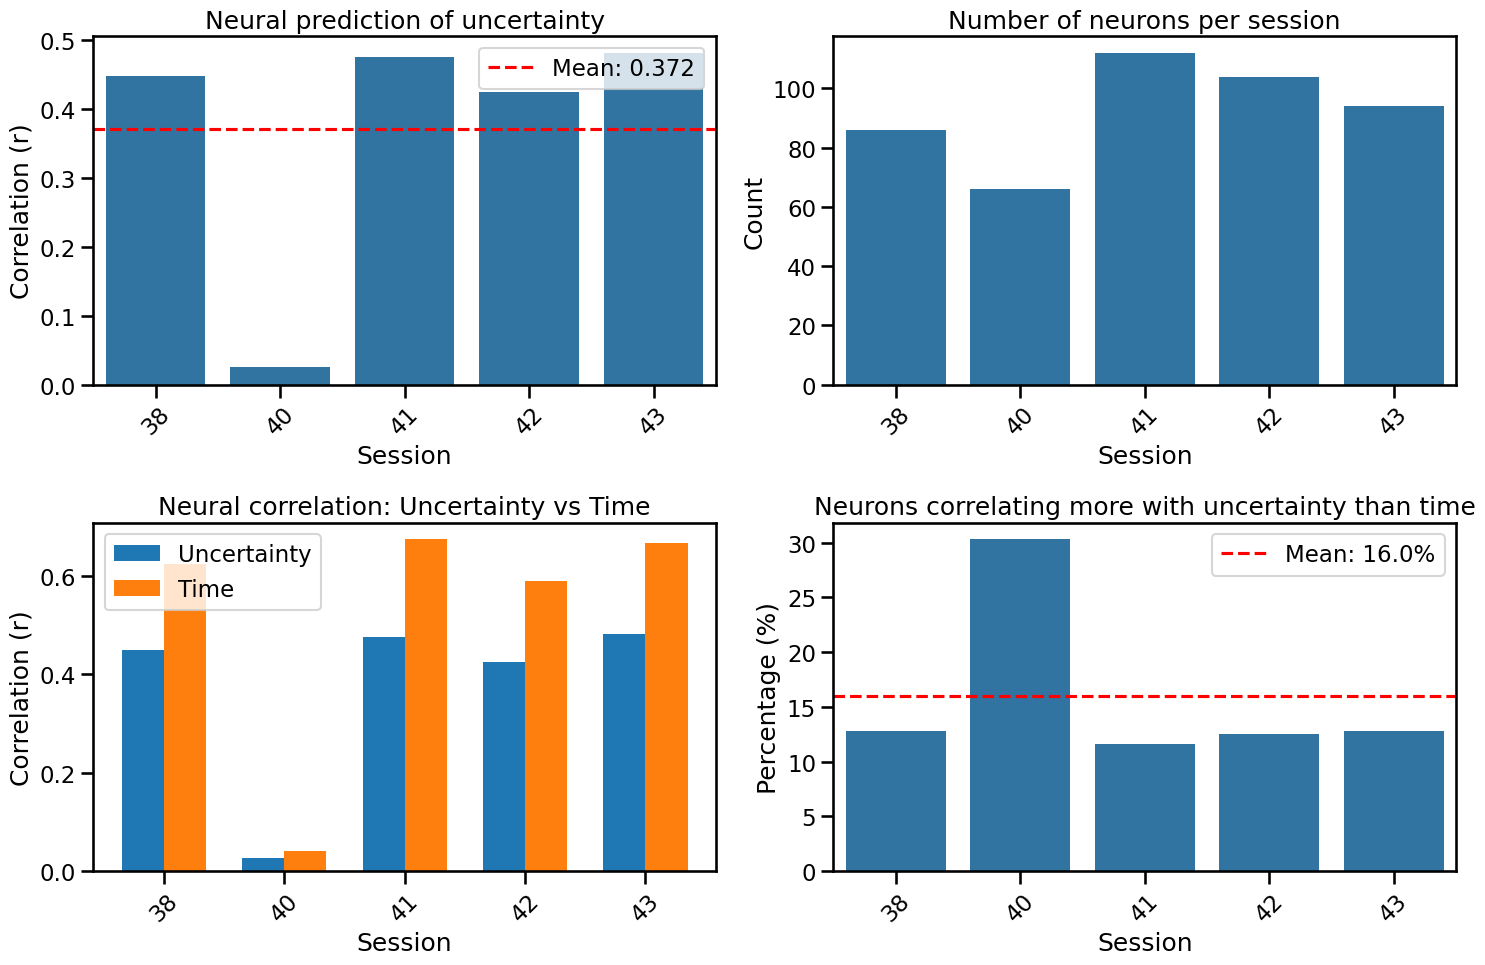

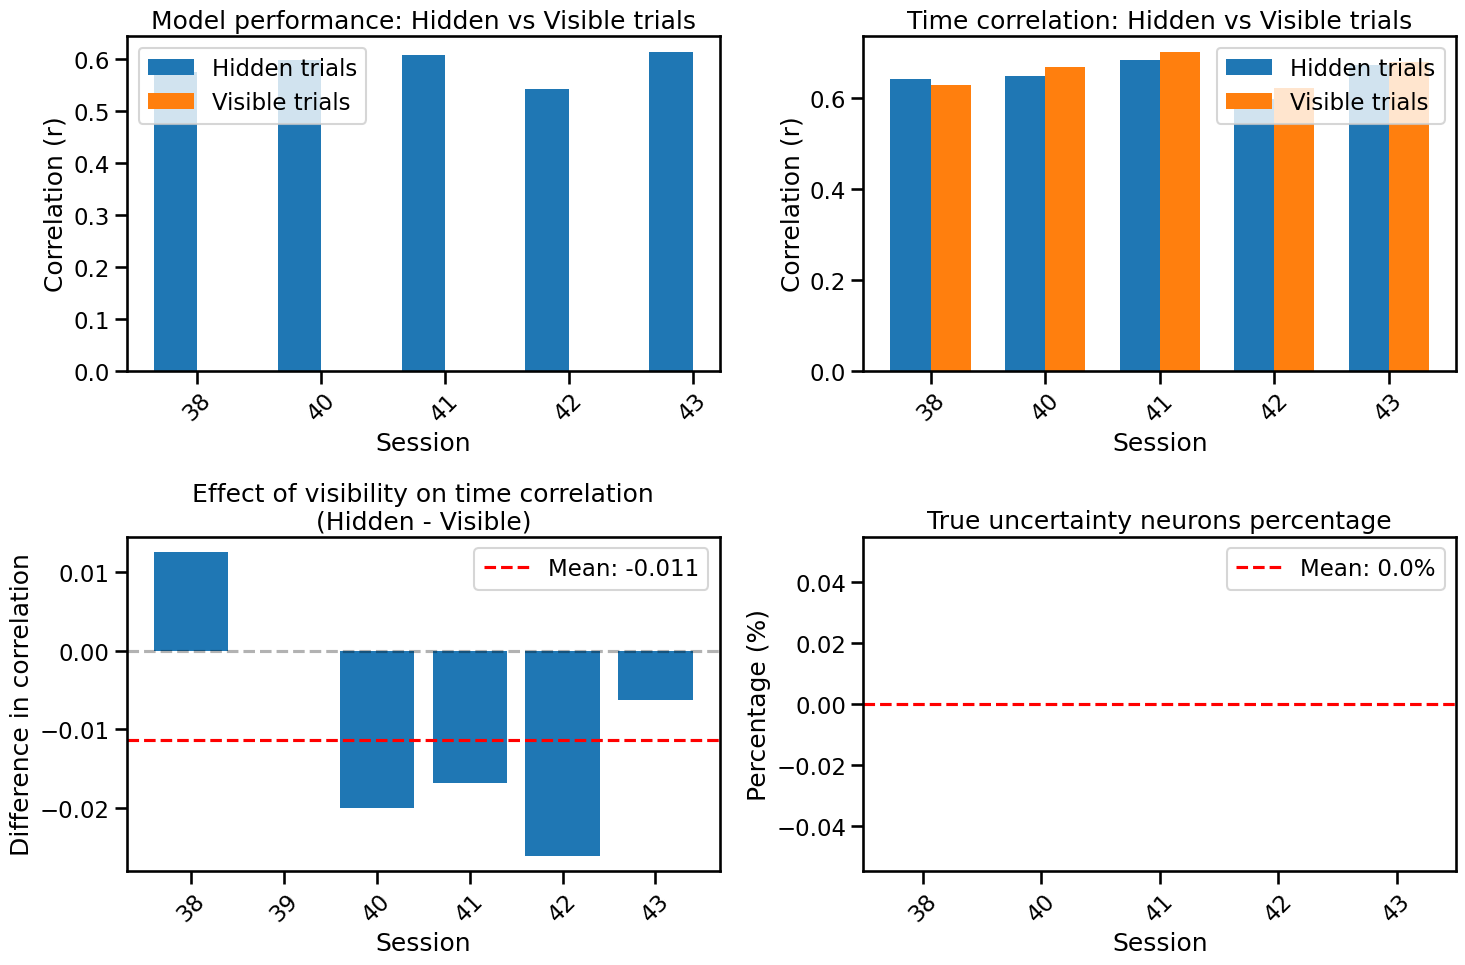

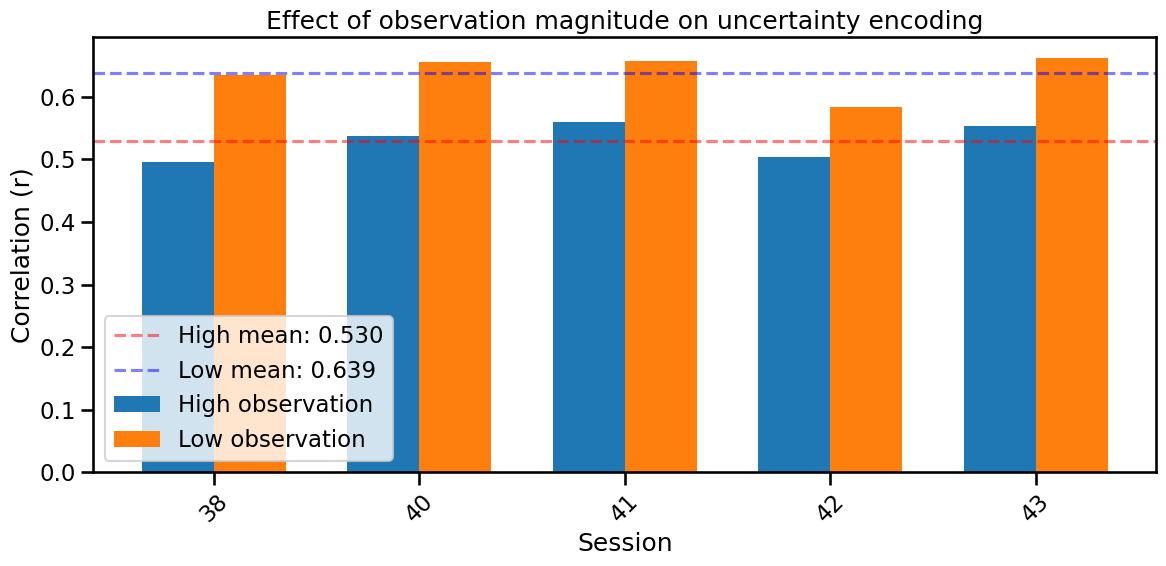


==== CROSS-SESSION SUMMARY STATISTICS ====
Total sessions analyzed: 5

Uncertainty encoding:
  Mean correlation: 0.372 ± 0.195
  Range: 0.026 to 0.482

Time correlation:
  Mean correlation: 0.519 ± 0.270

Uncertainty-dominant neurons:
  Mean percentage: 16.0% ± 8.0%

Visibility analysis (sessions with visibility data):
  Mean hidden trials correlation: 0.587 ± 0.029
  Mean visible trials correlation: nan ± nan
  Mean hidden-visible time correlation difference: -0.011
  Mean true uncertainty neurons: 0.0% ± 0.0%

Observation magnitude analysis:
  Mean high observation correlation: 0.530 ± 0.029
  Mean low observation correlation: 0.639 ± 0.032
  Low observation better in 5/5 sessions (100.0%)


In [14]:
def analyze_uncertainty_across_all_sessions(df):
    """
    Analyze neural encoding of uncertainty across all available sessions,
    collecting key metrics for comparison
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from scipy.stats import pearsonr
    from sklearn.model_selection import cross_val_predict
    import pandas as pd
    
    # Get unique sessions
    all_sessions = sorted(df.session.unique())
    print(f"Found {len(all_sessions)} unique sessions")
    
    # Initialize storage for results
    results = {
        'session_id': [],
        'n_neurons': [],
        'n_trials': [],
        'uncertainty_corr': [],
        'time_corr': [],
        'percent_uncertainty_dominant': [],
        'has_visibility_data': [],
        'hidden_corr': [],
        'visible_corr': [],
        'hidden_time_corr': [],
        'visible_time_corr': [],
        'true_uncertainty_percent': [],
        'has_obs_analysis': [],
        'high_obs_corr': [],
        'low_obs_corr': []
    }
    
    # Process each session
    for session_id in all_sessions:
        print(f"\n===== Analyzing Session {session_id} =====")
        
        # Filter to this session
        sessdf = df[df.session == session_id]
        
        # Skip if too few trials
        if len(sessdf) < 5:
            print(f"Session {session_id} has too few trials. Skipping.")
            continue
        
        # Basic session information
        print(f"Number of trials: {len(sessdf)}")
        
        try:
            # Create timedf for this session (similar to original code)
            timedf = pd.DataFrame({'timer': np.concatenate(sessdf.timer.to_numpy())})
            timedf['belief'] = np.concatenate(sessdf.belief_ff_hori.to_numpy())
            timedf['state'] = np.concatenate(sessdf.ff_hori.to_numpy())
            timedf['eye'] = np.concatenate(sessdf.eye_hori.to_numpy())
            timedf['timeratio'] = np.concatenate(sessdf.time_ratio.to_numpy())
            timedf['mv'] = np.concatenate(sessdf.mv.to_numpy())
            timedf['mw'] = np.concatenate(sessdf.mw.to_numpy())
            timedf['belief_heading'] = np.concatenate(sessdf.belief_heading.to_numpy())
            timedf['timer'] = np.concatenate(sessdf.timer.to_numpy())
            timedf['countdown'] = np.concatenate(sessdf.countdown.to_numpy())
            timedf['belief_angle_from_start'] = np.concatenate(sessdf.belief_angle_from_start.to_numpy())
            timedf['PPC'] = list(np.vstack(sessdf.PPC.to_numpy()))
            timedf['PPC_var'] = list(np.vstack(sessdf.PPC_var.to_numpy()))
            
            timedf['uncertainty'] = list(np.concatenate(sessdf.relcov.to_numpy()))
            
            # Extract trial information and visibility condition
            sessdf['fullon_t'] = sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
            sessdf['trial_t'] = sessdf.apply(lambda x: np.array([[x.trial]*len(x.mx)]).reshape(-1), axis=1)
            
            timedf['fullon'] = np.concatenate(sessdf.fullon_t.to_numpy())
            timedf['trial'] = np.concatenate(sessdf.trial_t.to_numpy())
            
            # Clean timedf
            timedf = timedf.dropna(subset=['eye', 'state', 'belief'])
            
            # Extract variables for analysis
            neural_data = np.stack(timedf.PPC.to_numpy())
            uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
            uncertainty_var = uncertainty**2  # variance
            time_ratio = timedf.timeratio.to_numpy()
            observations = np.abs(timedf.mw.to_numpy())  # absolute angular velocity
            fullon = timedf.fullon.to_numpy()  # Target visibility
            trial_ids = timedf.trial.to_numpy()
            
            # Separate data by visibility condition
            visible_mask = fullon == 1
            hidden_mask = fullon == 0
            
            # Check if we have both visibility conditions
            print(f"Visible target data points: {np.sum(visible_mask)}")
            print(f"Hidden target data points: {np.sum(hidden_mask)}")
            
            # Flag for sufficient visibility data
            has_visibility_data = (np.sum(visible_mask) > 10) and (np.sum(hidden_mask) > 10)
            
            # === 1. Analyze overall uncertainty encoding ===
            uncertainty_model = LinearRegression()
            predicted_uncertainty = cross_val_predict(uncertainty_model, neural_data, uncertainty_var, cv=5)
            all_uncertainty_corr, all_uncertainty_p = pearsonr(predicted_uncertainty, uncertainty_var)
            
            # Correlation with time
            time_corr, time_p = pearsonr(predicted_uncertainty, time_ratio)
            
            # === 2. Compare neuron correlations with uncertainty vs time ===
            neuron_uncertainty_corrs = []
            neuron_time_corrs = []
            
            for i in range(neural_data.shape[1]):
                u_corr, _ = pearsonr(neural_data[:, i], uncertainty_var)
                t_corr, _ = pearsonr(neural_data[:, i], time_ratio)
                
                neuron_uncertainty_corrs.append(u_corr)
                neuron_time_corrs.append(t_corr)
            
            # Calculate percentage of uncertainty-dominant neurons
            uncertainty_dominant = np.abs(neuron_uncertainty_corrs) > np.abs(neuron_time_corrs)
            percent_uncertainty_dominant = np.mean(uncertainty_dominant) * 100
            
            # Store basic results
            results['session_id'].append(session_id)
            results['n_neurons'].append(neural_data.shape[1])
            results['n_trials'].append(len(sessdf))
            results['uncertainty_corr'].append(all_uncertainty_corr)
            results['time_corr'].append(time_corr)
            results['percent_uncertainty_dominant'].append(percent_uncertainty_dominant)
            results['has_visibility_data'].append(has_visibility_data)
            
            # === 3. Visibility analysis (if sufficient data) ===
            if has_visibility_data:
                # Extract data for each condition
                hidden_neural = neural_data[hidden_mask]
                hidden_uncertainty = uncertainty_var[hidden_mask]
                hidden_time = time_ratio[hidden_mask]
                
                visible_neural = neural_data[visible_mask]
                visible_uncertainty = uncertainty_var[visible_mask]
                visible_time = time_ratio[visible_mask]
                
                # Train model on hidden trials and test on both conditions
                hidden_model = LinearRegression()
                hidden_model.fit(hidden_neural, hidden_uncertainty)
                
                # Predict for both conditions
                hidden_pred = hidden_model.predict(hidden_neural)
                visible_pred = hidden_model.predict(visible_neural)
                
                # Calculate correlations
                hidden_corr, hidden_p = pearsonr(hidden_pred, hidden_uncertainty)
                visible_corr, visible_p = pearsonr(visible_pred, visible_uncertainty)
                
                # Correlation with time
                hidden_time_corr, _ = pearsonr(hidden_pred, hidden_time)
                visible_time_corr, _ = pearsonr(visible_pred, visible_time)
                
                # Neuron-by-neuron analysis
                neuron_hidden_time_corrs = []
                neuron_visible_time_corrs = []
                
                for i in range(neural_data.shape[1]):
                    if len(hidden_neural) > 5 and len(visible_neural) > 5:
                        h_time_corr, _ = pearsonr(hidden_neural[:, i], hidden_time)
                        v_time_corr, _ = pearsonr(visible_neural[:, i], visible_time)
                        
                        neuron_hidden_time_corrs.append(h_time_corr)
                        neuron_visible_time_corrs.append(v_time_corr)
                
                # Identify true uncertainty neurons
                true_uncertainty_neurons = []
                for i in range(len(neuron_hidden_time_corrs)):
                    if (neuron_hidden_time_corrs[i] > 0.3 and 
                        (abs(neuron_visible_time_corrs[i]) < 0.1 or neuron_visible_time_corrs[i] < 0)):
                        true_uncertainty_neurons.append(i)
                
                true_uncertainty_percent = len(true_uncertainty_neurons) / neural_data.shape[1] * 100
                
                # Store visibility results
                results['hidden_corr'].append(hidden_corr)
                results['visible_corr'].append(visible_corr)
                results['hidden_time_corr'].append(hidden_time_corr)
                results['visible_time_corr'].append(visible_time_corr)
                results['true_uncertainty_percent'].append(true_uncertainty_percent)
            else:
                # Fill with NaN if no visibility data
                results['hidden_corr'].append(np.nan)
                results['visible_corr'].append(np.nan)
                results['hidden_time_corr'].append(np.nan)
                results['visible_time_corr'].append(np.nan)
                results['true_uncertainty_percent'].append(np.nan)
            
            # === 4. Observation magnitude analysis ===
            # Divide into high vs low observation periods
            median_obs = np.median(observations)
            high_obs_mask = observations > median_obs
            low_obs_mask = observations <= median_obs
            
            # Further split by visibility (if applicable)
            if has_visibility_data:
                high_obs_hidden = high_obs_mask & hidden_mask
                low_obs_hidden = low_obs_mask & hidden_mask
                
                has_obs_analysis = (np.sum(high_obs_hidden) > 10) and (np.sum(low_obs_hidden) > 10)
            else:
                # Just use high/low obs without visibility split
                high_obs_hidden = high_obs_mask
                low_obs_hidden = low_obs_mask
                
                has_obs_analysis = (np.sum(high_obs_hidden) > 10) and (np.sum(low_obs_hidden) > 10)
            
            if has_obs_analysis:
                # Train models for high/low observation
                high_obs_model = LinearRegression()
                high_obs_model.fit(neural_data[high_obs_hidden], uncertainty_var[high_obs_hidden])
                high_obs_pred = high_obs_model.predict(neural_data[high_obs_hidden])
                high_obs_corr, _ = pearsonr(high_obs_pred, uncertainty_var[high_obs_hidden])
                
                low_obs_model = LinearRegression()
                low_obs_model.fit(neural_data[low_obs_hidden], uncertainty_var[low_obs_hidden])
                low_obs_pred = low_obs_model.predict(neural_data[low_obs_hidden])
                low_obs_corr, _ = pearsonr(low_obs_pred, uncertainty_var[low_obs_hidden])
                
                # Store observation analysis results
                results['has_obs_analysis'].append(True)
                results['high_obs_corr'].append(high_obs_corr)
                results['low_obs_corr'].append(low_obs_corr)
            else:
                results['has_obs_analysis'].append(False)
                results['high_obs_corr'].append(np.nan)
                results['low_obs_corr'].append(np.nan)
            
            # Print session summary
            print(f"\nSession {session_id} Summary:")
            print(f"  Number of neurons: {neural_data.shape[1]}")
            print(f"  Neural prediction of uncertainty: r = {all_uncertainty_corr:.3f}")
            print(f"  Correlation with time: r = {time_corr:.3f}")
            print(f"  Neurons correlating more with uncertainty than time: {percent_uncertainty_dominant:.1f}%")
            
            if has_visibility_data:
                print(f"  Hidden trials model performance: r = {hidden_corr:.3f}")
                print(f"  Visible trials model performance: r = {visible_corr:.3f}")
                print(f"  True uncertainty neurons: {true_uncertainty_percent:.1f}%")
        
        except Exception as e:
            print(f"Error processing session {session_id}: {e}")
            continue
    
    # Convert results to DataFrame for easier manipulation
    results_df = pd.DataFrame(results)
    
    # Create summary visualizations across all sessions
    if len(results_df) > 0:
        plot_cross_session_summary(results_df)
    
    return results_df

def plot_cross_session_summary(results_df):
    """
    Create summary visualizations for cross-session analysis
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns
    
    # Set style
    plt.style.use('default')
    sns.set_context("talk")
    
    # Figure 1: Basic uncertainty encoding metrics across sessions
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Uncertainty prediction performance
    plt.subplot(2, 2, 1)
    ax = sns.barplot(x='session_id', y='uncertainty_corr', data=results_df)
    plt.title('Neural prediction of uncertainty')
    plt.xlabel('Session')
    plt.ylabel('Correlation (r)')
    plt.xticks(rotation=45)
    
    # Add mean line
    mean_corr = results_df['uncertainty_corr'].mean()
    plt.axhline(mean_corr, color='r', linestyle='--', label=f'Mean: {mean_corr:.3f}')
    plt.legend()
    
    # Plot 2: Number of neurons per session
    plt.subplot(2, 2, 2)
    ax = sns.barplot(x='session_id', y='n_neurons', data=results_df)
    plt.title('Number of neurons per session')
    plt.xlabel('Session')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    # Plot 3: Uncertainty vs time correlation
    plt.subplot(2, 2, 3)
    
    # Create data for grouped bar plot
    sessions = results_df['session_id']
    uncertainty_corrs = results_df['uncertainty_corr']
    time_corrs = results_df['time_corr']
    
    x = np.arange(len(sessions))
    width = 0.35
    
    plt.bar(x - width/2, uncertainty_corrs, width, label='Uncertainty')
    plt.bar(x + width/2, time_corrs, width, label='Time')
    
    plt.title('Neural correlation: Uncertainty vs Time')
    plt.xlabel('Session')
    plt.ylabel('Correlation (r)')
    plt.xticks(x, sessions, rotation=45)
    plt.legend()
    
    # Plot 4: Percentage of uncertainty-dominant neurons
    plt.subplot(2, 2, 4)
    ax = sns.barplot(x='session_id', y='percent_uncertainty_dominant', data=results_df)
    plt.title('Neurons correlating more with uncertainty than time')
    plt.xlabel('Session')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45)
    
    # Add mean line
    mean_percent = results_df['percent_uncertainty_dominant'].mean()
    plt.axhline(mean_percent, color='r', linestyle='--', label=f'Mean: {mean_percent:.1f}%')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Figure 2: Visibility condition analysis (for sessions with visibility data)
    vis_df = results_df[results_df['has_visibility_data'] == True].reset_index(drop=True)
    
    if len(vis_df) > 0:
        plt.figure(figsize=(15, 10))
        
        # Plot 1: Model performance in hidden vs visible trials
        plt.subplot(2, 2, 1)
        
        sessions = vis_df['session_id']
        hidden_corrs = vis_df['hidden_corr']
        visible_corrs = vis_df['visible_corr']
        
        x = np.arange(len(sessions))
        width = 0.35
        
        plt.bar(x - width/2, hidden_corrs, width, label='Hidden trials')
        plt.bar(x + width/2, visible_corrs, width, label='Visible trials')
        
        plt.title('Model performance: Hidden vs Visible trials')
        plt.xlabel('Session')
        plt.ylabel('Correlation (r)')
        plt.xticks(x, sessions, rotation=45)
        plt.legend()
        
        # Plot 2: Time correlation in hidden vs visible trials
        plt.subplot(2, 2, 2)
        
        hidden_time_corrs = vis_df['hidden_time_corr']
        visible_time_corrs = vis_df['visible_time_corr']
        
        plt.bar(x - width/2, hidden_time_corrs, width, label='Hidden trials')
        plt.bar(x + width/2, visible_time_corrs, width, label='Visible trials')
        
        plt.title('Time correlation: Hidden vs Visible trials')
        plt.xlabel('Session')
        plt.ylabel('Correlation (r)')
        plt.xticks(x, sessions, rotation=45)
        plt.legend()
        
        # Plot 3: Effect of visibility on time correlation
        plt.subplot(2, 2, 3)
        time_diff = hidden_time_corrs - visible_time_corrs
        
        plt.bar(sessions, time_diff)
        plt.axhline(0, color='k', linestyle='--', alpha=0.3)
        
        plt.title('Effect of visibility on time correlation\n(Hidden - Visible)')
        plt.xlabel('Session')
        plt.ylabel('Difference in correlation')
        plt.xticks(rotation=45)
        
        # Add mean line
        mean_diff = np.mean(time_diff)
        plt.axhline(mean_diff, color='r', linestyle='--', label=f'Mean: {mean_diff:.3f}')
        plt.legend()
        
        # Plot 4: Percentage of true uncertainty neurons
        plt.subplot(2, 2, 4)
        ax = sns.barplot(x='session_id', y='true_uncertainty_percent', data=vis_df)
        plt.title('True uncertainty neurons percentage')
        plt.xlabel('Session')
        plt.ylabel('Percentage (%)')
        plt.xticks(rotation=45)
        
        # Add mean line
        mean_percent = vis_df['true_uncertainty_percent'].mean()
        plt.axhline(mean_percent, color='r', linestyle='--', label=f'Mean: {mean_percent:.1f}%')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    # Figure 3: Observation magnitude analysis (for sessions with obs analysis)
    obs_df = results_df[results_df['has_obs_analysis'] == True].reset_index(drop=True)
    
    if len(obs_df) > 0:
        plt.figure(figsize=(12, 6))
        
        sessions = obs_df['session_id']
        high_obs_corrs = obs_df['high_obs_corr']
        low_obs_corrs = obs_df['low_obs_corr']
        
        x = np.arange(len(sessions))
        width = 0.35
        
        plt.bar(x - width/2, high_obs_corrs, width, label='High observation')
        plt.bar(x + width/2, low_obs_corrs, width, label='Low observation')
        
        plt.title('Effect of observation magnitude on uncertainty encoding')
        plt.xlabel('Session')
        plt.ylabel('Correlation (r)')
        plt.xticks(x, sessions, rotation=45)
        plt.legend()
        
        # Add mean lines
        high_mean = np.mean(high_obs_corrs)
        low_mean = np.mean(low_obs_corrs)
        plt.axhline(high_mean, color='r', linestyle='--', alpha=0.5, label=f'High mean: {high_mean:.3f}')
        plt.axhline(low_mean, color='b', linestyle='--', alpha=0.5, label=f'Low mean: {low_mean:.3f}')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    # Print overall summary statistics
    print("\n==== CROSS-SESSION SUMMARY STATISTICS ====")
    print(f"Total sessions analyzed: {len(results_df)}")
    
    print("\nUncertainty encoding:")
    print(f"  Mean correlation: {results_df['uncertainty_corr'].mean():.3f} ± {results_df['uncertainty_corr'].std():.3f}")
    print(f"  Range: {results_df['uncertainty_corr'].min():.3f} to {results_df['uncertainty_corr'].max():.3f}")
    
    print("\nTime correlation:")
    print(f"  Mean correlation: {results_df['time_corr'].mean():.3f} ± {results_df['time_corr'].std():.3f}")
    
    print("\nUncertainty-dominant neurons:")
    print(f"  Mean percentage: {results_df['percent_uncertainty_dominant'].mean():.1f}% ± {results_df['percent_uncertainty_dominant'].std():.1f}%")
    
    if len(vis_df) > 0:
        print("\nVisibility analysis (sessions with visibility data):")
        print(f"  Mean hidden trials correlation: {vis_df['hidden_corr'].mean():.3f} ± {vis_df['hidden_corr'].std():.3f}")
        print(f"  Mean visible trials correlation: {vis_df['visible_corr'].mean():.3f} ± {vis_df['visible_corr'].std():.3f}")
        print(f"  Mean hidden-visible time correlation difference: {(vis_df['hidden_time_corr'] - vis_df['visible_time_corr']).mean():.3f}")
        print(f"  Mean true uncertainty neurons: {vis_df['true_uncertainty_percent'].mean():.1f}% ± {vis_df['true_uncertainty_percent'].std():.1f}%")
    
    if len(obs_df) > 0:
        print("\nObservation magnitude analysis:")
        print(f"  Mean high observation correlation: {obs_df['high_obs_corr'].mean():.3f} ± {obs_df['high_obs_corr'].std():.3f}")
        print(f"  Mean low observation correlation: {obs_df['low_obs_corr'].mean():.3f} ± {obs_df['low_obs_corr'].std():.3f}")
        better_count = sum(obs_df['low_obs_corr'] > obs_df['high_obs_corr'])
        print(f"  Low observation better in {better_count}/{len(obs_df)} sessions ({better_count/len(obs_df)*100:.1f}%)")

# Run the cross-session analysis
all_sessions_results = analyze_uncertainty_across_all_sessions(df)

Found 5 sessions

===== Analyzing Session 38 =====
Number of trials: 616
Session 38 Summary:
  Number of neurons: 86
  Best combination: raw - weber, r = 0.501
  Behavioral model: r = 0.448
    High/Low ratio: 0.681
  Weber model: r = 0.501
    High/Low ratio: 0.902

===== Analyzing Session 40 =====
Number of trials: 201
Session 40 Summary:
  Number of neurons: 66
  Best combination: population_var - var, r = 0.363
  Behavioral model: r = 0.026
    High/Low ratio: 0.789
  Weber model: r = 0.037
    High/Low ratio: 0.894

===== Analyzing Session 41 =====
Number of trials: 1538
Session 41 Summary:
  Number of neurons: 112
  Best combination: raw - weber, r = 0.547
  Behavioral model: r = 0.476
    High/Low ratio: 0.784
  Weber model: r = 0.547
    High/Low ratio: 0.976

===== Analyzing Session 42 =====
Number of trials: 1196
Session 42 Summary:
  Number of neurons: 104
  Best combination: raw - weber, r = 0.456
  Behavioral model: r = 0.425
    High/Low ratio: 0.784
  Weber model: r = 0.

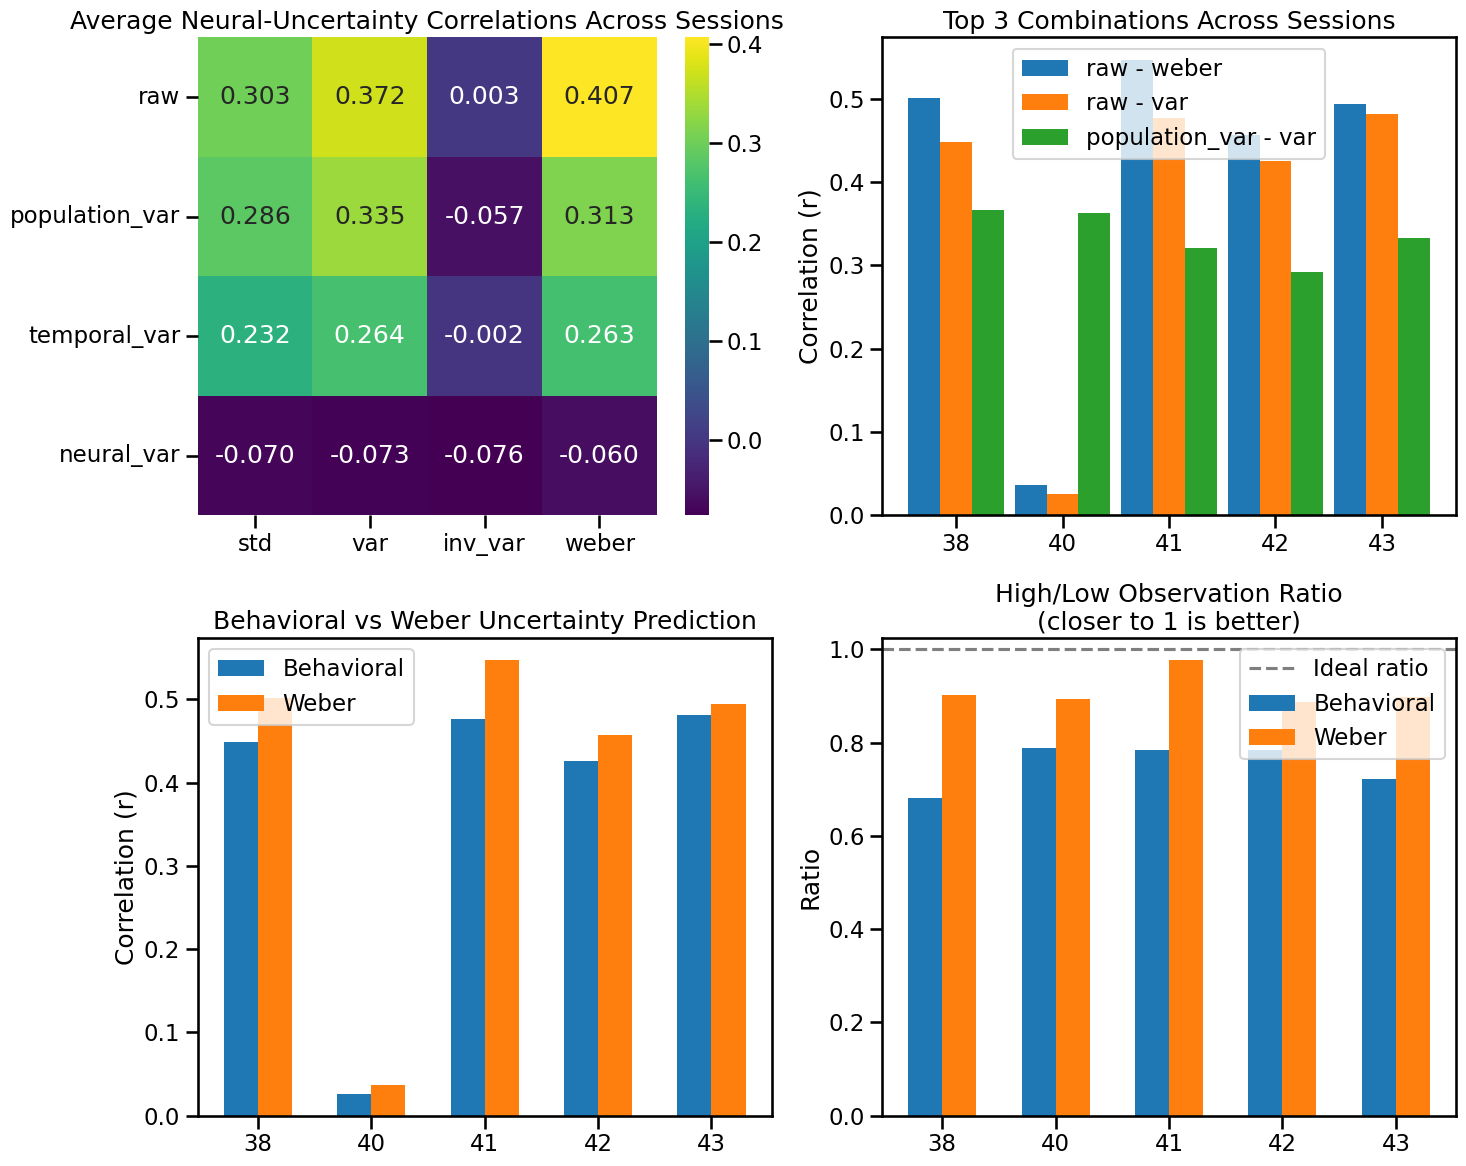


==== CROSS-SESSION UNCERTAINTY REPRESENTATION ANALYSIS ====
Total sessions analyzed: 5

Best overall combination: raw - weber
  Average correlation: 0.407

Top 3 combinations:
  raw - weber: r = 0.407
  raw - var: r = 0.372
  population_var - var: r = 0.335

Behavioral vs Weber comparison:
  Behavioral: r = 0.372
  Weber: r = 0.407

High/Low Observation Ratio (closer to 1 is better):
  Behavioral: 0.752
  Weber: 0.912

Difference in deviation from ideal ratio (1.0): 0.160
  Weber model is better at maintaining consistent prediction across observation magnitudes


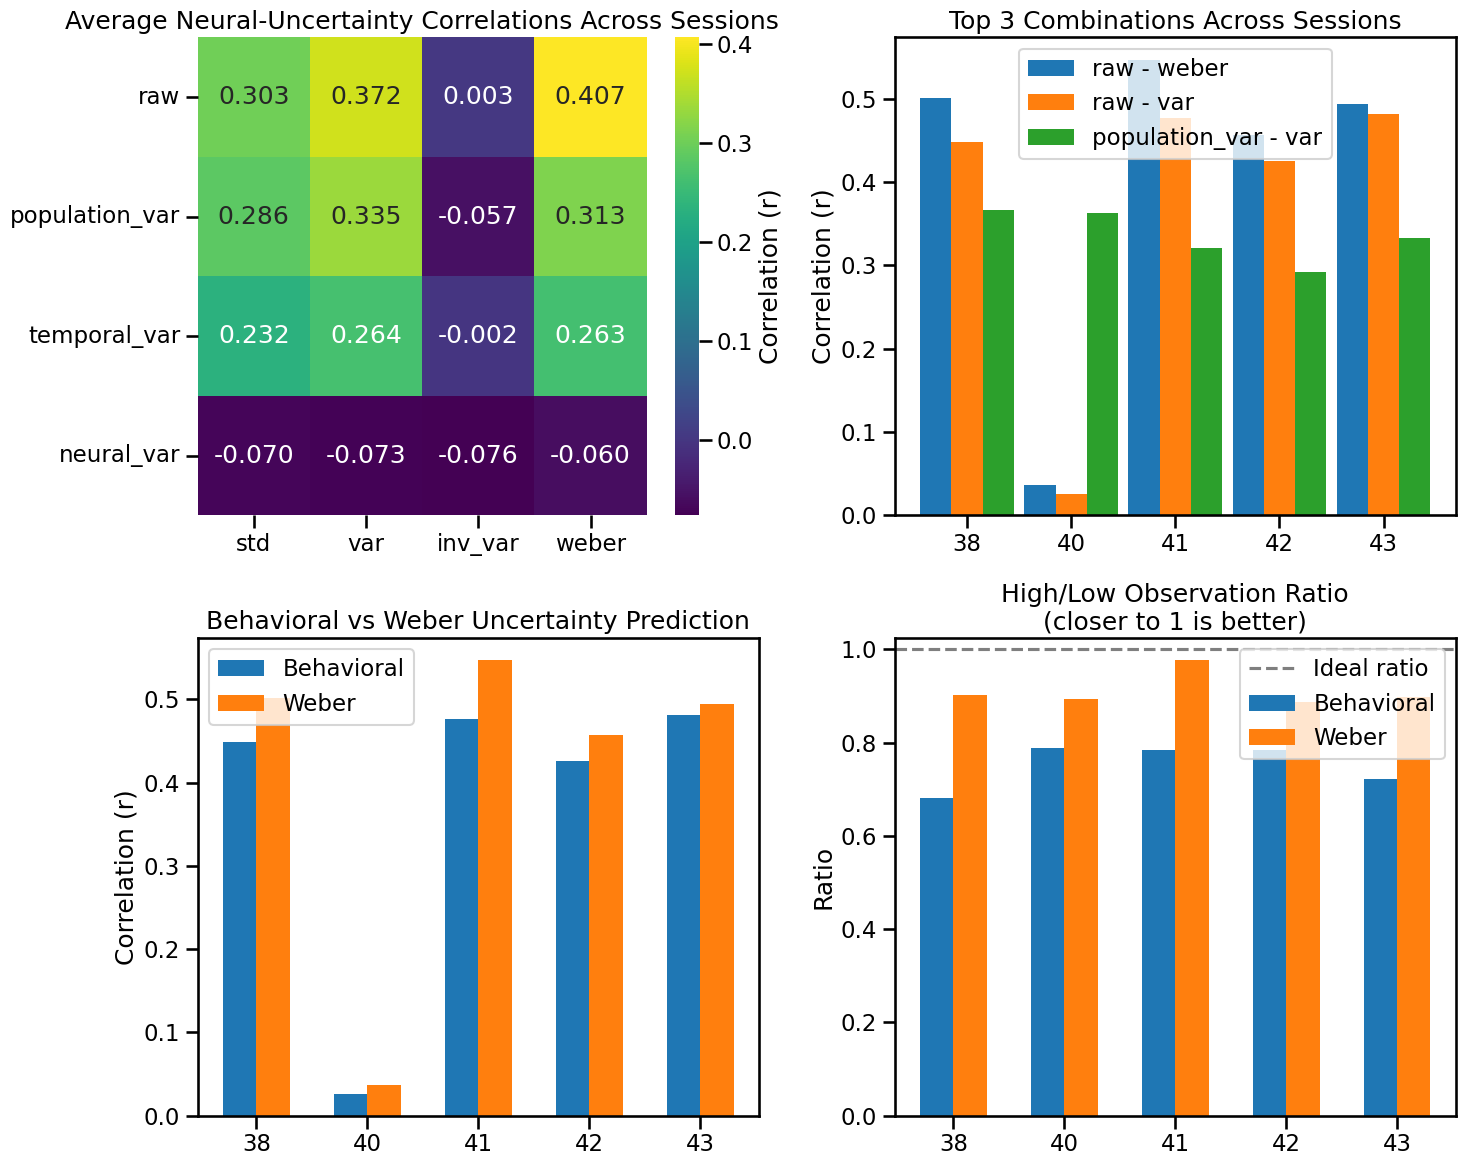

In [15]:
def analyze_all_uncertainty_representations_fixed(df):
    """
    Analyze different uncertainty representations with corrected Weber model
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from scipy.stats import pearsonr
    from sklearn.model_selection import cross_val_predict
    import pandas as pd
    import seaborn as sns
    
    # Get all sessions
    all_sessions = sorted(df.session.unique())
    print(f"Found {len(all_sessions)} sessions")
    
    # Initialize storage for results
    all_results = {}
    
    # Neural features and uncertainty representations to test
    neural_features = ['raw', 'population_var', 'temporal_var', 'neural_var']
    uncertainty_reps = ['std', 'var', 'inv_var', 'weber']
    
    # Create empty matrices for aggregated results
    agg_corr_matrix = np.zeros((len(neural_features), len(uncertainty_reps)))
    agg_high_obs_matrix = np.zeros((len(neural_features), len(uncertainty_reps)))
    agg_low_obs_matrix = np.zeros((len(neural_features), len(uncertainty_reps)))
    
    # Process each session
    for session_id in all_sessions:
        print(f"\n===== Analyzing Session {session_id} =====")
        
        try:
            # Filter to session
            sessdf = df[df.session == session_id]
            print(f"Number of trials: {len(sessdf)}")
            
            # Create timedf for this session
            timedf = pd.DataFrame({'timer': np.concatenate(sessdf.timer.to_numpy())})
            timedf['belief'] = np.concatenate(sessdf.belief_ff_hori.to_numpy())
            timedf['state'] = np.concatenate(sessdf.ff_hori.to_numpy())
            timedf['eye'] = np.concatenate(sessdf.eye_hori.to_numpy())
            timedf['timeratio'] = np.concatenate(sessdf.time_ratio.to_numpy())
            timedf['mv'] = np.concatenate(sessdf.mv.to_numpy())
            timedf['mw'] = np.concatenate(sessdf.mw.to_numpy())
            timedf['belief_heading'] = np.concatenate(sessdf.belief_heading.to_numpy())
            timedf['timer'] = np.concatenate(sessdf.timer.to_numpy())
            timedf['countdown'] = np.concatenate(sessdf.countdown.to_numpy())
            timedf['belief_angle_from_start'] = np.concatenate(sessdf.belief_angle_from_start.to_numpy())
            timedf['PPC'] = list(np.vstack(sessdf.PPC.to_numpy()))
            timedf['PPC_var'] = list(np.vstack(sessdf.PPC_var.to_numpy()))
            timedf['uncertainty'] = list(np.concatenate(sessdf.relcov.to_numpy()))
            
            # Extract trial information and visibility condition
            sessdf['fullon_t'] = sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
            sessdf['trial_t'] = sessdf.apply(lambda x: np.array([[x.trial]*len(x.mx)]).reshape(-1), axis=1)
            
            timedf['fullon'] = np.concatenate(sessdf.fullon_t.to_numpy())
            timedf['trial'] = np.concatenate(sessdf.trial_t.to_numpy())
            
            # Clean timedf
            timedf = timedf.dropna(subset=['eye', 'state', 'belief'])
            
            # Extract variables
            neural_data = np.stack(timedf.PPC.to_numpy())
            neural_var_data = np.stack(timedf.PPC_var.to_numpy())  # Population variance
            uncertainty_std = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
            uncertainty_var = uncertainty_std**2  # variance
            uncertainty_inv_var = 1 / (uncertainty_var + 1e-6)  # inverse variance (precision)
            time_ratio = timedf.timeratio.to_numpy()
            observations = np.abs(timedf.mw.to_numpy())
            trial_ids = timedf.trial.to_numpy()
            timer = timedf.timer.to_numpy()
            
            # Create CORRECTED Weber-inspired uncertainty
            # Group by trial to calculate accumulated uncertainty
            unique_trials = np.unique(trial_ids)
            weber_uncertainty = np.zeros_like(uncertainty_var)
            
            for trial in unique_trials:
                trial_mask = trial_ids == trial
                trial_obs = observations[trial_mask]
                trial_indices = np.where(trial_mask)[0]
                
                # Calculate accumulated uncertainty for this trial
                # For each time point, the uncertainty is the sum of all previous observations
                trial_weber = np.zeros(len(trial_obs))
                
                for i in range(len(trial_obs)):
                    # Accumulate observations up to this point
                    trial_weber[i] = np.sum(trial_obs[:i+1])
                
                # Store in the main array
                weber_uncertainty[trial_indices] = trial_weber
                
            # Create temporal variance of neural activity using window
            window_size = 5
            n_neurons = neural_data.shape[1]
            temporal_var = np.zeros_like(neural_data)
            
            for i in range(len(neural_data)):
                start_idx = max(0, i - window_size)
                end_idx = min(len(neural_data), i + window_size + 1)
                temporal_var[i] = np.var(neural_data[start_idx:end_idx], axis=0)
            
            # Population variance (variance across neurons at each time point)
            population_var = np.var(neural_data, axis=1).reshape(-1, 1)
            
            # Create dictionary of neural features and uncertainty representations
            neural_feat_dict = {
                'raw': neural_data,
                'population_var': population_var,
                'temporal_var': temporal_var,
                'neural_var': neural_var_data
            }
            
            uncertainty_rep_dict = {
                'std': uncertainty_std,
                'var': uncertainty_var,
                'inv_var': uncertainty_inv_var,
                'weber': weber_uncertainty
            }
            
            # Check for observation effects
            median_obs = np.median(observations)
            high_obs_mask = observations > median_obs
            low_obs_mask = ~high_obs_mask
            
            # Store the best combination for this session
            best_combo = None
            best_corr = -1
            
            # Matrix for heatmap of this session
            session_corr_matrix = np.zeros((len(neural_feat_dict), len(uncertainty_rep_dict)))
            session_high_obs_matrix = np.zeros((len(neural_feat_dict), len(uncertainty_rep_dict)))
            session_low_obs_matrix = np.zeros((len(neural_feat_dict), len(uncertainty_rep_dict)))
            
            # Initialize session results
            session_results = {}
            
            # Analyze each combination
            for i, (feat_name, feat_data) in enumerate(neural_feat_dict.items()):
                session_results[feat_name] = {}
                
                for j, (rep_name, rep_data) in enumerate(uncertainty_rep_dict.items()):
                    # Create model
                    model = LinearRegression()
                    
                    # Cross-validated prediction
                    predicted = cross_val_predict(model, feat_data, rep_data, cv=5)
                    
                    # Calculate correlation
                    corr, p_val = pearsonr(predicted, rep_data)
                    
                    # Check observation effect
                    if np.sum(high_obs_mask) > 10 and np.sum(low_obs_mask) > 10:
                        # High observation
                        high_obs_model = LinearRegression()
                        high_obs_model.fit(feat_data[high_obs_mask], rep_data[high_obs_mask])
                        high_pred = high_obs_model.predict(feat_data[high_obs_mask])
                        high_corr, _ = pearsonr(high_pred, rep_data[high_obs_mask])
                        
                        # Low observation
                        low_obs_model = LinearRegression()
                        low_obs_model.fit(feat_data[low_obs_mask], rep_data[low_obs_mask])
                        low_pred = low_obs_model.predict(feat_data[low_obs_mask])
                        low_corr, _ = pearsonr(low_pred, rep_data[low_obs_mask])
                    else:
                        high_corr = np.nan
                        low_corr = np.nan
                    
                    # Store results
                    session_results[feat_name][rep_name] = {
                        'corr': corr,
                        'p_val': p_val,
                        'high_obs_corr': high_corr,
                        'low_obs_corr': low_corr
                    }
                    
                    # Update best combo
                    if corr > best_corr:
                        best_corr = corr
                        best_combo = (feat_name, rep_name)
                    
                    # Store correlation for heatmap
                    session_corr_matrix[i, j] = corr
                    session_high_obs_matrix[i, j] = high_corr
                    session_low_obs_matrix[i, j] = low_corr
                    
                    # Add to aggregated matrices
                    agg_corr_matrix[i, j] += corr
                    if not np.isnan(high_corr):
                        agg_high_obs_matrix[i, j] += high_corr
                    if not np.isnan(low_corr):
                        agg_low_obs_matrix[i, j] += low_corr
            
            # Add session results to all results
            all_results[session_id] = {
                'corr_matrix': session_corr_matrix,
                'high_obs_matrix': session_high_obs_matrix,
                'low_obs_matrix': session_low_obs_matrix,
                'best_combo': best_combo,
                'best_corr': best_corr,
                'detailed_results': session_results
            }
            
            # Get the best feature and representation
            best_feat, best_rep = best_combo
            best_result = session_results[best_feat][best_rep]
            
            # Print session summary
            print(f"Session {session_id} Summary:")
            print(f"  Number of neurons: {neural_data.shape[1]}")
            print(f"  Best combination: {best_feat} - {best_rep}, r = {best_corr:.3f}")
            
            # Compare behavioral vs Weber
            beh_result = session_results['raw']['var']
            weber_result = session_results['raw']['weber']
            
            print(f"  Behavioral model: r = {beh_result['corr']:.3f}")
            if not np.isnan(beh_result['high_obs_corr']) and not np.isnan(beh_result['low_obs_corr']):
                beh_ratio = beh_result['high_obs_corr'] / beh_result['low_obs_corr']
                print(f"    High/Low ratio: {beh_ratio:.3f}")
            
            print(f"  Weber model: r = {weber_result['corr']:.3f}")
            if not np.isnan(weber_result['high_obs_corr']) and not np.isnan(weber_result['low_obs_corr']):
                weber_ratio = weber_result['high_obs_corr'] / weber_result['low_obs_corr']
                print(f"    High/Low ratio: {weber_ratio:.3f}")
        
        except Exception as e:
            print(f"Error processing session {session_id}: {e}")
            continue
    
    # Calculate averages for aggregated matrices
    agg_corr_matrix /= len(all_results)
    
    # Find best combination across all sessions
    best_i, best_j = np.unravel_index(np.argmax(agg_corr_matrix), agg_corr_matrix.shape)
    best_overall_feat = neural_features[best_i]
    best_overall_rep = uncertainty_reps[best_j]
    
    # Create summary visualizations
    plt.figure(figsize=(15, 12))
    
    # Plot 1: Heatmap of average correlations
    plt.subplot(2, 2, 1)
    sns.heatmap(agg_corr_matrix, annot=True, fmt='.3f', cmap='viridis',
               xticklabels=uncertainty_reps, yticklabels=neural_features)
    plt.title('Average Neural-Uncertainty Correlations Across Sessions')
    
    # Plot 2: Compare top combinations across sessions
    plt.subplot(2, 2, 2)
    
    # Get top 3 combinations based on average
    flat_indices = np.argsort(agg_corr_matrix.flatten())[-3:]
    top_indices = np.unravel_index(flat_indices, agg_corr_matrix.shape)
    top_combos = [(neural_features[i], uncertainty_reps[j]) 
                  for i, j in zip(top_indices[0], top_indices[1])]
    
    # Prepare data for plot
    session_ids = list(all_results.keys())
    width = 0.3
    x = np.arange(len(session_ids))
    
    # Plot each top combination
    for i, (feat, rep) in enumerate(reversed(top_combos)):
        combo_corrs = [all_results[s]['detailed_results'][feat][rep]['corr'] 
                      if feat in all_results[s]['detailed_results'] and rep in all_results[s]['detailed_results'][feat] 
                      else np.nan for s in session_ids]
        
        plt.bar(x + (i-1)*width, combo_corrs, width, 
               label=f'{feat} - {rep}')
    
    plt.title('Top 3 Combinations Across Sessions')
    plt.xticks(x, session_ids)
    plt.ylabel('Correlation (r)')
    plt.legend()
    
    # Plot 3: Behavioral vs Weber uncertainty
    plt.subplot(2, 2, 3)
    
    # Prepare data
    beh_corrs = [all_results[s]['detailed_results']['raw']['var']['corr'] 
                if 'raw' in all_results[s]['detailed_results'] and 'var' in all_results[s]['detailed_results']['raw']
                else np.nan for s in session_ids]
    
    weber_corrs = [all_results[s]['detailed_results']['raw']['weber']['corr'] 
                  if 'raw' in all_results[s]['detailed_results'] and 'weber' in all_results[s]['detailed_results']['raw']
                  else np.nan for s in session_ids]
    
    plt.bar(x - width/2, beh_corrs, width, label='Behavioral')
    plt.bar(x + width/2, weber_corrs, width, label='Weber')
    
    plt.title('Behavioral vs Weber Uncertainty Prediction')
    plt.xticks(x, session_ids)
    plt.ylabel('Correlation (r)')
    plt.legend()
    
    # Plot 4: High/Low observation ratio
    plt.subplot(2, 2, 4)
    
    # Prepare data
    beh_ratios = []
    weber_ratios = []
    
    for s in session_ids:
        if 'raw' in all_results[s]['detailed_results'] and 'var' in all_results[s]['detailed_results']['raw']:
            beh_result = all_results[s]['detailed_results']['raw']['var']
            if not np.isnan(beh_result['high_obs_corr']) and not np.isnan(beh_result['low_obs_corr']) and beh_result['low_obs_corr'] > 0:
                beh_ratio = beh_result['high_obs_corr'] / beh_result['low_obs_corr']
            else:
                beh_ratio = np.nan
        else:
            beh_ratio = np.nan
        
        if 'raw' in all_results[s]['detailed_results'] and 'weber' in all_results[s]['detailed_results']['raw']:
            weber_result = all_results[s]['detailed_results']['raw']['weber']
            if not np.isnan(weber_result['high_obs_corr']) and not np.isnan(weber_result['low_obs_corr']) and weber_result['low_obs_corr'] > 0:
                weber_ratio = weber_result['high_obs_corr'] / weber_result['low_obs_corr']
            else:
                weber_ratio = np.nan
        else:
            weber_ratio = np.nan
        
        beh_ratios.append(beh_ratio)
        weber_ratios.append(weber_ratio)
    
    plt.bar(x - width/2, beh_ratios, width, label='Behavioral')
    plt.bar(x + width/2, weber_ratios, width, label='Weber')
    
    plt.axhline(1.0, color='k', linestyle='--', alpha=0.5, label='Ideal ratio')
    
    plt.title('High/Low Observation Ratio\n(closer to 1 is better)')
    plt.xticks(x, session_ids)
    plt.ylabel('Ratio')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print overall summary
    print("\n==== CROSS-SESSION UNCERTAINTY REPRESENTATION ANALYSIS ====")
    print(f"Total sessions analyzed: {len(all_results)}")
    
    print(f"\nBest overall combination: {best_overall_feat} - {best_overall_rep}")
    print(f"  Average correlation: {agg_corr_matrix[best_i, best_j]:.3f}")
    
    print("\nTop 3 combinations:")
    for i, (feat, rep) in enumerate(reversed(top_combos)):
        avg_corr = agg_corr_matrix[neural_features.index(feat), uncertainty_reps.index(rep)]
        print(f"  {feat} - {rep}: r = {avg_corr:.3f}")
    
    print("\nBehavioral vs Weber comparison:")
    avg_beh = np.nanmean(beh_corrs)
    avg_weber = np.nanmean(weber_corrs)
    print(f"  Behavioral: r = {avg_beh:.3f}")
    print(f"  Weber: r = {avg_weber:.3f}")
    
    print("\nHigh/Low Observation Ratio (closer to 1 is better):")
    avg_beh_ratio = np.nanmean(beh_ratios)
    avg_weber_ratio = np.nanmean(weber_ratios)
    print(f"  Behavioral: {avg_beh_ratio:.3f}")
    print(f"  Weber: {avg_weber_ratio:.3f}")
    
    # Test if the difference is significant
    if not np.isnan(avg_beh_ratio) and not np.isnan(avg_weber_ratio):
        ratio_diff = abs(1 - avg_beh_ratio) - abs(1 - avg_weber_ratio)
        print(f"\nDifference in deviation from ideal ratio (1.0): {ratio_diff:.3f}")
        print(f"  {'Weber model is better' if ratio_diff > 0 else 'Behavioral model is better'} at maintaining consistent prediction across observation magnitudes")
    

    # Create summary visualizations
    plt.figure(figsize=(15, 12))

    # Plot 1: Heatmap of average correlations with colorbar label
    plt.subplot(2, 2, 1)
    heatmap = sns.heatmap(agg_corr_matrix, annot=True, fmt='.3f', cmap='viridis',
            xticklabels=uncertainty_reps, yticklabels=neural_features)
    plt.title('Average Neural-Uncertainty Correlations Across Sessions')
    cbar = heatmap.collections[0].colorbar
    cbar.set_label('Correlation (r)')

    # Plot 2: Compare top combinations across sessions
    plt.subplot(2, 2, 2)

    # Get top 3 combinations based on average
    flat_indices = np.argsort(agg_corr_matrix.flatten())[-3:]
    top_indices = np.unravel_index(flat_indices, agg_corr_matrix.shape)
    top_combos = [(neural_features[i], uncertainty_reps[j]) 
                for i, j in zip(top_indices[0], top_indices[1])]

    # Prepare data for plot
    session_ids = list(all_results.keys())
    width = 0.3
    x = np.arange(len(session_ids))

    # Plot each top combination
    for i, (feat, rep) in enumerate(reversed(top_combos)):
        combo_corrs = [all_results[s]['detailed_results'][feat][rep]['corr'] 
                    if feat in all_results[s]['detailed_results'] and rep in all_results[s]['detailed_results'][feat] 
                    else np.nan for s in session_ids]
        
        plt.bar(x + (i-1)*width, combo_corrs, width, 
            label=f'{feat} - {rep}')

    plt.title('Top 3 Combinations Across Sessions')
    plt.xticks(x, session_ids)
    plt.ylabel('Correlation (r)')
    plt.legend()

    # Plot 3: Behavioral vs Weber uncertainty
    plt.subplot(2, 2, 3)

    # Prepare data
    beh_corrs = [all_results[s]['detailed_results']['raw']['var']['corr'] 
                if 'raw' in all_results[s]['detailed_results'] and 'var' in all_results[s]['detailed_results']['raw']
                else np.nan for s in session_ids]

    weber_corrs = [all_results[s]['detailed_results']['raw']['weber']['corr'] 
                if 'raw' in all_results[s]['detailed_results'] and 'weber' in all_results[s]['detailed_results']['raw']
                else np.nan for s in session_ids]

    plt.bar(x - width/2, beh_corrs, width, label='Behavioral')
    plt.bar(x + width/2, weber_corrs, width, label='Weber')

    plt.title('Behavioral vs Weber Uncertainty Prediction')
    plt.xticks(x, session_ids)
    plt.ylabel('Correlation (r)')
    plt.legend()

    # Plot 4: High/Low observation ratio
    plt.subplot(2, 2, 4)

    # Prepare data
    beh_ratios = []
    weber_ratios = []

    for s in session_ids:
        if 'raw' in all_results[s]['detailed_results'] and 'var' in all_results[s]['detailed_results']['raw']:
            beh_result = all_results[s]['detailed_results']['raw']['var']
            if not np.isnan(beh_result['high_obs_corr']) and not np.isnan(beh_result['low_obs_corr']) and beh_result['low_obs_corr'] > 0:
                beh_ratio = beh_result['high_obs_corr'] / beh_result['low_obs_corr']
            else:
                beh_ratio = np.nan
        else:
            beh_ratio = np.nan
        
        if 'raw' in all_results[s]['detailed_results'] and 'weber' in all_results[s]['detailed_results']['raw']:
            weber_result = all_results[s]['detailed_results']['raw']['weber']
            if not np.isnan(weber_result['high_obs_corr']) and not np.isnan(weber_result['low_obs_corr']) and weber_result['low_obs_corr'] > 0:
                weber_ratio = weber_result['high_obs_corr'] / weber_result['low_obs_corr']
            else:
                weber_ratio = np.nan
        else:
            weber_ratio = np.nan
        
        beh_ratios.append(beh_ratio)
        weber_ratios.append(weber_ratio)

    plt.bar(x - width/2, beh_ratios, width, label='Behavioral')
    plt.bar(x + width/2, weber_ratios, width, label='Weber')

    plt.axhline(1.0, color='k', linestyle='--', alpha=0.5, label='Ideal ratio')

    plt.title('High/Low Observation Ratio\n(closer to 1 is better)')
    plt.xticks(x, session_ids)
    plt.ylabel('Ratio')
    plt.legend()

    plt.tight_layout()
    plt.show()


    return all_results

# Run analysis on all sessions with corrected Weber model
all_sessions_representation_results_fixed = analyze_all_uncertainty_representations_fixed(df)

In [ ]:
# Create summary visualizations
plt.figure(figsize=(15, 12))

# Plot 1: Heatmap of average correlations with colorbar label
plt.subplot(2, 2, 1)
heatmap = sns.heatmap(agg_corr_matrix, annot=True, fmt='.3f', cmap='viridis',
           xticklabels=uncertainty_reps, yticklabels=neural_features)
plt.title('Average Neural-Uncertainty Correlations Across Sessions')
cbar = heatmap.collections[0].colorbar
cbar.set_label('Correlation (r)')

# Plot 2: Compare top combinations across sessions
plt.subplot(2, 2, 2)

# Get top 3 combinations based on average
flat_indices = np.argsort(agg_corr_matrix.flatten())[-3:]
top_indices = np.unravel_index(flat_indices, agg_corr_matrix.shape)
top_combos = [(neural_features[i], uncertainty_reps[j]) 
              for i, j in zip(top_indices[0], top_indices[1])]

# Prepare data for plot
session_ids = list(all_results.keys())
width = 0.3
x = np.arange(len(session_ids))

# Plot each top combination
for i, (feat, rep) in enumerate(reversed(top_combos)):
    combo_corrs = [all_results[s]['detailed_results'][feat][rep]['corr'] 
                  if feat in all_results[s]['detailed_results'] and rep in all_results[s]['detailed_results'][feat] 
                  else np.nan for s in session_ids]
    
    plt.bar(x + (i-1)*width, combo_corrs, width, 
           label=f'{feat} - {rep}')

plt.title('Top 3 Combinations Across Sessions')
plt.xticks(x, session_ids)
plt.ylabel('Correlation (r)')
plt.legend()

# Plot 3: Behavioral vs Weber uncertainty
plt.subplot(2, 2, 3)

# Prepare data
beh_corrs = [all_results[s]['detailed_results']['raw']['var']['corr'] 
            if 'raw' in all_results[s]['detailed_results'] and 'var' in all_results[s]['detailed_results']['raw']
            else np.nan for s in session_ids]

weber_corrs = [all_results[s]['detailed_results']['raw']['weber']['corr'] 
              if 'raw' in all_results[s]['detailed_results'] and 'weber' in all_results[s]['detailed_results']['raw']
              else np.nan for s in session_ids]

plt.bar(x - width/2, beh_corrs, width, label='Behavioral')
plt.bar(x + width/2, weber_corrs, width, label='Weber')

plt.title('Behavioral vs Weber Uncertainty Prediction')
plt.xticks(x, session_ids)
plt.ylabel('Correlation (r)')
plt.legend()

# Plot 4: High/Low observation ratio
plt.subplot(2, 2, 4)

# Prepare data
beh_ratios = []
weber_ratios = []

for s in session_ids:
    if 'raw' in all_results[s]['detailed_results'] and 'var' in all_results[s]['detailed_results']['raw']:
        beh_result = all_results[s]['detailed_results']['raw']['var']
        if not np.isnan(beh_result['high_obs_corr']) and not np.isnan(beh_result['low_obs_corr']) and beh_result['low_obs_corr'] > 0:
            beh_ratio = beh_result['high_obs_corr'] / beh_result['low_obs_corr']
        else:
            beh_ratio = np.nan
    else:
        beh_ratio = np.nan
    
    if 'raw' in all_results[s]['detailed_results'] and 'weber' in all_results[s]['detailed_results']['raw']:
        weber_result = all_results[s]['detailed_results']['raw']['weber']
        if not np.isnan(weber_result['high_obs_corr']) and not np.isnan(weber_result['low_obs_corr']) and weber_result['low_obs_corr'] > 0:
            weber_ratio = weber_result['high_obs_corr'] / weber_result['low_obs_corr']
        else:
            weber_ratio = np.nan
    else:
        weber_ratio = np.nan
    
    beh_ratios.append(beh_ratio)
    weber_ratios.append(weber_ratio)

plt.bar(x - width/2, beh_ratios, width, label='Behavioral')
plt.bar(x + width/2, weber_ratios, width, label='Weber')

plt.axhline(1.0, color='k', linestyle='--', alpha=0.5, label='Ideal ratio')

plt.title('High/Low Observation Ratio\n(closer to 1 is better)')
plt.xticks(x, session_ids)
plt.ylabel('Ratio')
plt.legend()

plt.tight_layout()
plt.show()

Analyzing session 41
Number of trials: 1538


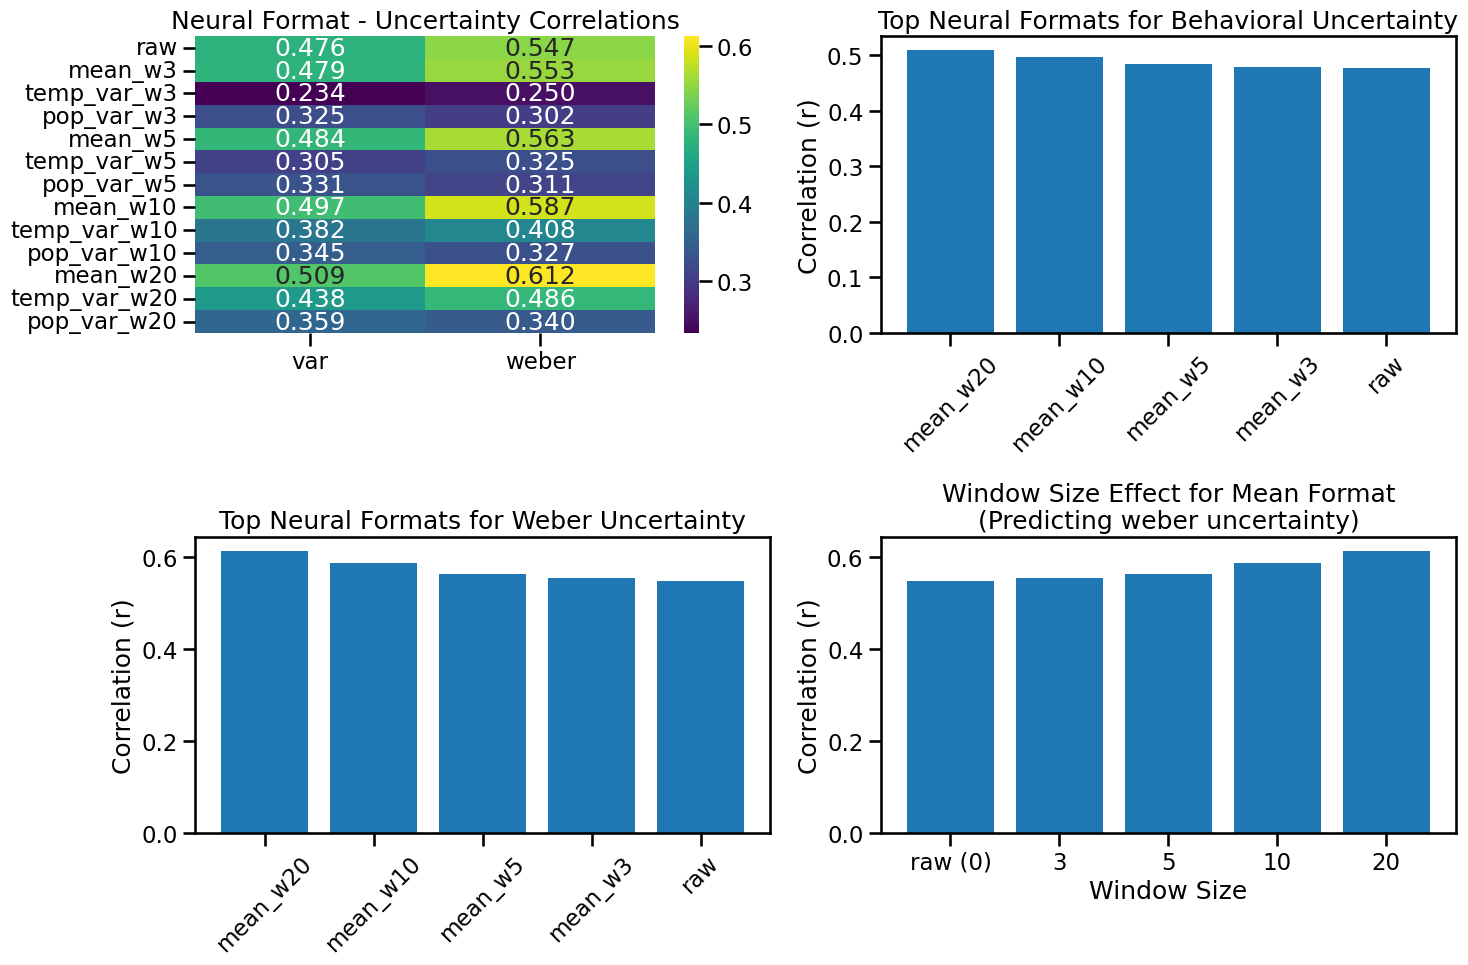


==== NEURAL FORMAT ANALYSIS RESULTS ====
Session: 41, Number of neurons: 112

Best Neural Format - Uncertainty Combination:
  mean_w20 - weber: r = 0.612
  High observation: r = 0.654
  Low observation: r = 0.639
  High/Low ratio: 1.023

Top 5 Formats for Behavioral Uncertainty:
  mean_w20: r = 0.509
    High obs: r = 0.484, Low obs: r = 0.587
    High/Low ratio: 0.823
  mean_w10: r = 0.497
    High obs: r = 0.463, Low obs: r = 0.569
    High/Low ratio: 0.814
  mean_w5: r = 0.484
    High obs: r = 0.444, Low obs: r = 0.555
    High/Low ratio: 0.800
  mean_w3: r = 0.479
    High obs: r = 0.436, Low obs: r = 0.550
    High/Low ratio: 0.793
  raw: r = 0.476
    High obs: r = 0.430, Low obs: r = 0.548
    High/Low ratio: 0.784

Top 5 Formats for Weber Uncertainty:
  mean_w20: r = 0.612
    High obs: r = 0.654, Low obs: r = 0.639
    High/Low ratio: 1.023
  mean_w10: r = 0.587
    High obs: r = 0.619, Low obs: r = 0.615
    High/Low ratio: 1.006
  mean_w5: r = 0.563
    High obs: r = 0.590

In [38]:
def analyze_neural_formats_for_uncertainty(df, session_id=41):
    """
    Analyze how different neural activity formats encode uncertainty
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from scipy.stats import pearsonr
    from sklearn.model_selection import cross_val_predict
    import pandas as pd
    import seaborn as sns
    
    print(f"Analyzing session {session_id}")
    sessdf = df[df.session == session_id]
    print(f"Number of trials: {len(sessdf)}")
    
    # Create timedf
    timedf = pd.DataFrame({'timer': np.concatenate(sessdf.timer.to_numpy())})
    timedf['belief'] = np.concatenate(sessdf.belief_ff_hori.to_numpy())
    timedf['state'] = np.concatenate(sessdf.ff_hori.to_numpy())
    timedf['eye'] = np.concatenate(sessdf.eye_hori.to_numpy())
    timedf['timeratio'] = np.concatenate(sessdf.time_ratio.to_numpy())
    timedf['mv'] = np.concatenate(sessdf.mv.to_numpy())
    timedf['mw'] = np.concatenate(sessdf.mw.to_numpy())
    timedf['belief_heading'] = np.concatenate(sessdf.belief_heading.to_numpy())
    timedf['timer'] = np.concatenate(sessdf.timer.to_numpy())
    timedf['countdown'] = np.concatenate(sessdf.countdown.to_numpy())
    timedf['belief_angle_from_start'] = np.concatenate(sessdf.belief_angle_from_start.to_numpy())
    timedf['PPC'] = list(np.vstack(sessdf.PPC.to_numpy()))
    timedf['PPC_var'] = list(np.vstack(sessdf.PPC_var.to_numpy()))
    timedf['uncertainty'] = list(np.concatenate(sessdf.relcov.to_numpy()))
    
    # Extract trial information and visibility condition
    sessdf['fullon_t'] = sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
    sessdf['trial_t'] = sessdf.apply(lambda x: np.array([[x.trial]*len(x.mx)]).reshape(-1), axis=1)
    
    timedf['fullon'] = np.concatenate(sessdf.fullon_t.to_numpy())
    timedf['trial'] = np.concatenate(sessdf.trial_t.to_numpy())
    
    # Clean timedf
    timedf = timedf.dropna(subset=['eye', 'state', 'belief'])
    
    # Extract variables
    neural_data = np.stack(timedf.PPC.to_numpy())
    neural_var_data = np.stack(timedf.PPC_var.to_numpy())
    uncertainty_std = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5
    uncertainty_var = uncertainty_std**2
    observations = np.abs(timedf.mw.to_numpy())
    trial_ids = timedf.trial.to_numpy()
    
    # Create Weber uncertainty
    unique_trials = np.unique(trial_ids)
    weber_uncertainty = np.zeros_like(uncertainty_var)
    
    for trial in unique_trials:
        trial_mask = trial_ids == trial
        trial_obs = observations[trial_mask]
        trial_indices = np.where(trial_mask)[0]
        
        # Calculate accumulated uncertainty for this trial
        trial_weber = np.zeros(len(trial_obs))
        for i in range(len(trial_obs)):
            trial_weber[i] = np.sum(trial_obs[:i+1])
        
        weber_uncertainty[trial_indices] = trial_weber
    
    # Window sizes to test
    window_sizes = [3, 5, 10, 20]
    
    # Create dictionary of neural formats
    neural_formats = {'raw': neural_data}
    
    # Generate windowed neural features for each window size
    for window_size in window_sizes:
        # Moving window mean
        window_mean = np.zeros_like(neural_data)
        # Moving window temporal var
        window_temp_var = np.zeros_like(neural_data)
        # Moving window population var
        window_pop_var = np.zeros(neural_data.shape[0])
        
        for i in range(len(neural_data)):
            start_idx = max(0, i - window_size)
            end_idx = min(len(neural_data), i + window_size + 1)
            window_data = neural_data[start_idx:end_idx]
            
            # Mean across time window
            window_mean[i] = np.mean(window_data, axis=0)
            # Temporal variance across window
            window_temp_var[i] = np.var(window_data, axis=0)
            # Population variance within window
            window_pop_var[i] = np.var(np.mean(window_data, axis=0))
        
        # Add to neural formats
        neural_formats[f'mean_w{window_size}'] = window_mean
        neural_formats[f'temp_var_w{window_size}'] = window_temp_var
        neural_formats[f'pop_var_w{window_size}'] = window_pop_var.reshape(-1, 1)
    
    # Uncertainty representations
    uncertainty_reps = {
        'var': uncertainty_var,
        'weber': weber_uncertainty
    }
    
    # Prepare for results
    results = {}
    
    # Check for observation effects
    median_obs = np.median(observations)
    high_obs_mask = observations > median_obs
    low_obs_mask = ~high_obs_mask
    
    # Create result matrices
    format_names = list(neural_formats.keys())
    rep_names = list(uncertainty_reps.keys())
    
    corr_matrix = np.zeros((len(format_names), len(rep_names)))
    high_obs_matrix = np.zeros((len(format_names), len(rep_names)))
    low_obs_matrix = np.zeros((len(format_names), len(rep_names)))
    
    # Store best combination
    best_combo = None
    best_corr = -1
    
    # Analyze each combination
    for i, (format_name, format_data) in enumerate(neural_formats.items()):
        results[format_name] = {}
        
        for j, (rep_name, rep_data) in enumerate(uncertainty_reps.items()):
            # Create model
            model = LinearRegression()
            
            # Cross-validated prediction
            predicted = cross_val_predict(model, format_data, rep_data, cv=5)
            
            # Calculate correlation
            corr, p_val = pearsonr(predicted, rep_data)
            
            # Check observation effect
            high_obs_model = LinearRegression()
            high_obs_model.fit(format_data[high_obs_mask], rep_data[high_obs_mask])
            high_pred = high_obs_model.predict(format_data[high_obs_mask])
            high_corr, _ = pearsonr(high_pred, rep_data[high_obs_mask])
            
            low_obs_model = LinearRegression()
            low_obs_model.fit(format_data[low_obs_mask], rep_data[low_obs_mask])
            low_pred = low_obs_model.predict(format_data[low_obs_mask])
            low_corr, _ = pearsonr(low_pred, rep_data[low_obs_mask])
            
            # Store results
            results[format_name][rep_name] = {
                'corr': corr,
                'p_val': p_val,
                'high_obs_corr': high_corr,
                'low_obs_corr': low_corr
            }
            
            # Update best combo
            if corr > best_corr:
                best_corr = corr
                best_combo = (format_name, rep_name)
            
            # Store correlation for heatmap
            corr_matrix[i, j] = corr
            high_obs_matrix[i, j] = high_corr
            low_obs_matrix[i, j] = low_corr
    
    # Get the best format and representation
    best_format, best_rep = best_combo
    best_result = results[best_format][best_rep]
    
    # Create visualizations
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Heatmap of correlations
    plt.subplot(2, 2, 1)
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='viridis',
               xticklabels=rep_names, yticklabels=format_names)
    plt.title('Neural Format - Uncertainty Correlations')
    
    # Plot 2: Top formats for behavioral uncertainty
    plt.subplot(2, 2, 2)
    
    # Sort formats by correlation with behavioral uncertainty
    beh_corrs = [results[format]['var']['corr'] for format in format_names]
    sorted_indices = np.argsort(beh_corrs)[::-1]
    top_formats = [format_names[i] for i in sorted_indices[:5]]
    top_corrs = [beh_corrs[i] for i in sorted_indices[:5]]
    
    plt.bar(top_formats, top_corrs)
    plt.title('Top Neural Formats for Behavioral Uncertainty')
    plt.ylabel('Correlation (r)')
    plt.xticks(rotation=45)
    
    # Plot 3: Top formats for Weber uncertainty
    plt.subplot(2, 2, 3)
    
    # Sort formats by correlation with Weber uncertainty
    weber_corrs = [results[format]['weber']['corr'] for format in format_names]
    sorted_indices = np.argsort(weber_corrs)[::-1]
    top_formats = [format_names[i] for i in sorted_indices[:5]]
    top_corrs = [weber_corrs[i] for i in sorted_indices[:5]]
    
    plt.bar(top_formats, top_corrs)
    plt.title('Top Neural Formats for Weber Uncertainty')
    plt.ylabel('Correlation (r)')
    plt.xticks(rotation=45)
    
    # Plot 4: Window size effect for best format type
    plt.subplot(2, 2, 4)
    
    # Determine the best format type
    if 'mean' in best_format:
        format_type = 'mean'
    elif 'temp_var' in best_format:
        format_type = 'temp_var'
    elif 'pop_var' in best_format:
        format_type = 'pop_var'
    else:
        format_type = None
    
    if format_type:
        # Collect correlations for this format type across window sizes
        format_corrs = []
        window_labels = []
        
        # Add raw as window size 0
        if format_type != 'pop_var':  # pop_var doesn't have a raw equivalent
            format_corrs.append(results['raw'][best_rep]['corr'])
            window_labels.append('raw (0)')
        
        # Add windowed formats
        for window_size in window_sizes:
            format_name = f'{format_type}_w{window_size}'
            if format_name in results and best_rep in results[format_name]:
                format_corrs.append(results[format_name][best_rep]['corr'])
                window_labels.append(str(window_size))
        
        # Plot
        plt.bar(window_labels, format_corrs)
        plt.title(f'Window Size Effect for {format_type.capitalize()} Format\n(Predicting {best_rep} uncertainty)')
        plt.xlabel('Window Size')
        plt.ylabel('Correlation (r)')
    else:
        plt.text(0.5, 0.5, 'No window-based format was best', 
                ha='center', va='center')
    
    plt.tight_layout()
    plt.show()
    
    # Print key results
    print("\n==== NEURAL FORMAT ANALYSIS RESULTS ====")
    print(f"Session: {session_id}, Number of neurons: {neural_data.shape[1]}")
    
    print("\nBest Neural Format - Uncertainty Combination:")
    print(f"  {best_format} - {best_rep}: r = {best_result['corr']:.3f}")
    print(f"  High observation: r = {best_result['high_obs_corr']:.3f}")
    print(f"  Low observation: r = {best_result['low_obs_corr']:.3f}")
    print(f"  High/Low ratio: {best_result['high_obs_corr']/best_result['low_obs_corr']:.3f}")
    
    print("\nTop 5 Formats for Behavioral Uncertainty:")
    for i in range(5):
        idx = sorted_indices[i]
        format_name = format_names[idx]
        corr = beh_corrs[idx]
        result = results[format_name]['var']
        print(f"  {format_name}: r = {corr:.3f}")
        print(f"    High obs: r = {result['high_obs_corr']:.3f}, Low obs: r = {result['low_obs_corr']:.3f}")
        print(f"    High/Low ratio: {result['high_obs_corr']/result['low_obs_corr']:.3f}")
    
    print("\nTop 5 Formats for Weber Uncertainty:")
    for i in range(5):
        idx = sorted_indices[i]
        format_name = format_names[idx]
        corr = weber_corrs[idx]
        result = results[format_name]['weber']
        print(f"  {format_name}: r = {corr:.3f}")
        print(f"    High obs: r = {result['high_obs_corr']:.3f}, Low obs: r = {result['low_obs_corr']:.3f}")
        print(f"    High/Low ratio: {result['high_obs_corr']/result['low_obs_corr']:.3f}")
    
    return results

# Run analysis for one session
neural_format_results = analyze_neural_formats_for_uncertainty(df, session_id=41)

Analyzing session 41
Number of trials: 1538


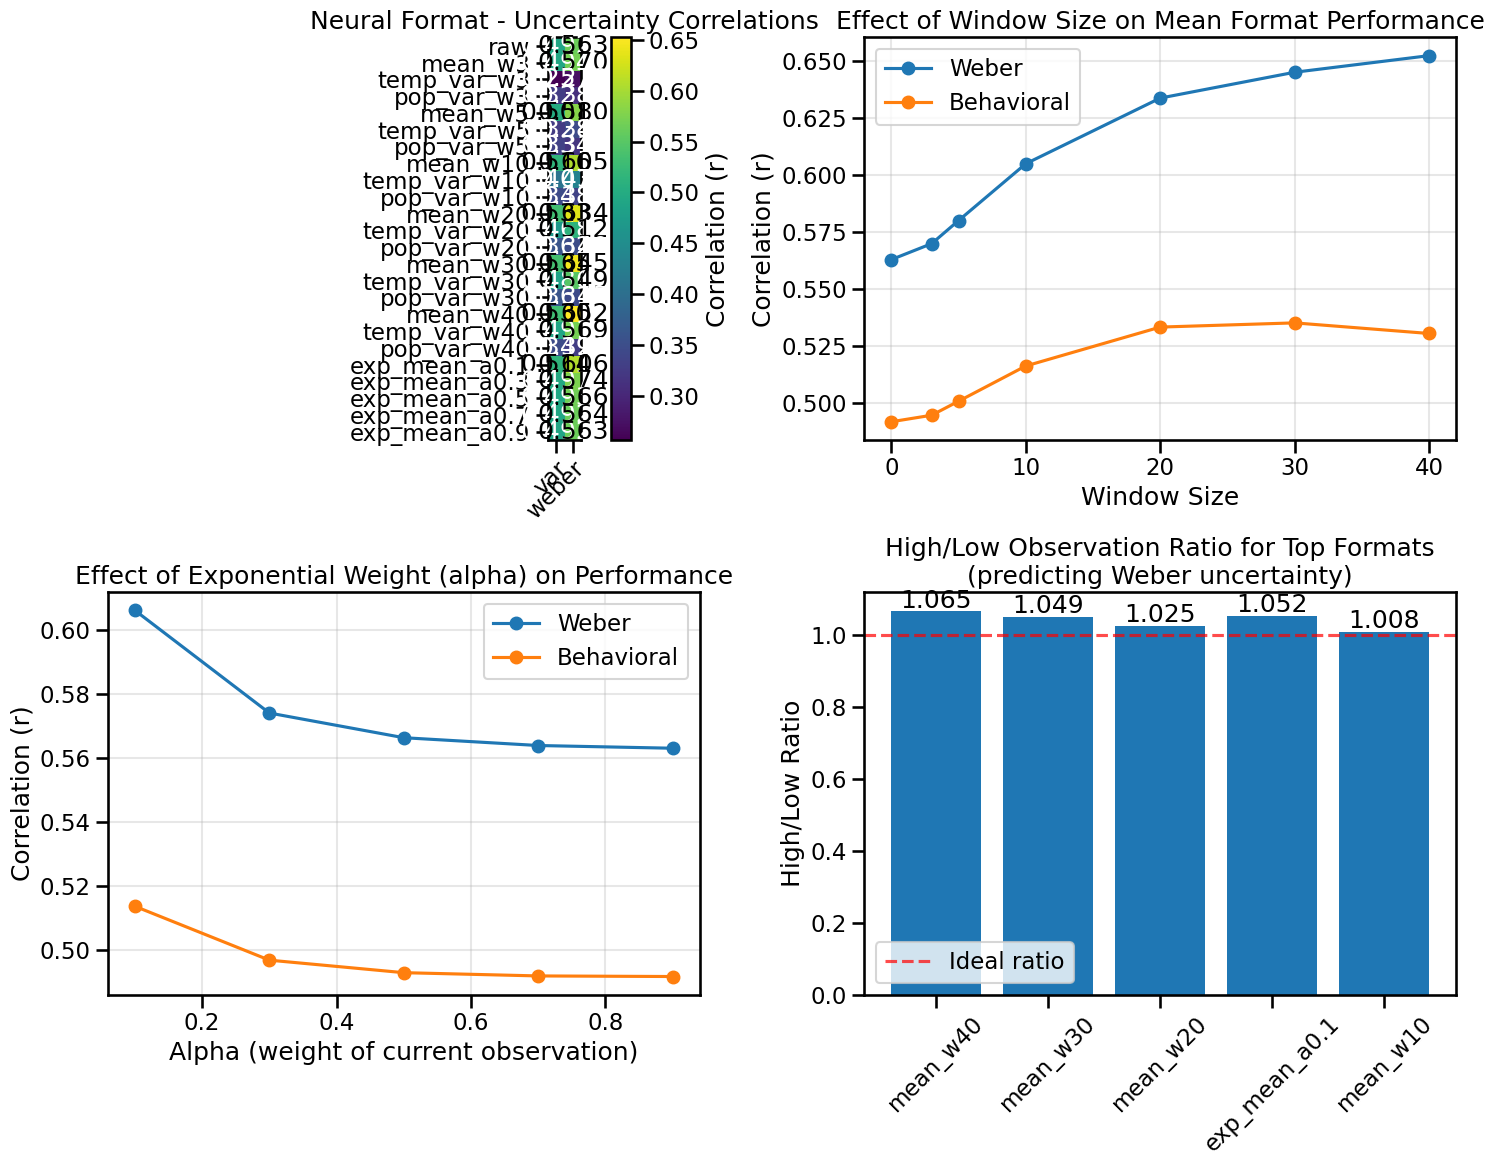


==== CROSS-VALIDATED NEURAL FORMAT ANALYSIS RESULTS ====
Session: 41, Number of neurons: 112

Best Neural Format - Uncertainty Combination:
  mean_w40 - weber: r = 0.652
  High observation: r = 0.653
  Low observation: r = 0.613
  High/Low ratio: 1.065

Window Size Effect (mean format with Weber uncertainty):
  raw: r = 0.563
  mean_w3: r = 0.570
  mean_w5: r = 0.580
  mean_w10: r = 0.605
  mean_w20: r = 0.634
  mean_w30: r = 0.645
  mean_w40: r = 0.652

Exponential Weighting Effect (with Weber uncertainty):
  alpha=0.1: r = 0.606
  alpha=0.3: r = 0.574
  alpha=0.5: r = 0.566
  alpha=0.7: r = 0.564
  alpha=0.9: r = 0.563

Top 5 Formats for Weber Uncertainty:
  mean_w40: r = 0.652
    High obs: r = 0.653, Low obs: r = 0.613
    High/Low ratio: 1.065
  mean_w30: r = 0.645
    High obs: r = 0.642, Low obs: r = 0.612
    High/Low ratio: 1.049
  mean_w20: r = 0.634
    High obs: r = 0.626, Low obs: r = 0.611
    High/Low ratio: 1.025
  exp_mean_a0.1: r = 0.606
    High obs: r = 0.618, Low 

In [39]:
def analyze_neural_formats_cross_validated(df, session_id=41):
    """
    Analyze how different neural activity formats encode uncertainty,
    with proper cross-validation for all analyses including high/low observation tests
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from scipy.stats import pearsonr
    from sklearn.model_selection import cross_val_predict, KFold
    import pandas as pd
    import seaborn as sns
    
    print(f"Analyzing session {session_id}")
    sessdf = df[df.session == session_id]
    print(f"Number of trials: {len(sessdf)}")
    
    # Create timedf
    timedf = pd.DataFrame({'timer': np.concatenate(sessdf.timer.to_numpy())})
    timedf['belief'] = np.concatenate(sessdf.belief_ff_hori.to_numpy())
    timedf['state'] = np.concatenate(sessdf.ff_hori.to_numpy())
    timedf['eye'] = np.concatenate(sessdf.eye_hori.to_numpy())
    timedf['timeratio'] = np.concatenate(sessdf.time_ratio.to_numpy())
    timedf['mv'] = np.concatenate(sessdf.mv.to_numpy())
    timedf['mw'] = np.concatenate(sessdf.mw.to_numpy())
    timedf['belief_heading'] = np.concatenate(sessdf.belief_heading.to_numpy())
    timedf['timer'] = np.concatenate(sessdf.timer.to_numpy())
    timedf['countdown'] = np.concatenate(sessdf.countdown.to_numpy())
    timedf['belief_angle_from_start'] = np.concatenate(sessdf.belief_angle_from_start.to_numpy())
    timedf['PPC'] = list(np.vstack(sessdf.PPC.to_numpy()))
    timedf['PPC_var'] = list(np.vstack(sessdf.PPC_var.to_numpy()))
    timedf['uncertainty'] = list(np.concatenate(sessdf.relcov.to_numpy()))
    
    # Extract trial information and visibility condition
    sessdf['fullon_t'] = sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
    sessdf['trial_t'] = sessdf.apply(lambda x: np.array([[x.trial]*len(x.mx)]).reshape(-1), axis=1)
    
    timedf['fullon'] = np.concatenate(sessdf.fullon_t.to_numpy())
    timedf['trial'] = np.concatenate(sessdf.trial_t.to_numpy())
    
    # Clean timedf
    timedf = timedf.dropna(subset=['eye', 'state', 'belief'])
    
    # Extract variables
    neural_data = np.stack(timedf.PPC.to_numpy())
    neural_var_data = np.stack(timedf.PPC_var.to_numpy())
    uncertainty_std = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5
    uncertainty_var = uncertainty_std**2
    observations = np.abs(timedf.mw.to_numpy())
    trial_ids = timedf.trial.to_numpy()
    
    # Create Weber uncertainty
    unique_trials = np.unique(trial_ids)
    weber_uncertainty = np.zeros_like(uncertainty_var)
    
    for trial in unique_trials:
        trial_mask = trial_ids == trial
        trial_obs = observations[trial_mask]
        trial_indices = np.where(trial_mask)[0]
        
        # Calculate accumulated uncertainty for this trial
        trial_weber = np.zeros(len(trial_obs))
        for i in range(len(trial_obs)):
            trial_weber[i] = np.sum(trial_obs[:i+1])
        
        weber_uncertainty[trial_indices] = trial_weber
    
    # Window sizes to test
    window_sizes = [3, 5, 10, 20, 30, 40]  # Added longer windows as suggested
    
    # Create dictionary of neural formats
    neural_formats = {'raw': neural_data}
    
    # Generate windowed neural features for each window size
    for window_size in window_sizes:
        # Moving window mean
        window_mean = np.zeros_like(neural_data)
        # Moving window temporal var
        window_temp_var = np.zeros_like(neural_data)
        # Moving window population var
        window_pop_var = np.zeros(neural_data.shape[0])
        
        for i in range(len(neural_data)):
            start_idx = max(0, i - window_size)
            end_idx = min(len(neural_data), i + window_size + 1)
            window_data = neural_data[start_idx:end_idx]
            
            # Mean across time window
            window_mean[i] = np.mean(window_data, axis=0)
            # Temporal variance across window
            window_temp_var[i] = np.var(window_data, axis=0)
            # Population variance within window
            window_pop_var[i] = np.var(np.mean(window_data, axis=0))
        
        # Add to neural formats
        neural_formats[f'mean_w{window_size}'] = window_mean
        neural_formats[f'temp_var_w{window_size}'] = window_temp_var
        neural_formats[f'pop_var_w{window_size}'] = window_pop_var.reshape(-1, 1)
    
    # Add exponential weighted windows
    alpha_values = [0.1, 0.3, 0.5, 0.7, 0.9]
    for alpha in alpha_values:
        # Exponentially weighted mean
        exp_mean = np.zeros_like(neural_data)
        
        # Process each trial separately to avoid leakage across trials
        for trial in unique_trials:
            trial_mask = trial_ids == trial
            trial_indices = np.where(trial_mask)[0]
            trial_data = neural_data[trial_mask]
            
            # Initialize with first time point
            exp_mean_trial = np.zeros_like(trial_data)
            exp_mean_trial[0] = trial_data[0]
            
            # Compute exponentially weighted mean for each time point
            for i in range(1, len(trial_data)):
                exp_mean_trial[i] = alpha * trial_data[i] + (1 - alpha) * exp_mean_trial[i-1]
            
            # Store in the main array
            exp_mean[trial_indices] = exp_mean_trial
        
        # Add to neural formats
        neural_formats[f'exp_mean_a{alpha}'] = exp_mean
    
    # Uncertainty representations
    uncertainty_reps = {
        'var': uncertainty_var,
        'weber': weber_uncertainty
    }
    
    # Prepare for results
    results = {}
    
    # Check for observation effects
    median_obs = np.median(observations)
    high_obs_mask = observations > median_obs
    low_obs_mask = ~high_obs_mask
    
    # Create result matrices
    format_names = list(neural_formats.keys())
    rep_names = list(uncertainty_reps.keys())
    
    corr_matrix = np.zeros((len(format_names), len(rep_names)))
    high_obs_matrix = np.zeros((len(format_names), len(rep_names)))
    low_obs_matrix = np.zeros((len(format_names), len(rep_names)))
    
    # Store best combination
    best_combo = None
    best_corr = -1
    
    # Set up cross-validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Analyze each combination
    for i, (format_name, format_data) in enumerate(neural_formats.items()):
        results[format_name] = {}
        
        for j, (rep_name, rep_data) in enumerate(uncertainty_reps.items()):
            # Overall cross-validated prediction
            predicted = cross_val_predict(LinearRegression(), format_data, rep_data, cv=kf)
            corr, p_val = pearsonr(predicted, rep_data)
            
            # Cross-validated prediction for high observations
            if np.sum(high_obs_mask) > 20:  # Ensure enough data
                high_pred = cross_val_predict(LinearRegression(), format_data[high_obs_mask], 
                                             rep_data[high_obs_mask], cv=5)
                high_corr, _ = pearsonr(high_pred, rep_data[high_obs_mask])
            else:
                high_corr = np.nan
            
            # Cross-validated prediction for low observations
            if np.sum(low_obs_mask) > 20:  # Ensure enough data
                low_pred = cross_val_predict(LinearRegression(), format_data[low_obs_mask], 
                                            rep_data[low_obs_mask], cv=5)
                low_corr, _ = pearsonr(low_pred, rep_data[low_obs_mask])
            else:
                low_corr = np.nan
            
            # Store results
            results[format_name][rep_name] = {
                'corr': corr,
                'p_val': p_val,
                'high_obs_corr': high_corr,
                'low_obs_corr': low_corr
            }
            
            # Update best combo
            if corr > best_corr:
                best_corr = corr
                best_combo = (format_name, rep_name)
            
            # Store correlation for heatmap
            corr_matrix[i, j] = corr
            high_obs_matrix[i, j] = high_corr
            low_obs_matrix[i, j] = low_corr
    
    # Get the best format and representation
    best_format, best_rep = best_combo
    best_result = results[best_format][best_rep]
    
    # Create visualizations
    plt.figure(figsize=(15, 12))
    
    # Plot 1: Heatmap of correlations
    plt.subplot(2, 2, 1)
    ax = plt.gca()
    im = ax.imshow(corr_matrix, cmap='viridis')
    
    # Add colorbar
    cbar = plt.colorbar(im)
    cbar.set_label('Correlation (r)')
    
    # Add labels
    ax.set_xticks(np.arange(len(rep_names)))
    ax.set_yticks(np.arange(len(format_names)))
    ax.set_xticklabels(rep_names)
    ax.set_yticklabels(format_names)
    
    # Rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add correlation value annotations
    for i in range(len(format_names)):
        for j in range(len(rep_names)):
            text = ax.text(j, i, f"{corr_matrix[i, j]:.3f}",
                          ha="center", va="center", color="white" if corr_matrix[i, j] < 0.5 else "black")
    
    plt.title('Neural Format - Uncertainty Correlations')
    
    # Plot 2: Window size effect
    plt.subplot(2, 2, 2)
    
    # Collect window sizes and correlations for mean format
    window_sizes_extended = [0] + window_sizes  # 0 for raw
    mean_weber_corrs = [results['raw']['weber']['corr']]
    mean_var_corrs = [results['raw']['var']['corr']]
    
    for size in window_sizes:
        format_name = f'mean_w{size}'
        if format_name in results:
            mean_weber_corrs.append(results[format_name]['weber']['corr'])
            mean_var_corrs.append(results[format_name]['var']['corr'])
    
    plt.plot(window_sizes_extended, mean_weber_corrs, 'o-', label='Weber')
    plt.plot(window_sizes_extended, mean_var_corrs, 'o-', label='Behavioral')
    
    plt.title('Effect of Window Size on Mean Format Performance')
    plt.xlabel('Window Size')
    plt.ylabel('Correlation (r)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Exponential weight effect
    plt.subplot(2, 2, 3)
    
    # Collect alpha values and correlations
    exp_weber_corrs = []
    exp_var_corrs = []
    
    for alpha in alpha_values:
        format_name = f'exp_mean_a{alpha}'
        if format_name in results:
            exp_weber_corrs.append(results[format_name]['weber']['corr'])
            exp_var_corrs.append(results[format_name]['var']['corr'])
    
    plt.plot(alpha_values, exp_weber_corrs, 'o-', label='Weber')
    plt.plot(alpha_values, exp_var_corrs, 'o-', label='Behavioral')
    
    plt.title('Effect of Exponential Weight (alpha) on Performance')
    plt.xlabel('Alpha (weight of current observation)')
    plt.ylabel('Correlation (r)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: High/Low observation ratio for top formats
    plt.subplot(2, 2, 4)
    
    # Find top 5 formats for Weber uncertainty
    weber_corrs = [results[format]['weber']['corr'] if 'weber' in results[format] else -1 for format in format_names]
    sorted_indices = np.argsort(weber_corrs)[::-1]
    top_formats = [format_names[i] for i in sorted_indices[:5]]
    
    # Calculate high/low ratios
    high_low_ratios = []
    for format_name in top_formats:
        result = results[format_name]['weber']
        if not np.isnan(result['high_obs_corr']) and not np.isnan(result['low_obs_corr']) and result['low_obs_corr'] > 0:
            ratio = result['high_obs_corr'] / result['low_obs_corr']
        else:
            ratio = np.nan
        high_low_ratios.append(ratio)
    
    # Plot
    bars = plt.bar(top_formats, high_low_ratios)
    plt.axhline(1.0, color='r', linestyle='--', alpha=0.7, label='Ideal ratio')
    
    plt.title('High/Low Observation Ratio for Top Formats\n(predicting Weber uncertainty)')
    plt.ylabel('High/Low Ratio')
    plt.xticks(rotation=45)
    plt.legend()
    
    # Add ratio values
    for bar, ratio in zip(bars, high_low_ratios):
        if not np.isnan(ratio):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f"{ratio:.3f}", ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # Print key results
    print("\n==== CROSS-VALIDATED NEURAL FORMAT ANALYSIS RESULTS ====")
    print(f"Session: {session_id}, Number of neurons: {neural_data.shape[1]}")
    
    print("\nBest Neural Format - Uncertainty Combination:")
    print(f"  {best_format} - {best_rep}: r = {best_result['corr']:.3f}")
    if not np.isnan(best_result['high_obs_corr']) and not np.isnan(best_result['low_obs_corr']):
        print(f"  High observation: r = {best_result['high_obs_corr']:.3f}")
        print(f"  Low observation: r = {best_result['low_obs_corr']:.3f}")
        print(f"  High/Low ratio: {best_result['high_obs_corr']/best_result['low_obs_corr']:.3f}")
    
    print("\nWindow Size Effect (mean format with Weber uncertainty):")
    for i, size in enumerate(window_sizes_extended):
        if i < len(mean_weber_corrs):
            name = "raw" if size == 0 else f"mean_w{size}"
            print(f"  {name}: r = {mean_weber_corrs[i]:.3f}")
    
    print("\nExponential Weighting Effect (with Weber uncertainty):")
    for i, alpha in enumerate(alpha_values):
        if i < len(exp_weber_corrs):
            print(f"  alpha={alpha}: r = {exp_weber_corrs[i]:.3f}")
    
    print("\nTop 5 Formats for Weber Uncertainty:")
    for i in range(5):
        if i < len(sorted_indices):
            idx = sorted_indices[i]
            format_name = format_names[idx]
            corr = weber_corrs[idx]
            result = results[format_name]['weber']
            print(f"  {format_name}: r = {corr:.3f}")
            if not np.isnan(result['high_obs_corr']) and not np.isnan(result['low_obs_corr']):
                print(f"    High obs: r = {result['high_obs_corr']:.3f}, Low obs: r = {result['low_obs_corr']:.3f}")
                print(f"    High/Low ratio: {result['high_obs_corr']/result['low_obs_corr']:.3f}")
    
    return results

# Run fully cross-validated analysis
neural_format_results_cv = analyze_neural_formats_cross_validated(df, session_id=41)

Analyzing trial-level uncertainty for session 41
Number of trials: 1538


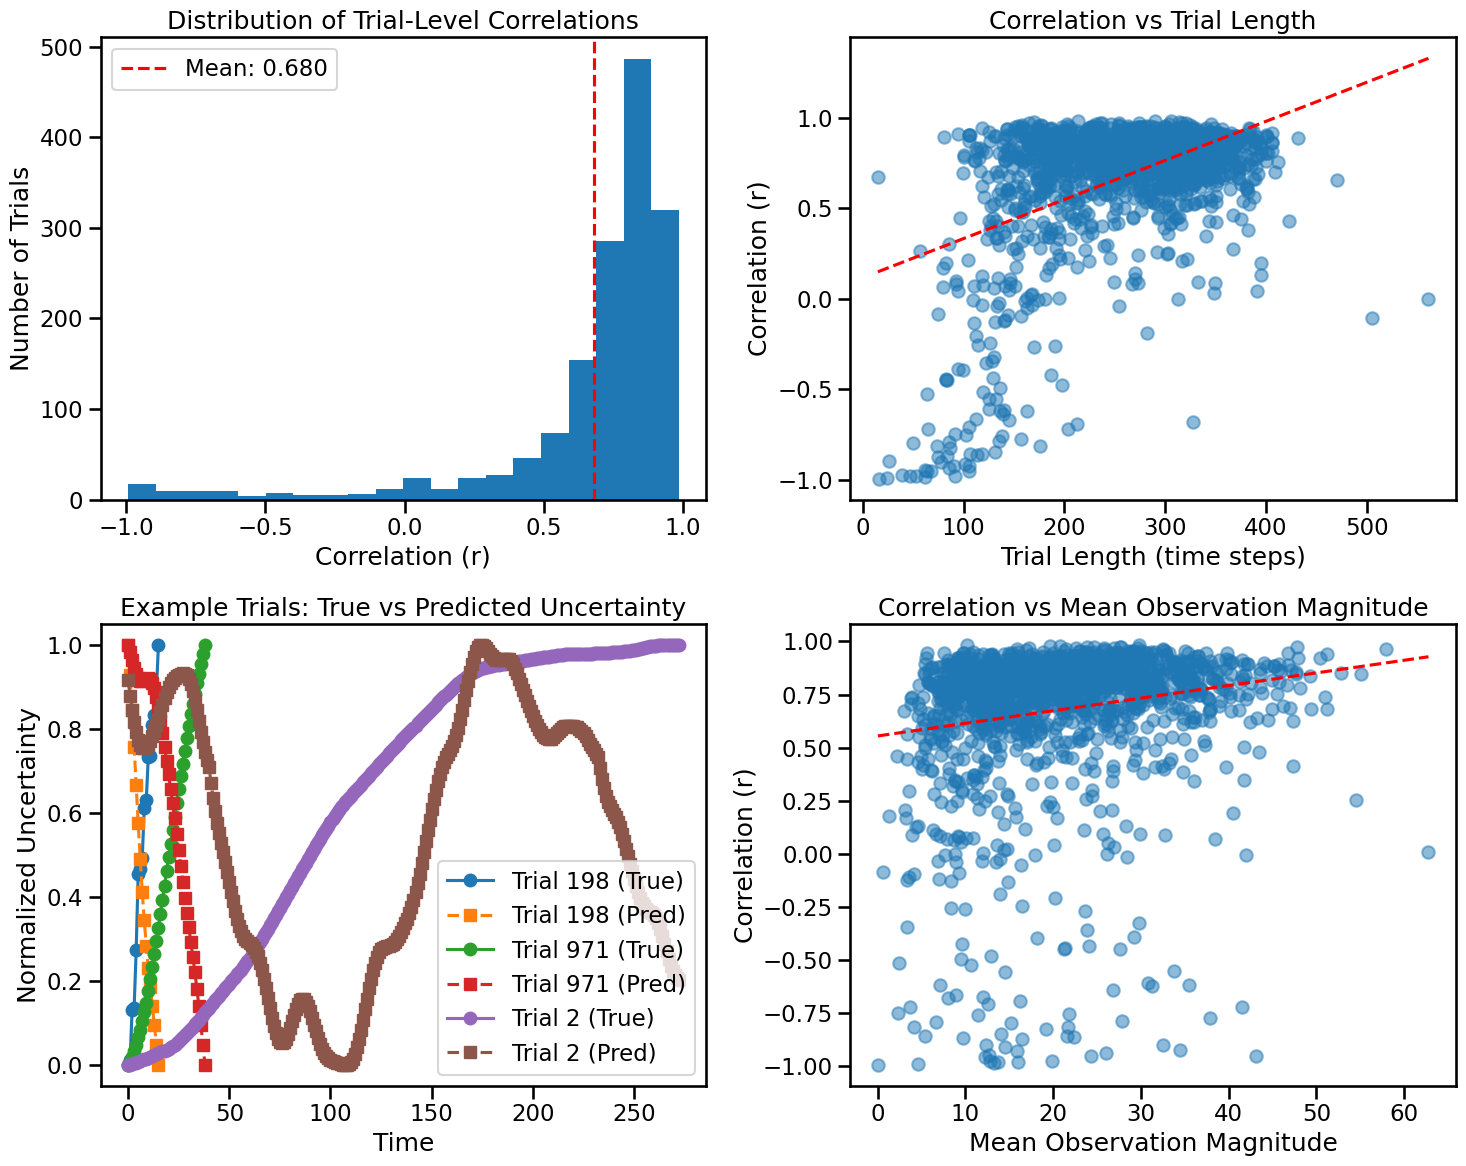


==== TRIAL-LEVEL UNCERTAINTY ANALYSIS ====
Number of trials analyzed: 1537
Mean trial-level correlation: 0.680 ± 0.356
Range of correlations: -0.993 to 0.984
Correlation with trial length: 0.473
Correlation with mean observation magnitude: 0.169
Visible trials: mean corr = 0.674 ± 0.379
Hidden trials: mean corr = 0.680 ± 0.353
Analyzing neuronal contributions for session 41
Number of trials: 1538
Number of neurons: 112
Number of significant neurons: 110 (98.2%)


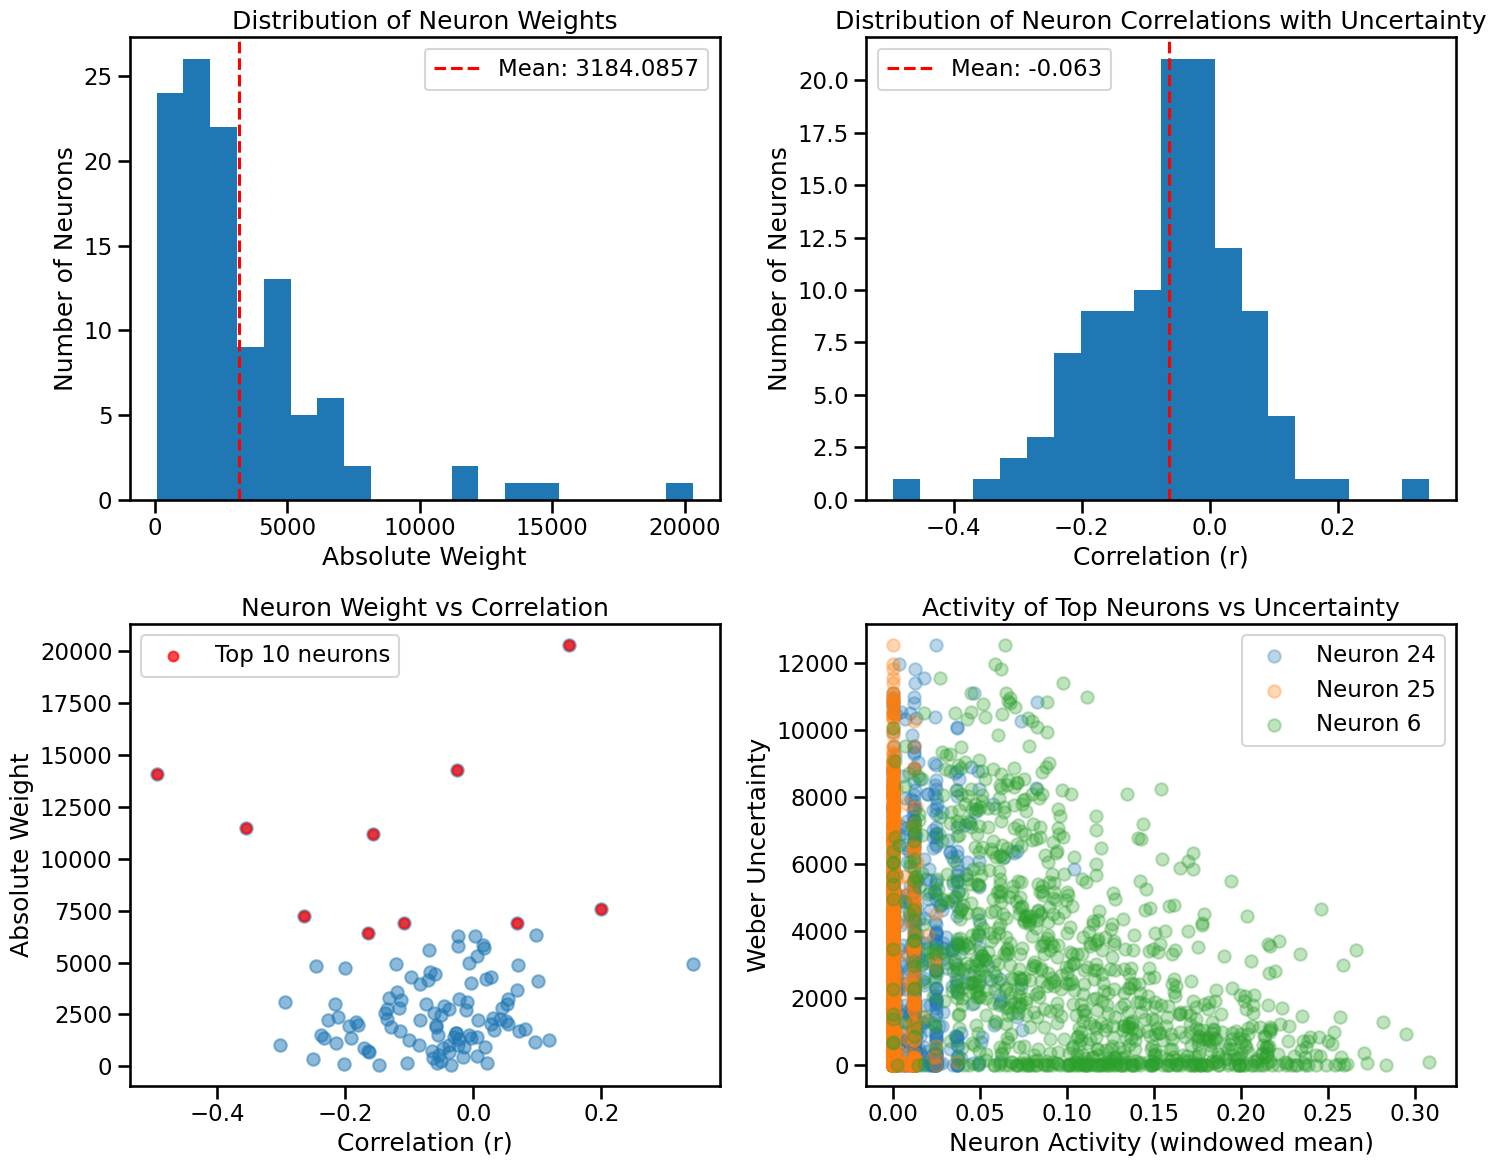


==== NEURONAL CONTRIBUTION ANALYSIS ====
Top 10 neurons by weight:
  Neuron 24: weight = 20307.7402, corr = 0.150
  Neuron 25: weight = 14259.5781, corr = -0.025
  Neuron 6: weight = 14085.8086, corr = -0.495
  Neuron 68: weight = 11505.0020, corr = -0.355
  Neuron 103: weight = 11214.8438, corr = -0.156
  Neuron 38: weight = 7597.9487, corr = 0.200
  Neuron 104: weight = 7244.9912, corr = -0.264
  Neuron 67: weight = 6911.4971, corr = -0.108
  Neuron 3: weight = 6895.2715, corr = 0.068
  Neuron 51: weight = 6412.2461, corr = -0.165


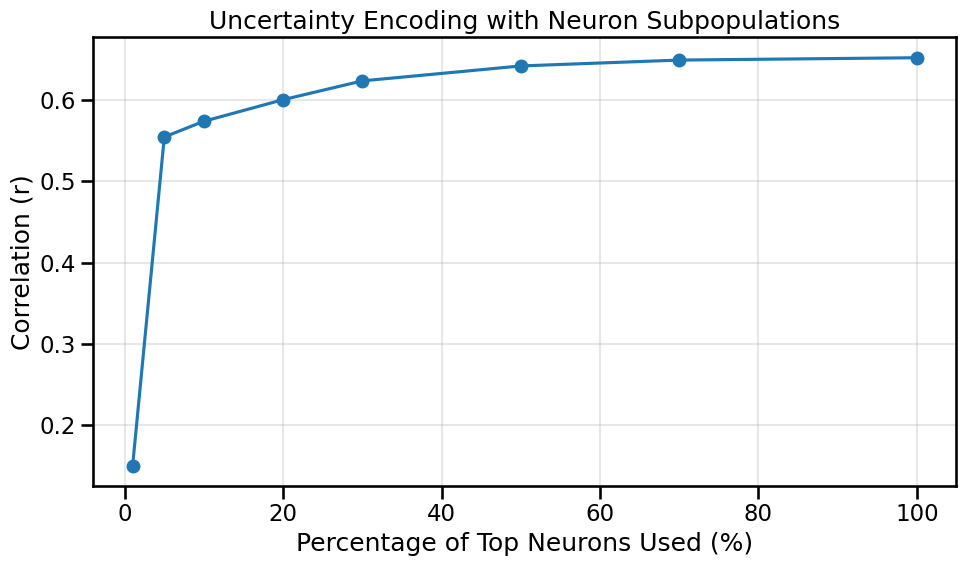


Subpopulation performance:
  Top 1% neurons: r = 0.150
  Top 5% neurons: r = 0.555
  Top 10% neurons: r = 0.574
  Top 20% neurons: r = 0.601
  Top 30% neurons: r = 0.624
  Top 50% neurons: r = 0.642
  Top 70% neurons: r = 0.650
  Top 100% neurons: r = 0.653


In [41]:
def analyze_trial_level_uncertainty(df, session_id=41, window_size=40):
    """
    Analyze how neural activity tracks uncertainty within individual trials
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from scipy.stats import pearsonr
    import pandas as pd
    
    print(f"Analyzing trial-level uncertainty for session {session_id}")
    sessdf = df[df.session == session_id]
    print(f"Number of trials: {len(sessdf)}")
    
    # Create timedf
    timedf = pd.DataFrame({'timer': np.concatenate(sessdf.timer.to_numpy())})
    timedf['belief'] = np.concatenate(sessdf.belief_ff_hori.to_numpy())
    timedf['state'] = np.concatenate(sessdf.ff_hori.to_numpy())
    timedf['eye'] = np.concatenate(sessdf.eye_hori.to_numpy())
    timedf['timeratio'] = np.concatenate(sessdf.time_ratio.to_numpy())
    timedf['mv'] = np.concatenate(sessdf.mv.to_numpy())
    timedf['mw'] = np.concatenate(sessdf.mw.to_numpy())
    timedf['belief_heading'] = np.concatenate(sessdf.belief_heading.to_numpy())
    timedf['timer'] = np.concatenate(sessdf.timer.to_numpy())
    timedf['countdown'] = np.concatenate(sessdf.countdown.to_numpy())
    timedf['belief_angle_from_start'] = np.concatenate(sessdf.belief_angle_from_start.to_numpy())
    timedf['PPC'] = list(np.vstack(sessdf.PPC.to_numpy()))
    timedf['PPC_var'] = list(np.vstack(sessdf.PPC_var.to_numpy()))
    timedf['uncertainty'] = list(np.concatenate(sessdf.relcov.to_numpy()))
    
    # Extract trial information and visibility condition
    sessdf['fullon_t'] = sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
    sessdf['trial_t'] = sessdf.apply(lambda x: np.array([[x.trial]*len(x.mx)]).reshape(-1), axis=1)
    
    timedf['fullon'] = np.concatenate(sessdf.fullon_t.to_numpy())
    timedf['trial'] = np.concatenate(sessdf.trial_t.to_numpy())
    
    # Clean timedf
    timedf = timedf.dropna(subset=['eye', 'state', 'belief'])
    
    # Extract variables
    neural_data = np.stack(timedf.PPC.to_numpy())
    uncertainty_std = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5
    uncertainty_var = uncertainty_std**2
    observations = np.abs(timedf.mw.to_numpy())
    trial_ids = timedf.trial.to_numpy()
    time_ratio = timedf.timeratio.to_numpy()
    timer = timedf.timer.to_numpy()
    
    # Create Weber uncertainty
    unique_trials = np.unique(trial_ids)
    weber_uncertainty = np.zeros_like(uncertainty_var)
    
    for trial in unique_trials:
        trial_mask = trial_ids == trial
        trial_obs = observations[trial_mask]
        trial_indices = np.where(trial_mask)[0]
        
        # Calculate accumulated uncertainty
        trial_weber = np.zeros(len(trial_obs))
        for i in range(len(trial_obs)):
            trial_weber[i] = np.sum(trial_obs[:i+1])
        
        weber_uncertainty[trial_indices] = trial_weber
    
    # Create windowed mean neural data (using the best window size)
    window_mean = np.zeros_like(neural_data)
    
    for i in range(len(neural_data)):
        start_idx = max(0, i - window_size)
        end_idx = min(len(neural_data), i + window_size + 1)
        window_mean[i] = np.mean(neural_data[start_idx:end_idx], axis=0)
    
    # Train a global model
    model = LinearRegression()
    model.fit(window_mean, weber_uncertainty)
    
    # Predict uncertainty
    predicted_uncertainty = model.predict(window_mean)
    
    # Analyze trial-by-trial correlations
    min_length = 15  # Minimum trial length to analyze
    trial_correlations = []
    trial_lengths = []
    trial_visibility = []
    trial_mean_obs = []
    example_trials = []
    
    # Find a few representative trials of different lengths for visualization
    short_example = None
    medium_example = None
    long_example = None
    
    # Analyze each trial
    for trial in unique_trials:
        trial_mask = trial_ids == trial
        trial_indices = np.where(trial_mask)[0]
        
        if len(trial_indices) >= min_length:
            trial_pred = predicted_uncertainty[trial_mask]
            trial_weber = weber_uncertainty[trial_mask]
            
            # Calculate correlation for this trial
            trial_corr, p_val = pearsonr(trial_pred, trial_weber)
            
            if not np.isnan(trial_corr):
                trial_correlations.append(trial_corr)
                trial_lengths.append(len(trial_indices))
                trial_visibility.append(timedf.fullon.iloc[trial_indices[0]])
                trial_mean_obs.append(np.mean(observations[trial_mask]))
                
                # Check if this trial is a good example for visualization
                is_hidden = timedf.fullon.iloc[trial_indices[0]] == 0
                
                if is_hidden:
                    if short_example is None and len(trial_indices) < 30:
                        short_example = trial
                    elif medium_example is None and 30 <= len(trial_indices) < 50:
                        medium_example = trial
                    elif long_example is None and len(trial_indices) >= 50:
                        long_example = trial
    
    example_trials = [short_example, medium_example, long_example]
    example_trials = [t for t in example_trials if t is not None]
    
    # Create visualizations
    plt.figure(figsize=(15, 12))
    
    # Plot 1: Distribution of trial-level correlations
    plt.subplot(2, 2, 1)
    plt.hist(trial_correlations, bins=20)
    plt.axvline(np.mean(trial_correlations), color='r', linestyle='--', 
               label=f'Mean: {np.mean(trial_correlations):.3f}')
    
    plt.title('Distribution of Trial-Level Correlations')
    plt.xlabel('Correlation (r)')
    plt.ylabel('Number of Trials')
    plt.legend()
    
    # Plot 2: Correlation vs trial length
    plt.subplot(2, 2, 2)
    plt.scatter(trial_lengths, trial_correlations, alpha=0.5)
    
    # Add trend line
    z = np.polyfit(trial_lengths, trial_correlations, 1)
    p = np.poly1d(z)
    plt.plot(sorted(trial_lengths), p(sorted(trial_lengths)), 'r--')
    
    plt.title('Correlation vs Trial Length')
    plt.xlabel('Trial Length (time steps)')
    plt.ylabel('Correlation (r)')
    
    # Plot 3: Example trials
    plt.subplot(2, 2, 3)
    
    for i, trial in enumerate(example_trials):
        if trial is not None:
            trial_mask = trial_ids == trial
            trial_weber = weber_uncertainty[trial_mask]
            trial_pred = predicted_uncertainty[trial_mask]
            trial_time = timer[trial_mask]
            
            # Normalize for better visualization
            trial_weber_norm = (trial_weber - min(trial_weber)) / (max(trial_weber) - min(trial_weber))
            trial_pred_norm = (trial_pred - min(trial_pred)) / (max(trial_pred) - min(trial_pred))
            
            plt.plot(trial_time, trial_weber_norm, 'o-', label=f'Trial {trial} (True)')
            plt.plot(trial_time, trial_pred_norm, 's--', label=f'Trial {trial} (Pred)')
    
    plt.title('Example Trials: True vs Predicted Uncertainty')
    plt.xlabel('Time')
    plt.ylabel('Normalized Uncertainty')
    plt.legend()
    
    # Plot 4: Correlation vs mean observation magnitude
    plt.subplot(2, 2, 4)
    plt.scatter(trial_mean_obs, trial_correlations, alpha=0.5)
    
    # Add trend line
    z = np.polyfit(trial_mean_obs, trial_correlations, 1)
    p = np.poly1d(z)
    plt.plot(sorted(trial_mean_obs), p(sorted(trial_mean_obs)), 'r--')
    
    plt.title('Correlation vs Mean Observation Magnitude')
    plt.xlabel('Mean Observation Magnitude')
    plt.ylabel('Correlation (r)')
    
    plt.tight_layout()
    plt.show()
    
    # Print key results
    print("\n==== TRIAL-LEVEL UNCERTAINTY ANALYSIS ====")
    print(f"Number of trials analyzed: {len(trial_correlations)}")
    print(f"Mean trial-level correlation: {np.mean(trial_correlations):.3f} ± {np.std(trial_correlations):.3f}")
    print(f"Range of correlations: {min(trial_correlations):.3f} to {max(trial_correlations):.3f}")
    
    # Calculate correlation with trial characteristics
    length_corr, _ = pearsonr(trial_lengths, trial_correlations)
    obs_corr, _ = pearsonr(trial_mean_obs, trial_correlations)
    
    print(f"Correlation with trial length: {length_corr:.3f}")
    print(f"Correlation with mean observation magnitude: {obs_corr:.3f}")
    
    # Analyze visible vs hidden trials
    visible_trials = [i for i, v in enumerate(trial_visibility) if v == 1]
    hidden_trials = [i for i, v in enumerate(trial_visibility) if v == 0]
    
    if visible_trials and hidden_trials:
        visible_corrs = [trial_correlations[i] for i in visible_trials]
        hidden_corrs = [trial_correlations[i] for i in hidden_trials]
        
        print(f"Visible trials: mean corr = {np.mean(visible_corrs):.3f} ± {np.std(visible_corrs):.3f}")
        print(f"Hidden trials: mean corr = {np.mean(hidden_corrs):.3f} ± {np.std(hidden_corrs):.3f}")
    
    return {
        'trial_correlations': trial_correlations,
        'trial_lengths': trial_lengths,
        'trial_visibility': trial_visibility,
        'trial_mean_obs': trial_mean_obs
    }

def analyze_neuronal_contributions(df, session_id=41, window_size=40):
    """
    Analyze which neurons contribute most to uncertainty encoding
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from scipy.stats import pearsonr
    import pandas as pd
    
    print(f"Analyzing neuronal contributions for session {session_id}")
    sessdf = df[df.session == session_id]
    print(f"Number of trials: {len(sessdf)}")
    
    # Create timedf
    timedf = pd.DataFrame({'timer': np.concatenate(sessdf.timer.to_numpy())})
    timedf['belief'] = np.concatenate(sessdf.belief_ff_hori.to_numpy())
    timedf['state'] = np.concatenate(sessdf.ff_hori.to_numpy())
    timedf['eye'] = np.concatenate(sessdf.eye_hori.to_numpy())
    timedf['timeratio'] = np.concatenate(sessdf.time_ratio.to_numpy())
    timedf['mv'] = np.concatenate(sessdf.mv.to_numpy())
    timedf['mw'] = np.concatenate(sessdf.mw.to_numpy())
    timedf['belief_heading'] = np.concatenate(sessdf.belief_heading.to_numpy())
    timedf['timer'] = np.concatenate(sessdf.timer.to_numpy())
    timedf['countdown'] = np.concatenate(sessdf.countdown.to_numpy())
    timedf['belief_angle_from_start'] = np.concatenate(sessdf.belief_angle_from_start.to_numpy())
    timedf['PPC'] = list(np.vstack(sessdf.PPC.to_numpy()))
    timedf['PPC_var'] = list(np.vstack(sessdf.PPC_var.to_numpy()))
    timedf['uncertainty'] = list(np.concatenate(sessdf.relcov.to_numpy()))
    
    # Extract trial information and visibility condition
    sessdf['fullon_t'] = sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
    sessdf['trial_t'] = sessdf.apply(lambda x: np.array([[x.trial]*len(x.mx)]).reshape(-1), axis=1)
    
    timedf['fullon'] = np.concatenate(sessdf.fullon_t.to_numpy())
    timedf['trial'] = np.concatenate(sessdf.trial_t.to_numpy())
    
    # Clean timedf
    timedf = timedf.dropna(subset=['eye', 'state', 'belief'])
    
    # Extract variables
    neural_data = np.stack(timedf.PPC.to_numpy())
    observations = np.abs(timedf.mw.to_numpy())
    trial_ids = timedf.trial.to_numpy()
    time_ratio = timedf.timeratio.to_numpy()
    
    # Create Weber uncertainty
    unique_trials = np.unique(trial_ids)
    weber_uncertainty = np.zeros_like(time_ratio)
    
    for trial in unique_trials:
        trial_mask = trial_ids == trial
        trial_obs = observations[trial_mask]
        trial_indices = np.where(trial_mask)[0]
        
        # Calculate accumulated uncertainty
        trial_weber = np.zeros(len(trial_obs))
        for i in range(len(trial_obs)):
            trial_weber[i] = np.sum(trial_obs[:i+1])
        
        weber_uncertainty[trial_indices] = trial_weber
    
    # Create windowed mean neural data
    window_mean = np.zeros_like(neural_data)
    
    for i in range(len(neural_data)):
        start_idx = max(0, i - window_size)
        end_idx = min(len(neural_data), i + window_size + 1)
        window_mean[i] = np.mean(neural_data[start_idx:end_idx], axis=0)
    
    # Number of neurons
    n_neurons = neural_data.shape[1]
    print(f"Number of neurons: {n_neurons}")
    
    # Train a model to get neuron weights
    model = LinearRegression()
    model.fit(window_mean, weber_uncertainty)
    
    # Get absolute weights
    neuron_weights = np.abs(model.coef_)
    
    # Calculate individual neuron correlations with uncertainty
    neuron_corrs = []
    neuron_p_vals = []
    
    for i in range(n_neurons):
        corr, p_val = pearsonr(window_mean[:, i], weber_uncertainty)
        neuron_corrs.append(corr)
        neuron_p_vals.append(p_val)
    
    # Identify significant neurons (p < 0.05)
    sig_neurons = np.where(np.array(neuron_p_vals) < 0.05)[0]
    print(f"Number of significant neurons: {len(sig_neurons)} ({len(sig_neurons)/n_neurons*100:.1f}%)")
    
    # Sort neurons by weight
    sorted_indices = np.argsort(neuron_weights)[::-1]
    top_neurons = sorted_indices[:10]
    
    # Visualizations
    plt.figure(figsize=(15, 12))
    
    # Plot 1: Distribution of neuron weights
    plt.subplot(2, 2, 1)
    plt.hist(neuron_weights, bins=20)
    plt.axvline(np.mean(neuron_weights), color='r', linestyle='--', 
               label=f'Mean: {np.mean(neuron_weights):.4f}')
    
    plt.title('Distribution of Neuron Weights')
    plt.xlabel('Absolute Weight')
    plt.ylabel('Number of Neurons')
    plt.legend()
    
    # Plot 2: Distribution of neuron correlations
    plt.subplot(2, 2, 2)
    plt.hist(neuron_corrs, bins=20)
    plt.axvline(np.mean(neuron_corrs), color='r', linestyle='--', 
               label=f'Mean: {np.mean(neuron_corrs):.3f}')
    
    plt.title('Distribution of Neuron Correlations with Uncertainty')
    plt.xlabel('Correlation (r)')
    plt.ylabel('Number of Neurons')
    plt.legend()
    
    # Plot 3: Weight vs correlation
    plt.subplot(2, 2, 3)
    plt.scatter(neuron_corrs, neuron_weights, alpha=0.5)
    
    # Highlight top neurons
    top_corrs = [neuron_corrs[i] for i in top_neurons]
    top_weights = [neuron_weights[i] for i in top_neurons]
    plt.scatter(top_corrs, top_weights, color='red', s=50, alpha=0.7, label='Top 10 neurons')
    
    plt.title('Neuron Weight vs Correlation')
    plt.xlabel('Correlation (r)')
    plt.ylabel('Absolute Weight')
    plt.legend()
    
    # Plot 4: Activity of top neurons vs uncertainty
    plt.subplot(2, 2, 4)
    
    # Get a subset of data for visualization
    subset_size = min(1000, len(weber_uncertainty))
    indices = np.random.choice(len(weber_uncertainty), subset_size, replace=False)
    
    # For each top neuron, plot its activity against uncertainty
    for i, neuron_idx in enumerate(top_neurons[:3]):  # Plot top 3 for clarity
        neuron_activity = window_mean[indices, neuron_idx]
        uncertainty = weber_uncertainty[indices]
        
        plt.scatter(neuron_activity, uncertainty, alpha=0.3, label=f'Neuron {neuron_idx}')
    
    plt.title('Activity of Top Neurons vs Uncertainty')
    plt.xlabel('Neuron Activity (windowed mean)')
    plt.ylabel('Weber Uncertainty')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print key results
    print("\n==== NEURONAL CONTRIBUTION ANALYSIS ====")
    print("Top 10 neurons by weight:")
    for i, neuron_idx in enumerate(top_neurons):
        print(f"  Neuron {neuron_idx}: weight = {neuron_weights[neuron_idx]:.4f}, corr = {neuron_corrs[neuron_idx]:.3f}")
    
    # Analyze subpopulation performance
    # How well can we predict uncertainty with just the top neurons?
    top_percentages = [1, 5, 10, 20, 30, 50, 70, 100]
    subpop_corrs = []
    
    for percentage in top_percentages:
        n_top = int(n_neurons * percentage / 100)
        top_indices = sorted_indices[:n_top]
        
        # Train model with just these neurons
        subpop_model = LinearRegression()
        subpop_model.fit(window_mean[:, top_indices], weber_uncertainty)
        
        # Predict and calculate correlation
        subpop_pred = subpop_model.predict(window_mean[:, top_indices])
        subpop_corr, _ = pearsonr(subpop_pred, weber_uncertainty)
        subpop_corrs.append(subpop_corr)
    
    # Plot subpopulation performance
    plt.figure(figsize=(10, 6))
    plt.plot(top_percentages, subpop_corrs, 'o-')
    plt.title('Uncertainty Encoding with Neuron Subpopulations')
    plt.xlabel('Percentage of Top Neurons Used (%)')
    plt.ylabel('Correlation (r)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nSubpopulation performance:")
    for i, percentage in enumerate(top_percentages):
        print(f"  Top {percentage}% neurons: r = {subpop_corrs[i]:.3f}")
    
    return {
        'neuron_weights': neuron_weights,
        'neuron_corrs': neuron_corrs,
        'top_neurons': top_neurons,
        'subpop_corrs': subpop_corrs,
        'top_percentages': top_percentages
    }

# Run the trial-level analysis
trial_results = analyze_trial_level_uncertainty(df, session_id=41, window_size=40)

# Run the neuronal contribution analysis
neuron_results = analyze_neuronal_contributions(df, session_id=41, window_size=40)

# Trash

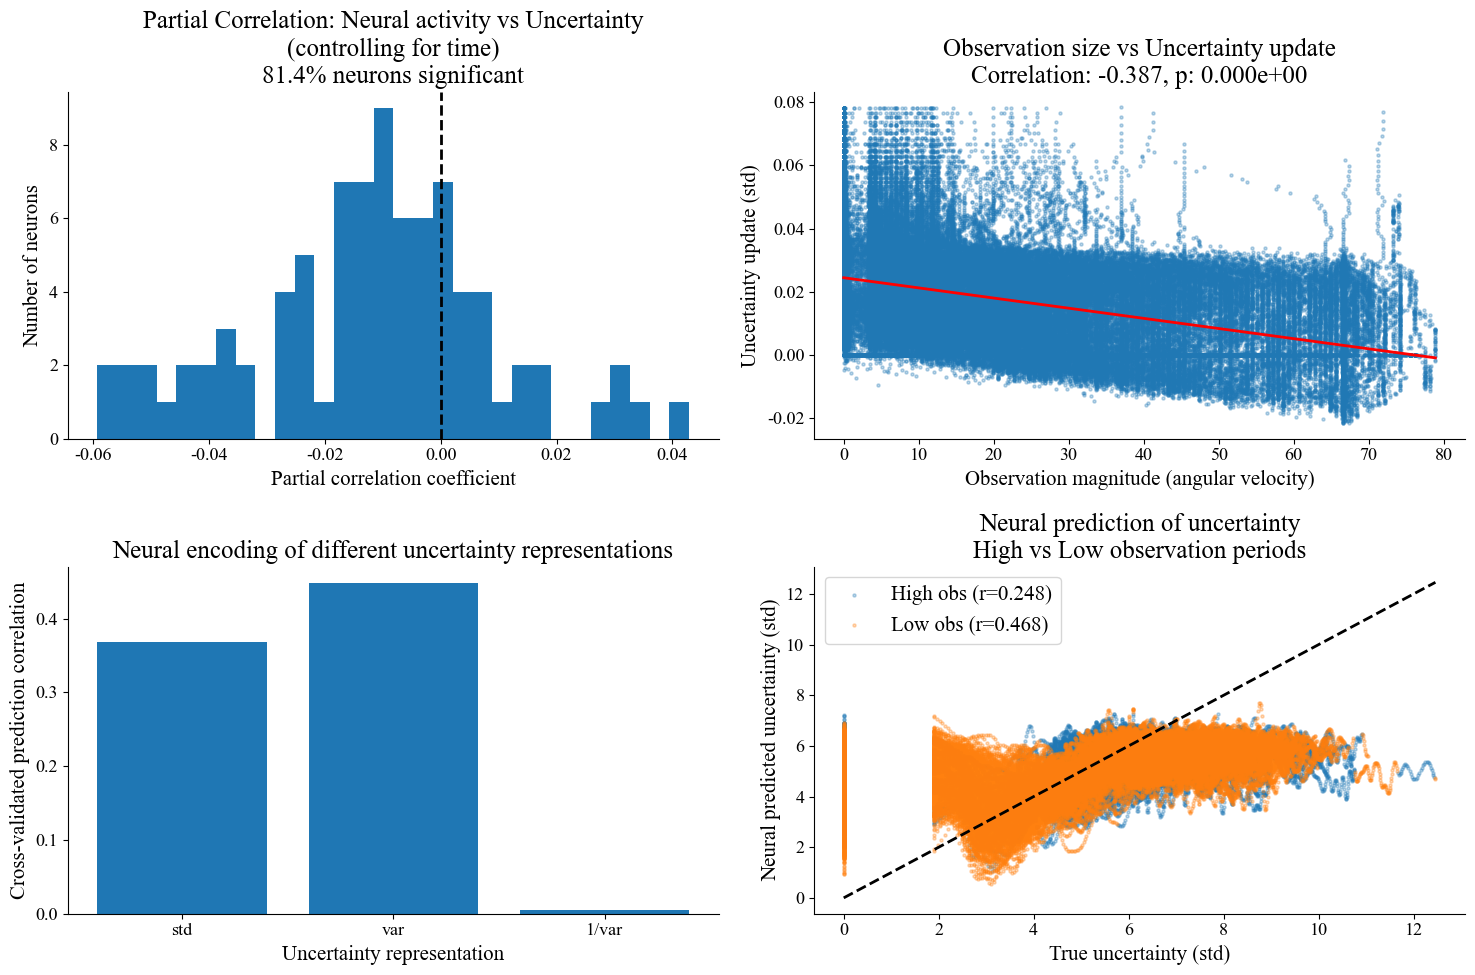

==== KEY RESULTS ====
Percentage of neurons significantly encoding uncertainty (controlling for time): 81.4%
Mean partial correlation: -0.012
Correlation between observation magnitude and uncertainty update: -0.387 (p: 0.000e+00)

Uncertainty representation comparison:
  std: r = 0.369 (p: 0.000e+00)
  var: r = 0.448 (p: 0.000e+00)
  1/var: r = 0.004 (p: 7.591e-02)

Neural prediction during high vs low observation periods:
  High obs correlation: 0.248
  Low obs correlation: 0.468
  Prediction is worse during high observation periods


In [13]:
def analyze_uncertainty_encoding(timedf, plot=True):
    """
    Analyze how neural activity encodes uncertainty while controlling for time effects
    
    Parameters:
    -----------
    timedf : pandas DataFrame
        DataFrame containing trial data with neural activity and behavioral variables
    plot : bool
        Whether to generate plots
        
    Returns:
    --------
    results : dict
        Dictionary containing analysis results
    """
    from sklearn.linear_model import LinearRegression
    from sklearn.model_selection import cross_val_predict
    from scipy.stats import pearsonr, spearmanr
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.preprocessing import StandardScaler
    from statsmodels.stats.weightstats import ttest_ind
    
    results = {}
    
    # Extract variables
    neural_data = np.stack(timedf.PPC.to_numpy())
    uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    time_ratio = timedf.timeratio.to_numpy()
    observations = np.abs(timedf.mw.to_numpy())  # absolute angular velocity
    trial_ids = timedf.trial.to_numpy()
    
    # 1. Partial correlation analysis: Uncertainty vs Neural activity controlling for time
    # First, regress out time from both neural and uncertainty
    scaler = StandardScaler()
    neural_data_scaled = scaler.fit_transform(neural_data)
    uncertainty_scaled = scaler.fit_transform(uncertainty.reshape(-1, 1)).flatten()
    time_scaled = scaler.fit_transform(time_ratio.reshape(-1, 1)).flatten()
    
    # Regress out time from neural data
    time_model_neural = LinearRegression()
    time_model_neural.fit(time_scaled.reshape(-1, 1), neural_data_scaled)
    neural_residuals = neural_data_scaled - time_model_neural.predict(time_scaled.reshape(-1, 1))
    
    # Regress out time from uncertainty
    time_model_uncertainty = LinearRegression()
    time_model_uncertainty.fit(time_scaled.reshape(-1, 1), uncertainty_scaled.reshape(-1, 1))
    uncertainty_residuals = uncertainty_scaled - time_model_uncertainty.predict(time_scaled.reshape(-1, 1)).flatten()
    
    # Find neurons that encode uncertainty after controlling for time
    partial_corrs = []
    p_values = []
    for neuron_idx in range(neural_data.shape[1]):
        r, p = pearsonr(neural_residuals[:, neuron_idx], uncertainty_residuals)
        partial_corrs.append(r)
        p_values.append(p)
    
    # Calculate percentage of neurons that significantly encode uncertainty
    alpha = 0.05  # significance level
    significant_neurons = np.sum(np.array(p_values) < alpha)
    percent_significant = significant_neurons / len(p_values) * 100
    
    results['partial_corrs'] = partial_corrs
    results['p_values'] = p_values
    results['significant_neurons'] = significant_neurons
    results['percent_significant'] = percent_significant
    
    # 2. Analyze uncertainty update in relation to observation size
    # Group by trial and compute updates
    trial_updates = {}
    for trial_id in np.unique(trial_ids):
        trial_mask = trial_ids == trial_id
        trial_uncertainty = uncertainty[trial_mask]
        trial_observations = observations[trial_mask]
        
        if len(trial_uncertainty) > 1:
            # Calculate uncertainty updates
            uncertainty_updates = np.diff(trial_uncertainty)
            obs_values = trial_observations[:-1]  # observations before updates
            
            trial_updates[trial_id] = {
                'uncertainty_updates': uncertainty_updates,
                'observations': obs_values
            }
    
    # Combine all updates
    all_updates = np.concatenate([d['uncertainty_updates'] for d in trial_updates.values()])
    all_obs = np.concatenate([d['observations'] for d in trial_updates.values()])
    
    # Correlation between observation size and uncertainty update
    update_obs_corr, update_obs_p = pearsonr(all_obs, all_updates)
    results['update_obs_corr'] = update_obs_corr
    results['update_obs_p'] = update_obs_p
    
    # 3. Neural representation of uncertainty across different forms
    # Test different transformations of uncertainty (std, var, 1/var)
    uncertainty_var = uncertainty**2
    uncertainty_inv_var = 1 / (uncertainty_var + 1e-6)  # avoid division by zero
    
    # Linear models for each transformation
    model_std = LinearRegression()
    model_var = LinearRegression()
    model_inv_var = LinearRegression()
    
    # Cross-validation prediction
    predicted_std = cross_val_predict(model_std, neural_data, uncertainty, cv=5)
    predicted_var = cross_val_predict(model_var, neural_data, uncertainty_var, cv=5)
    predicted_inv_var = cross_val_predict(model_inv_var, neural_data, uncertainty_inv_var, cv=5)
    
    # Correlation between predicted and actual values
    corr_std, p_std = pearsonr(predicted_std, uncertainty)
    corr_var, p_var = pearsonr(predicted_var, uncertainty_var)
    corr_inv_var, p_inv_var = pearsonr(predicted_inv_var, uncertainty_inv_var)
    
    # Store results
    results['uncertainty_representations'] = {
        'std': {'corr': corr_std, 'p': p_std},
        'var': {'corr': corr_var, 'p': p_var},
        'inv_var': {'corr': corr_inv_var, 'p': p_inv_var}
    }
    
    # 4. Compare neural prediction of uncertainty during high vs low observation periods
    median_obs = np.median(observations)
    high_obs_mask = observations > median_obs
    low_obs_mask = observations <= median_obs
    
    # Fit model on all data
    uncertainty_model = LinearRegression()
    uncertainty_model.fit(neural_data, uncertainty)
    
    # Predict uncertainty for high and low observation periods
    neural_uncertainty_high = uncertainty_model.predict(neural_data[high_obs_mask])
    true_uncertainty_high = uncertainty[high_obs_mask]
    
    neural_uncertainty_low = uncertainty_model.predict(neural_data[low_obs_mask])
    true_uncertainty_low = uncertainty[low_obs_mask]
    
    # Compare prediction accuracy
    corr_high, p_high = pearsonr(neural_uncertainty_high, true_uncertainty_high)
    corr_low, p_low = pearsonr(neural_uncertainty_low, true_uncertainty_low)
    
    # Test if the difference is significant
    high_error = np.mean((neural_uncertainty_high - true_uncertainty_high)**2)
    low_error = np.mean((neural_uncertainty_low - true_uncertainty_low)**2)
    
    results['high_vs_low_obs'] = {
        'high_corr': corr_high, 
        'low_corr': corr_low,
        'high_error': high_error,
        'low_error': low_error,
        'high_better': corr_high > corr_low
    }
    
    if plot:
        # Plot 1: Distribution of partial correlations
        plt.figure(figsize=(15, 10))
        
        plt.subplot(2, 2, 1)
        plt.hist(partial_corrs, bins=30)
        plt.axvline(0, color='k', linestyle='--')
        plt.title(f'Partial Correlation: Neural activity vs Uncertainty\n(controlling for time)\n{percent_significant:.1f}% neurons significant')
        plt.xlabel('Partial correlation coefficient')
        plt.ylabel('Number of neurons')
        
        # Plot 2: Relationship between observation size and uncertainty updates
        plt.subplot(2, 2, 2)
        plt.scatter(all_obs, all_updates, alpha=0.3, s=5)
        
        # Add best fit line
        b, a = np.polyfit(all_obs, all_updates, deg=1)
        x_line = np.linspace(min(all_obs), max(all_obs), 100)
        y_line = a + b * x_line
        plt.plot(x_line, y_line, color='red')
        
        plt.title(f'Observation size vs Uncertainty update\nCorrelation: {update_obs_corr:.3f}, p: {update_obs_p:.3e}')
        plt.xlabel('Observation magnitude (angular velocity)')
        plt.ylabel('Uncertainty update (std)')
        
        # Plot 3: Comparison of uncertainty representations
        plt.subplot(2, 2, 3)
        labels = ['std', 'var', '1/var']
        corrs = [corr_std, corr_var, corr_inv_var]
        
        plt.bar(labels, corrs)
        plt.title('Neural encoding of different uncertainty representations')
        plt.xlabel('Uncertainty representation')
        plt.ylabel('Cross-validated prediction correlation')
        
        # Plot 4: Neural prediction of uncertainty during high vs low observation
        plt.subplot(2, 2, 4)
        
        plt.scatter(true_uncertainty_high, neural_uncertainty_high, 
                   alpha=0.3, s=5, label=f'High obs (r={corr_high:.3f})')
        plt.scatter(true_uncertainty_low, neural_uncertainty_low, 
                   alpha=0.3, s=5, label=f'Low obs (r={corr_low:.3f})')
        
        # Add unity line
        max_val = max(max(true_uncertainty_high), max(true_uncertainty_low))
        min_val = min(min(true_uncertainty_high), min(true_uncertainty_low))
        plt.plot([min_val, max_val], [min_val, max_val], 'k--')
        
        plt.title('Neural prediction of uncertainty\nHigh vs Low observation periods')
        plt.xlabel('True uncertainty (std)')
        plt.ylabel('Neural predicted uncertainty (std)')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
    
    # Print key results
    print("==== KEY RESULTS ====")
    print(f"Percentage of neurons significantly encoding uncertainty (controlling for time): {percent_significant:.1f}%")
    print(f"Mean partial correlation: {np.mean(partial_corrs):.3f}")
    print(f"Correlation between observation magnitude and uncertainty update: {update_obs_corr:.3f} (p: {update_obs_p:.3e})")
    print("\nUncertainty representation comparison:")
    print(f"  std: r = {corr_std:.3f} (p: {p_std:.3e})")
    print(f"  var: r = {corr_var:.3f} (p: {p_var:.3e})")
    print(f"  1/var: r = {corr_inv_var:.3f} (p: {p_inv_var:.3e})")
    print("\nNeural prediction during high vs low observation periods:")
    print(f"  High obs correlation: {corr_high:.3f}")
    print(f"  Low obs correlation: {corr_low:.3f}")
    print(f"  Prediction is {'better' if corr_high > corr_low else 'worse'} during high observation periods")
    
    return results

# Run the analysis
results = analyze_uncertainty_encoding(timedf)

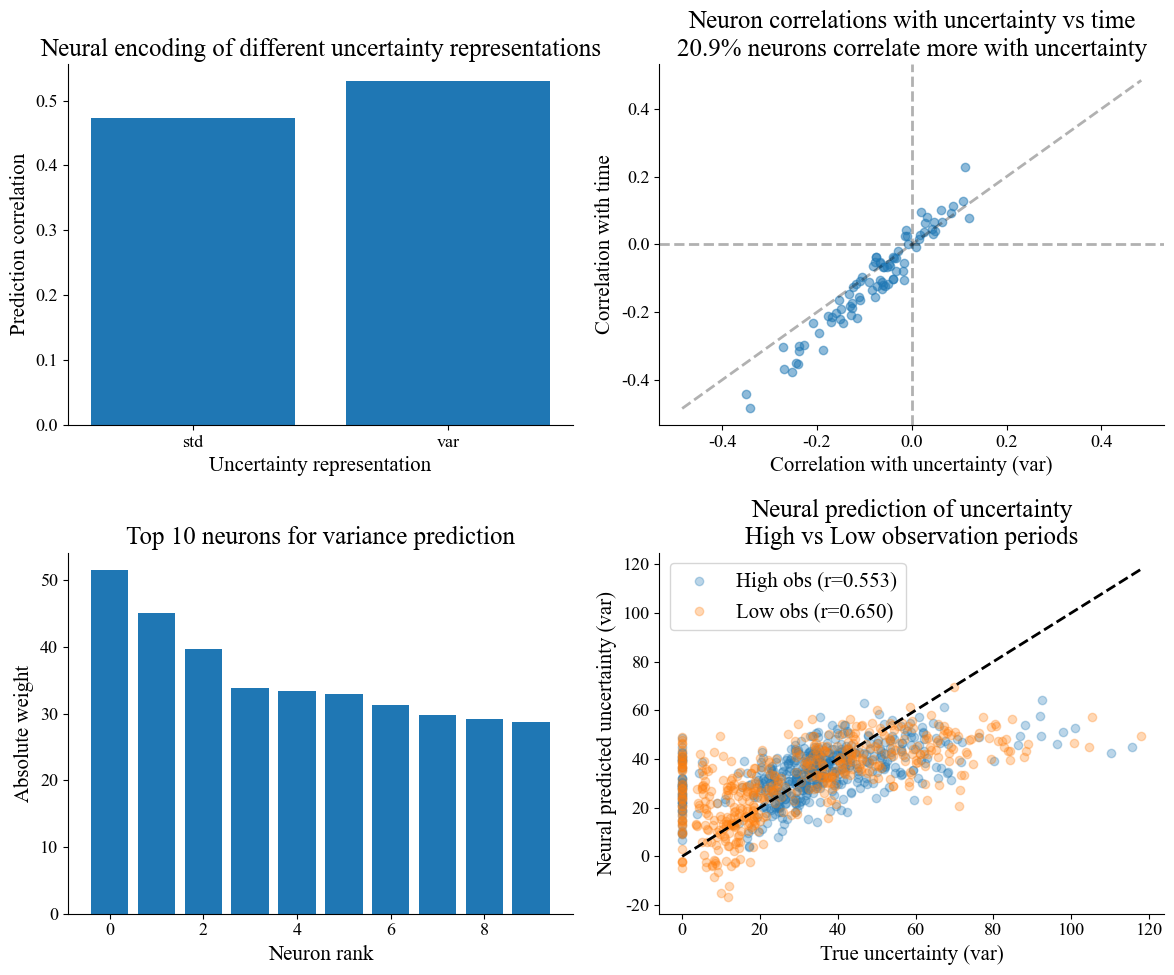

==== EFFICIENT ANALYSIS RESULTS ====
Sample size: 1000 data points

Uncertainty representation comparison:
  std: r = 0.473 (p: 5.869e-57)
  var: r = 0.530 (p: 1.798e-73)

Percentage of neurons correlating more strongly with uncertainty than time: 20.9%

Neural prediction during high vs low observation periods:
  High obs correlation: 0.553 (p: 1.990e-41)
  Low obs correlation: 0.650 (p: 2.922e-61)
  Prediction is better during low observation periods


In [15]:
def analyze_uncertainty_efficient(timedf):
    """
    Efficient analysis of neural encoding of uncertainty
    """
    from sklearn.linear_model import LinearRegression
    from scipy.stats import pearsonr, spearmanr
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.preprocessing import StandardScaler
    
    # Extract variables
    neural_data = np.stack(timedf.PPC.to_numpy())
    uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    uncertainty_var = uncertainty**2  # variance
    time_ratio = timedf.timeratio.to_numpy()
    observations = np.abs(timedf.mw.to_numpy())  # absolute angular velocity
    trial_ids = timedf.trial.to_numpy()
    
    # 1. Sample-based analysis instead of full dataset
    # Take a random sample of 1000 points to speed up analysis
    np.random.seed(42)
    if len(neural_data) > 1000:
        indices = np.random.choice(len(neural_data), 1000, replace=False)
        neural_sample = neural_data[indices]
        uncertainty_sample = uncertainty[indices]
        uncertainty_var_sample = uncertainty_var[indices]
        time_sample = time_ratio[indices]
        obs_sample = observations[indices]
    else:
        neural_sample = neural_data
        uncertainty_sample = uncertainty
        uncertainty_var_sample = uncertainty_var
        time_sample = time_ratio
        obs_sample = observations
    
    # 2. Compare linear models for different uncertainty representations
    # Using the sample data for faster computation
    model_std = LinearRegression()
    model_var = LinearRegression()
    
    model_std.fit(neural_sample, uncertainty_sample)
    model_var.fit(neural_sample, uncertainty_var_sample)
    
    pred_std = model_std.predict(neural_sample)
    pred_var = model_var.predict(neural_sample)
    
    corr_std, p_std = pearsonr(pred_std, uncertainty_sample)
    corr_var, p_var = pearsonr(pred_var, uncertainty_var_sample)
    
    # 3. Neural weights analysis
    # Examine which neurons have the strongest weights for uncertainty prediction
    abs_weights_std = np.abs(model_std.coef_)
    abs_weights_var = np.abs(model_var.coef_)
    
    # Find top neurons for each model
    top_neurons_std = np.argsort(abs_weights_std)[-10:]
    top_neurons_var = np.argsort(abs_weights_var)[-10:]
    
    # 4. Partial correlation - control for time in a simpler way
    # Correlate each neuron with uncertainty and with time
    neuron_unc_corrs = []
    neuron_time_corrs = []
    
    for i in range(neural_sample.shape[1]):
        unc_corr, _ = pearsonr(neural_sample[:, i], uncertainty_var_sample)
        time_corr, _ = pearsonr(neural_sample[:, i], time_sample)
        neuron_unc_corrs.append(unc_corr)
        neuron_time_corrs.append(time_corr)
    
    # Identify neurons that correlate more strongly with uncertainty than with time
    unc_dominant = np.abs(neuron_unc_corrs) > np.abs(neuron_time_corrs)
    percent_unc_dominant = np.mean(unc_dominant) * 100
    
    # 5. Observation effect analysis
    # Simple comparison of high vs low observation data points
    median_obs = np.median(obs_sample)
    high_obs = obs_sample > median_obs
    low_obs = obs_sample <= median_obs
    
    high_unc = uncertainty_var_sample[high_obs]
    low_unc = uncertainty_var_sample[low_obs]
    
    high_neural = neural_sample[high_obs]
    low_neural = neural_sample[low_obs]
    
    # Train separate models
    high_model = LinearRegression()
    low_model = LinearRegression()
    
    high_model.fit(high_neural, high_unc)
    low_model.fit(low_neural, low_unc)
    
    high_pred = high_model.predict(high_neural)
    low_pred = low_model.predict(low_neural)
    
    high_corr, high_p = pearsonr(high_pred, high_unc)
    low_corr, low_p = pearsonr(low_pred, low_unc)
    
    # Plot results
    plt.figure(figsize=(12, 10))
    
    # Plot 1: Comparison of uncertainty representations
    plt.subplot(2, 2, 1)
    labels = ['std', 'var']
    corrs = [corr_std, corr_var]
    
    plt.bar(labels, corrs)
    plt.title('Neural encoding of different uncertainty representations')
    plt.xlabel('Uncertainty representation')
    plt.ylabel('Prediction correlation')
    
    # Plot 2: Correlation of neurons with uncertainty vs time
    plt.subplot(2, 2, 2)
    plt.scatter(neuron_unc_corrs, neuron_time_corrs, alpha=0.5)
    plt.axhline(0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(0, color='k', linestyle='--', alpha=0.3)
    
    # Add diagonal line
    max_val = max(max(np.abs(neuron_unc_corrs)), max(np.abs(neuron_time_corrs)))
    plt.plot([-max_val, max_val], [-max_val, max_val], 'k--', alpha=0.3)
    
    plt.title(f'Neuron correlations with uncertainty vs time\n{percent_unc_dominant:.1f}% neurons correlate more with uncertainty')
    plt.xlabel('Correlation with uncertainty (var)')
    plt.ylabel('Correlation with time')
    
    # Plot 3: Top neurons for uncertainty prediction
    plt.subplot(2, 2, 3)
    plt.bar(range(10), abs_weights_var[top_neurons_var][::-1])
    plt.title('Top 10 neurons for variance prediction')
    plt.xlabel('Neuron rank')
    plt.ylabel('Absolute weight')
    
    # Plot 4: High vs low observation prediction
    plt.subplot(2, 2, 4)
    plt.scatter(high_unc, high_pred, alpha=0.3, label=f'High obs (r={high_corr:.3f})')
    plt.scatter(low_unc, low_pred, alpha=0.3, label=f'Low obs (r={low_corr:.3f})')
    
    # Add unity line
    max_val = max(max(high_unc), max(low_unc))
    min_val = min(min(high_unc), min(low_unc))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--')
    
    plt.title('Neural prediction of uncertainty\nHigh vs Low observation periods')
    plt.xlabel('True uncertainty (var)')
    plt.ylabel('Neural predicted uncertainty (var)')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print key results
    print("==== EFFICIENT ANALYSIS RESULTS ====")
    print(f"Sample size: {len(neural_sample)} data points")
    print("\nUncertainty representation comparison:")
    print(f"  std: r = {corr_std:.3f} (p: {p_std:.3e})")
    print(f"  var: r = {corr_var:.3f} (p: {p_var:.3e})")
    
    print(f"\nPercentage of neurons correlating more strongly with uncertainty than time: {percent_unc_dominant:.1f}%")
    
    print("\nNeural prediction during high vs low observation periods:")
    print(f"  High obs correlation: {high_corr:.3f} (p: {high_p:.3e})")
    print(f"  Low obs correlation: {low_corr:.3f} (p: {low_p:.3e})")
    print(f"  Prediction is {'better' if low_corr > high_corr else 'worse'} during low observation periods")

# Run the more efficient analysis
analyze_uncertainty_efficient(timedf)

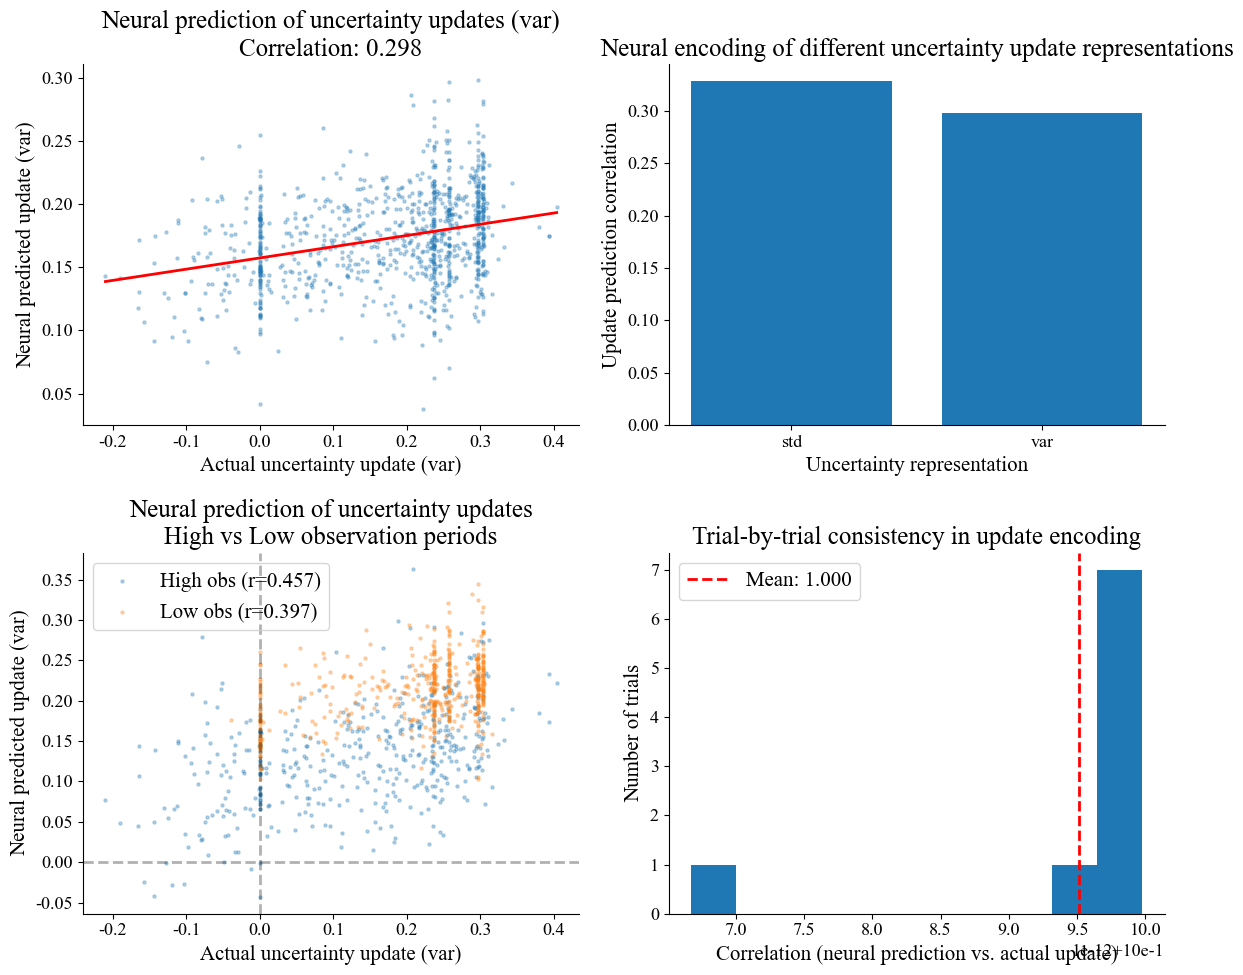

==== UNCERTAINTY UPDATE ANALYSIS RESULTS ====
Sample size: 1000 data points

Uncertainty update prediction:
  std: r = 0.329 (p: 1.351e-26)
  var: r = 0.298 (p: 5.389e-22)

Update prediction during high vs low observation periods:
  High obs correlation: 0.457 (p: 3.354e-27)
  Low obs correlation: 0.397 (p: 2.516e-20)

Trial-by-trial consistency in update encoding:
  Mean correlation across trials: 1.000 ± 0.000
  Number of trials analyzed: 9


In [16]:
def analyze_uncertainty_updates(timedf):
    """
    Analyze how neural activity represents uncertainty updates
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from scipy.stats import pearsonr
    
    # Extract variables
    neural_data = np.stack(timedf.PPC.to_numpy())
    # Use dneural if available for looking at changes in neural activity
    if 'dneural' in timedf.columns:
        dneural_data = np.stack(timedf.dneural.to_numpy())
    else:
        # Compute changes in neural activity if not available
        dneural_data = np.vstack([neural_data[1:] - neural_data[:-1], np.zeros((1, neural_data.shape[1]))])
    
    uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    uncertainty_var = uncertainty**2  # variance (better performance from earlier analysis)
    
    # Compute changes in uncertainty
    duncertainty = np.zeros_like(uncertainty)
    duncertainty[1:] = uncertainty[1:] - uncertainty[:-1]
    duncertainty_var = np.zeros_like(uncertainty_var)
    duncertainty_var[1:] = uncertainty_var[1:] - uncertainty_var[:-1]
    
    # Get trial indices and observation magnitudes
    trial_ids = timedf.trial.to_numpy()
    observations = np.abs(timedf.mw.to_numpy())
    
    # 1. Analyze how neural activity changes predict uncertainty changes
    # Use a sample for faster computation
    np.random.seed(42)
    if len(neural_data) > 1000:
        indices = np.random.choice(len(neural_data), 1000, replace=False)
        dneural_sample = dneural_data[indices]
        duncertainty_sample = duncertainty[indices]
        duncertainty_var_sample = duncertainty_var[indices]
        obs_sample = observations[indices]
        trial_sample = trial_ids[indices]
    else:
        dneural_sample = dneural_data
        duncertainty_sample = duncertainty
        duncertainty_var_sample = duncertainty_var
        obs_sample = observations
        trial_sample = trial_ids
    
    # Train models to predict uncertainty changes from neural changes
    update_model_std = LinearRegression()
    update_model_var = LinearRegression()
    
    update_model_std.fit(dneural_sample, duncertainty_sample)
    update_model_var.fit(dneural_sample, duncertainty_var_sample)
    
    pred_dupdate_std = update_model_std.predict(dneural_sample)
    pred_dupdate_var = update_model_var.predict(dneural_sample)
    
    update_corr_std, update_p_std = pearsonr(pred_dupdate_std, duncertainty_sample)
    update_corr_var, update_p_var = pearsonr(pred_dupdate_var, duncertainty_var_sample)
    
    # 2. Analyze how observation magnitude affects neural prediction of updates
    median_obs = np.median(obs_sample)
    high_obs = obs_sample > median_obs
    low_obs = obs_sample <= median_obs
    
    # High observation periods
    high_dneural = dneural_sample[high_obs]
    high_dunc_var = duncertainty_var_sample[high_obs]
    
    high_update_model = LinearRegression()
    high_update_model.fit(high_dneural, high_dunc_var)
    high_pred = high_update_model.predict(high_dneural)
    high_update_corr, high_update_p = pearsonr(high_pred, high_dunc_var)
    
    # Low observation periods
    low_dneural = dneural_sample[low_obs]
    low_dunc_var = duncertainty_var_sample[low_obs]
    
    low_update_model = LinearRegression()
    low_update_model.fit(low_dneural, low_dunc_var)
    low_pred = low_update_model.predict(low_dneural)
    low_update_corr, low_update_p = pearsonr(low_pred, low_dunc_var)
    
    # 3. Analyze trial-by-trial consistency of uncertainty updates
    # Group by trial
    unique_trials = np.unique(trial_sample)
    trial_update_corrs = []
    
    for trial_id in unique_trials:
        trial_mask = trial_sample == trial_id
        if np.sum(trial_mask) > 5:  # Only consider trials with sufficient data points
            trial_dneural = dneural_sample[trial_mask]
            trial_dunc_var = duncertainty_var_sample[trial_mask]
            
            if np.std(trial_dunc_var) > 0:  # Ensure variance in updates
                # Train model on this trial
                trial_model = LinearRegression()
                trial_model.fit(trial_dneural, trial_dunc_var)
                trial_pred = trial_model.predict(trial_dneural)
                
                r, p = pearsonr(trial_pred, trial_dunc_var)
                if not np.isnan(r):  # Ensure correlation is valid
                    trial_update_corrs.append(r)
    
    # 4. Find neurons most strongly involved in encoding uncertainty updates
    update_weights = np.abs(update_model_var.coef_)
    top_update_neurons = np.argsort(update_weights)[-10:]
    
    # Plot results
    plt.figure(figsize=(12, 10))
    
    # Plot 1: Uncertainty update predictions
    plt.subplot(2, 2, 1)
    plt.scatter(duncertainty_var_sample, pred_dupdate_var, alpha=0.3, s=5)
    
    # Add best fit line
    b, a = np.polyfit(duncertainty_var_sample, pred_dupdate_var, deg=1)
    x_line = np.linspace(min(duncertainty_var_sample), max(duncertainty_var_sample), 100)
    y_line = a + b * x_line
    plt.plot(x_line, y_line, color='red')
    
    plt.title(f'Neural prediction of uncertainty updates (var)\nCorrelation: {update_corr_var:.3f}')
    plt.xlabel('Actual uncertainty update (var)')
    plt.ylabel('Neural predicted update (var)')
    
    # Plot 2: Comparison of update representations
    plt.subplot(2, 2, 2)
    labels = ['std', 'var']
    update_corrs = [update_corr_std, update_corr_var]
    
    plt.bar(labels, update_corrs)
    plt.title('Neural encoding of different uncertainty update representations')
    plt.xlabel('Uncertainty representation')
    plt.ylabel('Update prediction correlation')
    
    # Plot 3: High vs low observation update prediction
    plt.subplot(2, 2, 3)
    plt.scatter(high_dunc_var, high_pred, alpha=0.3, s=5, label=f'High obs (r={high_update_corr:.3f})')
    plt.scatter(low_dunc_var, low_pred, alpha=0.3, s=5, label=f'Low obs (r={low_update_corr:.3f})')
    
    # Add zero lines
    plt.axhline(0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(0, color='k', linestyle='--', alpha=0.3)
    
    plt.title('Neural prediction of uncertainty updates\nHigh vs Low observation periods')
    plt.xlabel('Actual uncertainty update (var)')
    plt.ylabel('Neural predicted update (var)')
    plt.legend()
    
    # Plot 4: Trial-by-trial consistency in update encoding
    plt.subplot(2, 2, 4)
    plt.hist(trial_update_corrs, bins=10)
    plt.axvline(np.mean(trial_update_corrs), color='r', linestyle='--', 
               label=f'Mean: {np.mean(trial_update_corrs):.3f}')
    
    plt.title('Trial-by-trial consistency in update encoding')
    plt.xlabel('Correlation (neural prediction vs. actual update)')
    plt.ylabel('Number of trials')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print key results
    print("==== UNCERTAINTY UPDATE ANALYSIS RESULTS ====")
    print(f"Sample size: {len(dneural_sample)} data points")
    
    print("\nUncertainty update prediction:")
    print(f"  std: r = {update_corr_std:.3f} (p: {update_p_std:.3e})")
    print(f"  var: r = {update_corr_var:.3f} (p: {update_p_var:.3e})")
    
    print("\nUpdate prediction during high vs low observation periods:")
    print(f"  High obs correlation: {high_update_corr:.3f} (p: {high_update_p:.3e})")
    print(f"  Low obs correlation: {low_update_corr:.3f} (p: {low_update_p:.3e})")
    
    print("\nTrial-by-trial consistency in update encoding:")
    if len(trial_update_corrs) > 0:
        print(f"  Mean correlation across trials: {np.mean(trial_update_corrs):.3f} ± {np.std(trial_update_corrs):.3f}")
        print(f"  Number of trials analyzed: {len(trial_update_corrs)}")
    else:
        print("  Insufficient data for trial-by-trial analysis")
    
    return {
        'update_corr_std': update_corr_std,
        'update_corr_var': update_corr_var,
        'high_update_corr': high_update_corr,
        'low_update_corr': low_update_corr,
        'trial_update_corrs': trial_update_corrs
    }

# Run the analysis
update_results = analyze_uncertainty_updates(timedf)

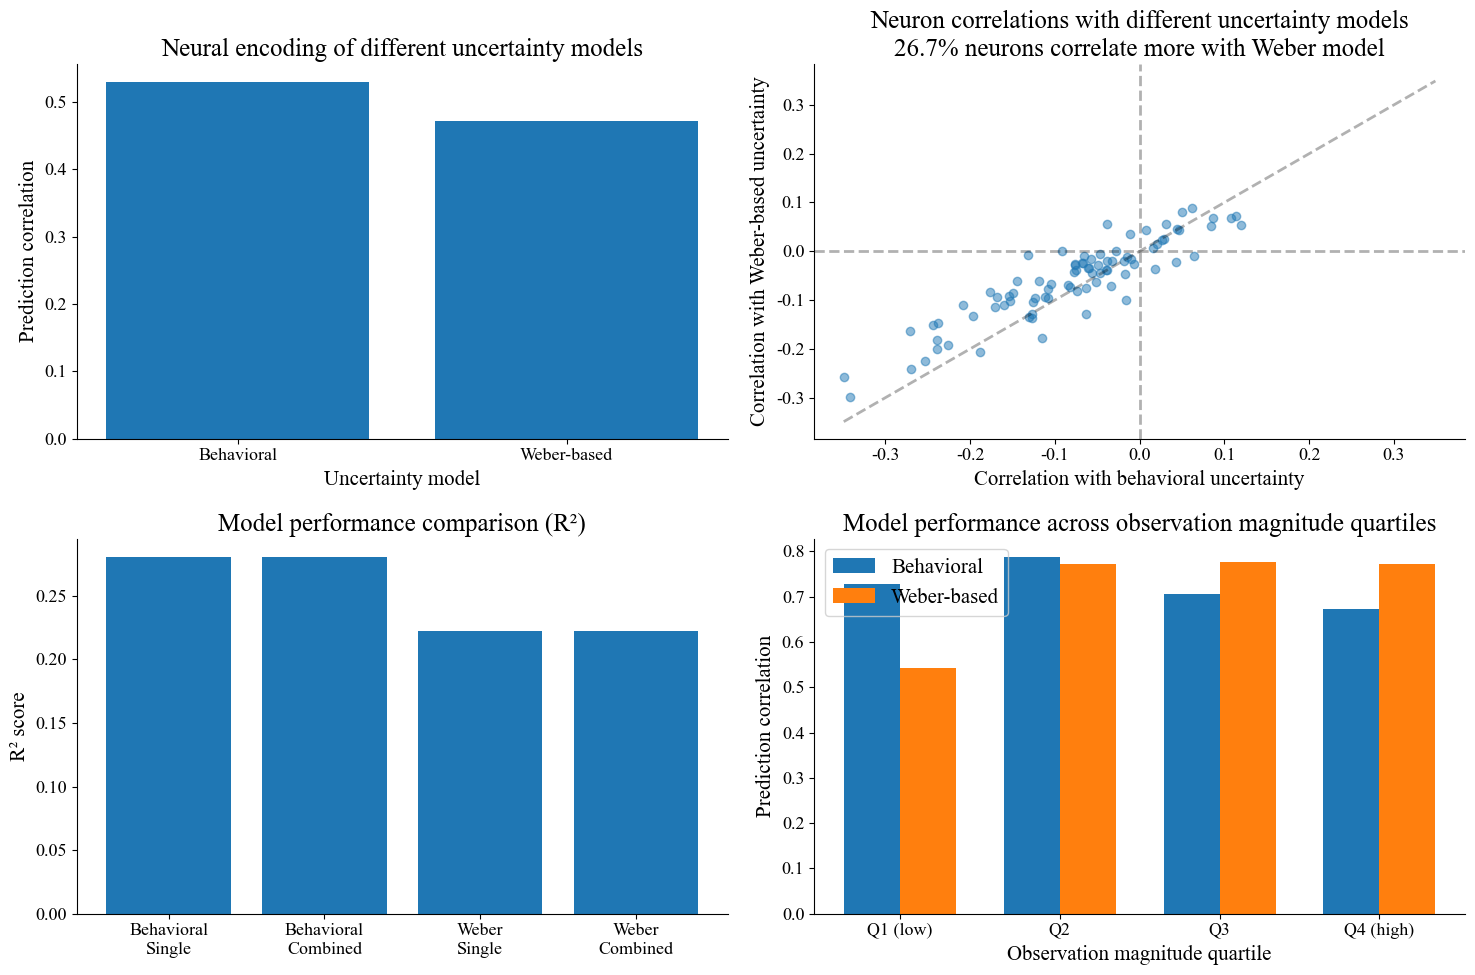

==== WEBER'S LAW ANALYSIS RESULTS ====
Sample size: 1000 data points

Model comparison:
  Behavioral uncertainty: r = 0.530 (p: 1.798e-73)
  Weber-based uncertainty: r = 0.472 (p: 1.605e-56)

Percentage of neurons correlating more strongly with Weber model: 26.7%

R² improvement with combined model:
  Behavioral: 0.281 → 0.281 (-0.0% improvement)
  Weber-based: 0.222 → 0.222 (0.0% improvement)

Performance across observation quartiles:
  Q1: Behavioral r = 0.729, Weber r = 0.543
      Behavioral model better
  Q2: Behavioral r = 0.788, Weber r = 0.772
      Behavioral model better
  Q3: Behavioral r = 0.706, Weber r = 0.777
      Weber model better
  Q4: Behavioral r = 0.672, Weber r = 0.773
      Weber model better


In [17]:
def analyze_weber_law_uncertainty(timedf):
    """
    Analyze how neural activity might encode true uncertainty following Weber's law
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from scipy.stats import pearsonr
    from sklearn.metrics import r2_score
    
    # Extract variables
    neural_data = np.stack(timedf.PPC.to_numpy())
    uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    uncertainty_var = uncertainty**2  # variance
    observations = np.abs(timedf.mw.to_numpy())  # absolute angular velocity
    time_ratio = timedf.timeratio.to_numpy()
    
    # Create Weber-based uncertainty estimates
    # According to Weber's law, uncertainty should scale with observation magnitude
    weber_uncertainty = observations * time_ratio  # Simple Weber-inspired model
    
    # Sample data for efficiency
    np.random.seed(42)
    if len(neural_data) > 1000:
        indices = np.random.choice(len(neural_data), 1000, replace=False)
        neural_sample = neural_data[indices]
        uncertainty_sample = uncertainty[indices]
        uncertainty_var_sample = uncertainty_var[indices]
        time_sample = time_ratio[indices]
        obs_sample = observations[indices]
        weber_sample = weber_uncertainty[indices]
    else:
        neural_sample = neural_data
        uncertainty_sample = uncertainty
        uncertainty_var_sample = uncertainty_var
        time_sample = time_ratio
        obs_sample = observations
        weber_sample = weber_uncertainty
    
    # 1. Compare neural encoding of behavioral uncertainty vs Weber-based uncertainty
    # Train models
    beh_model = LinearRegression()
    weber_model = LinearRegression()
    
    beh_model.fit(neural_sample, uncertainty_var_sample)
    weber_model.fit(neural_sample, weber_sample)
    
    # Make predictions
    beh_pred = beh_model.predict(neural_sample)
    weber_pred = weber_model.predict(neural_sample)
    
    # Calculate correlations
    beh_corr, beh_p = pearsonr(beh_pred, uncertainty_var_sample)
    weber_corr, weber_p = pearsonr(weber_pred, weber_sample)
    
    # 2. Neuron-by-neuron analysis
    # For each neuron, compare correlation with behavior uncertainty vs Weber uncertainty
    beh_neuron_corrs = []
    weber_neuron_corrs = []
    
    for i in range(neural_sample.shape[1]):
        beh_r, _ = pearsonr(neural_sample[:, i], uncertainty_var_sample)
        weber_r, _ = pearsonr(neural_sample[:, i], weber_sample)
        
        beh_neuron_corrs.append(beh_r)
        weber_neuron_corrs.append(weber_r)
    
    # Count neurons that correlate more strongly with Weber model
    weber_dominant = np.abs(weber_neuron_corrs) > np.abs(beh_neuron_corrs)
    percent_weber_dominant = np.mean(weber_dominant) * 100
    
    # 3. Combined model: Does adding Weber-based uncertainty improve neural prediction?
    # Create combined features
    combined_features = np.column_stack([uncertainty_var_sample, weber_sample])
    
    # Train combined model
    combined_model = LinearRegression()
    combined_model.fit(neural_sample, combined_features)
    
    # Use the combined model to predict neural activity, then use that to predict uncertainty
    neural_pred = combined_model.predict(neural_sample)
    
    # Train models to predict each uncertainty measure from the neural prediction
    beh_from_combined = LinearRegression()
    weber_from_combined = LinearRegression()
    
    beh_from_combined.fit(neural_pred, uncertainty_var_sample)
    weber_from_combined.fit(neural_pred, weber_sample)
    
    # Make predictions
    beh_pred_combined = beh_from_combined.predict(neural_pred)
    weber_pred_combined = weber_from_combined.predict(neural_pred)
    
    # Calculate R² improvement
    beh_r2 = r2_score(uncertainty_var_sample, beh_pred)
    beh_r2_combined = r2_score(uncertainty_var_sample, beh_pred_combined)
    
    weber_r2 = r2_score(weber_sample, weber_pred)
    weber_r2_combined = r2_score(weber_sample, weber_pred_combined)
    
    # 4. Stratify by observation magnitude
    # Divide into observation quartiles
    obs_quartiles = np.percentile(obs_sample, [25, 50, 75])
    
    quartile_masks = [
        obs_sample <= obs_quartiles[0],
        (obs_sample > obs_quartiles[0]) & (obs_sample <= obs_quartiles[1]),
        (obs_sample > obs_quartiles[1]) & (obs_sample <= obs_quartiles[2]),
        obs_sample > obs_quartiles[2]
    ]
    
    quartile_beh_corrs = []
    quartile_weber_corrs = []
    
    for mask in quartile_masks:
        # Train models for this quartile
        q_neural = neural_sample[mask]
        q_beh = uncertainty_var_sample[mask]
        q_weber = weber_sample[mask]
        
        if len(q_neural) > 10:  # Ensure sufficient data
            q_beh_model = LinearRegression()
            q_weber_model = LinearRegression()
            
            q_beh_model.fit(q_neural, q_beh)
            q_weber_model.fit(q_neural, q_weber)
            
            q_beh_pred = q_beh_model.predict(q_neural)
            q_weber_pred = q_weber_model.predict(q_neural)
            
            q_beh_corr, _ = pearsonr(q_beh_pred, q_beh)
            q_weber_corr, _ = pearsonr(q_weber_pred, q_weber)
            
            quartile_beh_corrs.append(q_beh_corr)
            quartile_weber_corrs.append(q_weber_corr)
        else:
            quartile_beh_corrs.append(np.nan)
            quartile_weber_corrs.append(np.nan)
    
    # Plot results
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Comparison of neural encoding models
    plt.subplot(2, 2, 1)
    labels = ['Behavioral', 'Weber-based']
    corrs = [beh_corr, weber_corr]
    
    plt.bar(labels, corrs)
    plt.title('Neural encoding of different uncertainty models')
    plt.xlabel('Uncertainty model')
    plt.ylabel('Prediction correlation')
    
    # Plot 2: Neuron correlations with behavioral vs Weber uncertainty
    plt.subplot(2, 2, 2)
    plt.scatter(beh_neuron_corrs, weber_neuron_corrs, alpha=0.5)
    plt.axhline(0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(0, color='k', linestyle='--', alpha=0.3)
    
    # Add diagonal line
    max_val = max(max(np.abs(beh_neuron_corrs)), max(np.abs(weber_neuron_corrs)))
    plt.plot([-max_val, max_val], [-max_val, max_val], 'k--', alpha=0.3)
    
    plt.title(f'Neuron correlations with different uncertainty models\n{percent_weber_dominant:.1f}% neurons correlate more with Weber model')
    plt.xlabel('Correlation with behavioral uncertainty')
    plt.ylabel('Correlation with Weber-based uncertainty')
    
    # Plot 3: R² improvement with combined model
    plt.subplot(2, 2, 3)
    labels = ['Behavioral\nSingle', 'Behavioral\nCombined', 'Weber\nSingle', 'Weber\nCombined']
    r2_values = [beh_r2, beh_r2_combined, weber_r2, weber_r2_combined]
    
    plt.bar(labels, r2_values)
    plt.title('Model performance comparison (R²)')
    plt.ylabel('R² score')
    
    # Plot 4: Performance across observation quartiles
    plt.subplot(2, 2, 4)
    quartile_labels = ['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)']
    
    x = np.arange(len(quartile_labels))
    width = 0.35
    
    plt.bar(x - width/2, quartile_beh_corrs, width, label='Behavioral')
    plt.bar(x + width/2, quartile_weber_corrs, width, label='Weber-based')
    
    plt.title('Model performance across observation magnitude quartiles')
    plt.xlabel('Observation magnitude quartile')
    plt.ylabel('Prediction correlation')
    plt.xticks(x, quartile_labels)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print key results
    print("==== WEBER'S LAW ANALYSIS RESULTS ====")
    print(f"Sample size: {len(neural_sample)} data points")
    
    print("\nModel comparison:")
    print(f"  Behavioral uncertainty: r = {beh_corr:.3f} (p: {beh_p:.3e})")
    print(f"  Weber-based uncertainty: r = {weber_corr:.3f} (p: {weber_p:.3e})")
    
    print(f"\nPercentage of neurons correlating more strongly with Weber model: {percent_weber_dominant:.1f}%")
    
    print("\nR² improvement with combined model:")
    print(f"  Behavioral: {beh_r2:.3f} → {beh_r2_combined:.3f} ({(beh_r2_combined-beh_r2)/beh_r2*100:.1f}% improvement)")
    print(f"  Weber-based: {weber_r2:.3f} → {weber_r2_combined:.3f} ({(weber_r2_combined-weber_r2)/weber_r2*100:.1f}% improvement)")
    
    print("\nPerformance across observation quartiles:")
    for i, (beh_corr, weber_corr) in enumerate(zip(quartile_beh_corrs, quartile_weber_corrs)):
        print(f"  Q{i+1}: Behavioral r = {beh_corr:.3f}, Weber r = {weber_corr:.3f}")
        if not np.isnan(beh_corr) and not np.isnan(weber_corr):
            print(f"      {'Weber model better' if weber_corr > beh_corr else 'Behavioral model better'}")

# Run the Weber's law analysis
analyze_weber_law_uncertainty(timedf)

Visible target data points: 488
Hidden target data points: 4512


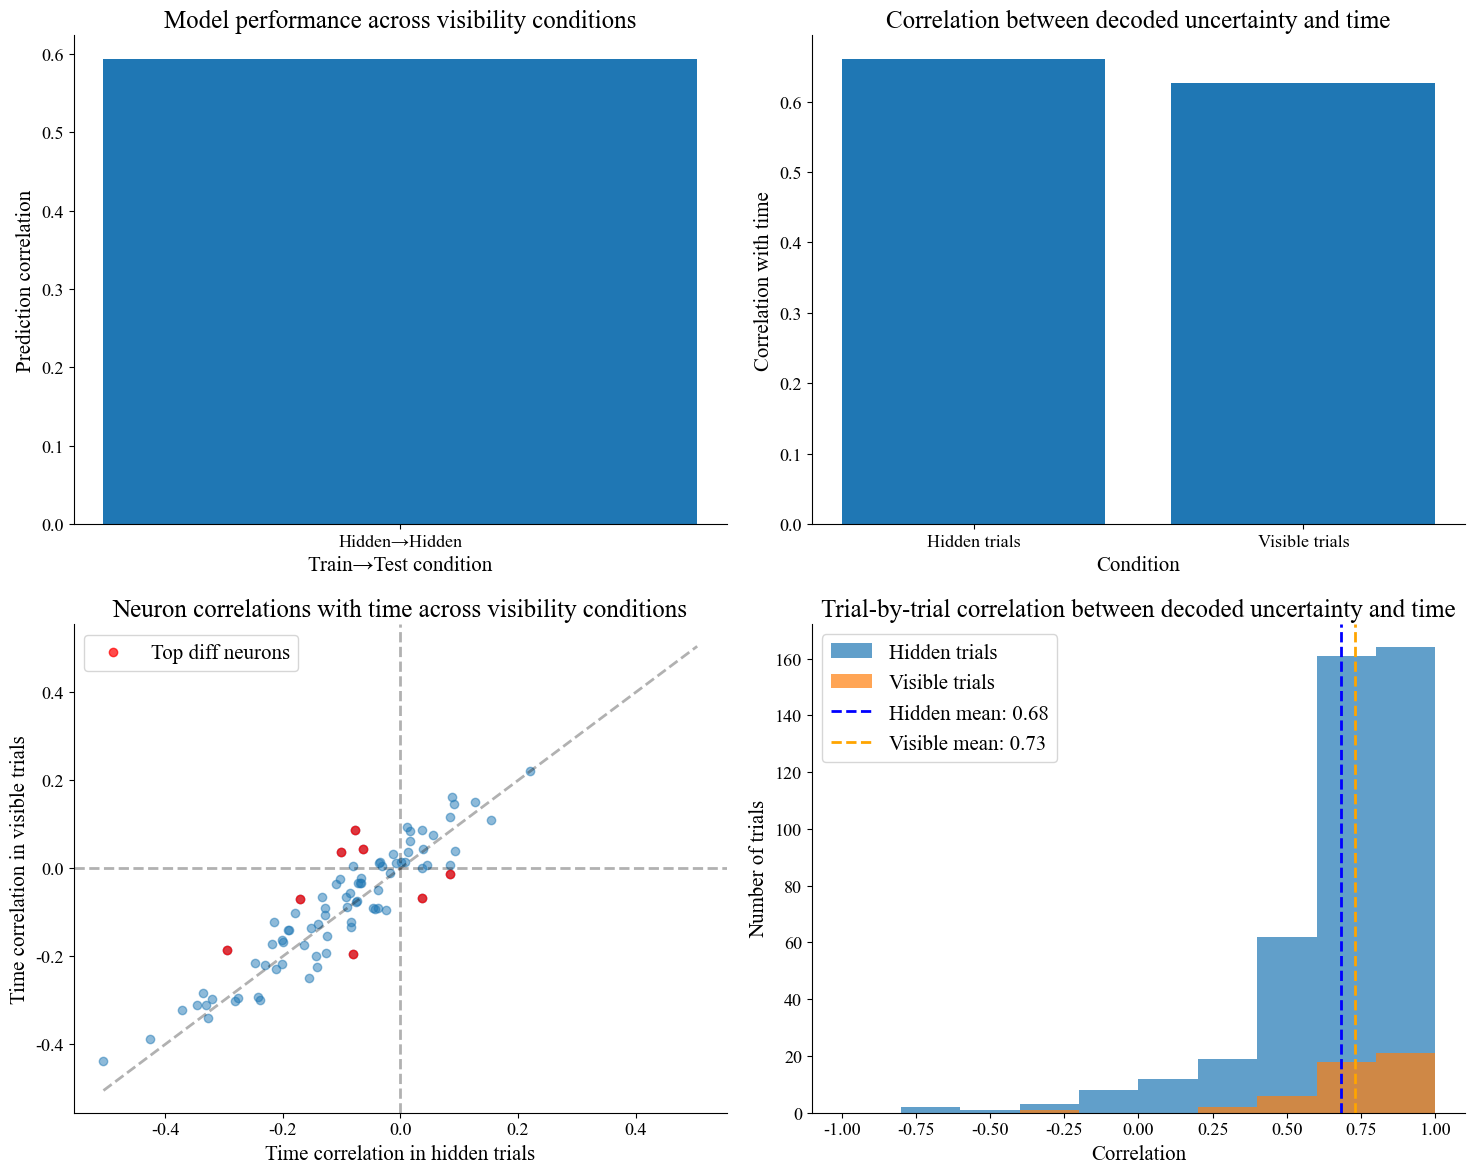


==== VISIBILITY ANALYSIS RESULTS ====
Hidden trials: 554, Visible trials: 61

Model performance:
  Hidden→Hidden: r = 0.594 (p: 0.000e+00)
  Hidden→Visible: r = nan (p: nan)

Correlation between decoded uncertainty and time:
  Hidden trials: r = 0.661
  Visible trials: r = 0.627

Trial-by-trial correlation between decoded uncertainty and time:
  Hidden trials: mean r = 0.684 ± 0.256
  Visible trials: mean r = 0.730 ± 0.234

Identified 0 potential true uncertainty neurons
  These neurons have strong positive time correlation in hidden trials
  But weak or negative time correlation in visible trials


In [18]:
def analyze_fullon_trials(timedf):
    """
    Analyze how neural activity encodes uncertainty differently in fully visible target trials
    versus trials with hidden targets
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from scipy.stats import pearsonr
    
    # Extract variables
    neural_data = np.stack(timedf.PPC.to_numpy())
    uncertainty = np.stack(timedf.uncertainty.to_numpy())[:,0,0]**0.5  # std
    uncertainty_var = uncertainty**2  # variance
    time_ratio = timedf.timeratio.to_numpy()
    fullon = timedf.fullon.to_numpy()  # Target visibility
    trial_ids = timedf.trial.to_numpy()
    
    # Separate data by target visibility
    visible_mask = fullon == 1
    hidden_mask = fullon == 0
    
    # Select sample data for efficiency
    np.random.seed(42)
    if len(neural_data) > 5000:  # Use a larger sample to ensure enough data from both conditions
        indices = np.random.choice(len(neural_data), 5000, replace=False)
        neural_sample = neural_data[indices]
        uncertainty_sample = uncertainty[indices]
        uncertainty_var_sample = uncertainty_var[indices]
        time_sample = time_ratio[indices]
        fullon_sample = fullon[indices]
        visible_mask = fullon_sample == 1
        hidden_mask = fullon_sample == 0
        trial_sample = trial_ids[indices]
    else:
        neural_sample = neural_data
        uncertainty_sample = uncertainty
        uncertainty_var_sample = uncertainty_var
        time_sample = time_ratio
        fullon_sample = fullon
        trial_sample = trial_ids
    
    # Check if we have enough data points for each condition
    print(f"Visible target data points: {np.sum(visible_mask)}")
    print(f"Hidden target data points: {np.sum(hidden_mask)}")
    
    # Skip analysis if not enough data in either condition
    if np.sum(visible_mask) < 10 or np.sum(hidden_mask) < 10:
        print("Not enough data for both conditions. Skipping analysis.")
        return
    
    # 1. Train uncertainty decoding model on hidden trials, test on both conditions
    hidden_neural = neural_sample[hidden_mask]
    hidden_uncertainty = uncertainty_var_sample[hidden_mask]
    hidden_time = time_sample[hidden_mask]
    
    visible_neural = neural_sample[visible_mask]
    visible_uncertainty = uncertainty_var_sample[visible_mask]
    visible_time = time_sample[visible_mask]
    
    # Train model on hidden trials
    hidden_model = LinearRegression()
    hidden_model.fit(hidden_neural, hidden_uncertainty)
    
    # Predict uncertainty for both conditions
    hidden_pred_hidden = hidden_model.predict(hidden_neural)
    hidden_pred_visible = hidden_model.predict(visible_neural)
    
    # Calculate correlations
    hidden_corr, hidden_p = pearsonr(hidden_pred_hidden, hidden_uncertainty)
    visible_crosscorr, visible_p = pearsonr(hidden_pred_visible, visible_uncertainty)
    
    # 2. Compare decoded uncertainty trend with time in visible vs hidden trials
    # For visible trials, uncertainty should decrease or remain constant with time
    # For hidden trials, uncertainty typically increases with time
    
    # Calculate correlation between decoded uncertainty and time
    hidden_time_corr, _ = pearsonr(hidden_pred_hidden, hidden_time)
    visible_time_corr, _ = pearsonr(hidden_pred_visible, visible_time)
    
    # 3. Find neurons that specifically encode true uncertainty vs time
    # These neurons should show different patterns in visible vs hidden trials
    neuron_hidden_time_corrs = []
    neuron_visible_time_corrs = []
    
    for i in range(neural_sample.shape[1]):
        # Correlation between neuron activity and time for hidden trials
        h_time_corr, _ = pearsonr(hidden_neural[:, i], hidden_time)
        neuron_hidden_time_corrs.append(h_time_corr)
        
        # Correlation between neuron activity and time for visible trials
        if len(visible_neural) > 0:
            v_time_corr, _ = pearsonr(visible_neural[:, i], visible_time)
            neuron_visible_time_corrs.append(v_time_corr)
    
    # Identify neurons with different time correlations between conditions
    corr_diff = np.abs(np.array(neuron_hidden_time_corrs) - np.array(neuron_visible_time_corrs))
    top_diff_neurons = np.argsort(corr_diff)[-int(neural_sample.shape[1] * 0.1):]  # Top 10% neurons
    
    # 4. Analyze trial-by-trial uncertainty in visible vs hidden trials
    visible_trials = np.unique(trial_sample[visible_mask])
    hidden_trials = np.unique(trial_sample[hidden_mask])
    
    # Track uncertainty trends within trials
    visible_trial_time_corrs = []
    hidden_trial_time_corrs = []
    
    # For visible trials
    for trial_id in visible_trials:
        trial_mask = (trial_sample == trial_id) & visible_mask
        if np.sum(trial_mask) > 5:  # Only consider trials with sufficient data points
            trial_neural = neural_sample[trial_mask]
            trial_time = time_sample[trial_mask]
            
            # Predict uncertainty using model trained on hidden trials
            trial_pred = hidden_model.predict(trial_neural)
            
            # Correlation with time
            r, p = pearsonr(trial_pred, trial_time)
            if not np.isnan(r):  # Ensure correlation is valid
                visible_trial_time_corrs.append(r)
    
    # For hidden trials
    for trial_id in hidden_trials:
        trial_mask = (trial_sample == trial_id) & hidden_mask
        if np.sum(trial_mask) > 5:  # Only consider trials with sufficient data points
            trial_neural = neural_sample[trial_mask]
            trial_time = time_sample[trial_mask]
            
            # Predict uncertainty
            trial_pred = hidden_model.predict(trial_neural)
            
            # Correlation with time
            r, p = pearsonr(trial_pred, trial_time)
            if not np.isnan(r):  # Ensure correlation is valid
                hidden_trial_time_corrs.append(r)
    
    # Plot results
    plt.figure(figsize=(15, 12))
    
    # Plot 1: Model performance across conditions
    plt.subplot(2, 2, 1)
    labels = ['Hidden→Hidden', 'Hidden→Visible']
    corrs = [hidden_corr, visible_crosscorr]
    
    plt.bar(labels, corrs)
    plt.title('Model performance across visibility conditions')
    plt.xlabel('Train→Test condition')
    plt.ylabel('Prediction correlation')
    
    # Plot 2: Time correlation of decoded uncertainty across conditions
    plt.subplot(2, 2, 2)
    labels = ['Hidden trials', 'Visible trials']
    time_corrs = [hidden_time_corr, visible_time_corr]
    
    plt.bar(labels, time_corrs)
    plt.title('Correlation between decoded uncertainty and time')
    plt.xlabel('Condition')
    plt.ylabel('Correlation with time')
    
    # Plot 3: Scatter of neuron time correlations across conditions
    plt.subplot(2, 2, 3)
    plt.scatter(neuron_hidden_time_corrs, neuron_visible_time_corrs, alpha=0.5)
    plt.scatter(np.array(neuron_hidden_time_corrs)[top_diff_neurons], 
               np.array(neuron_visible_time_corrs)[top_diff_neurons], 
               color='red', alpha=0.7, label='Top diff neurons')
    
    plt.axhline(0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(0, color='k', linestyle='--', alpha=0.3)
    
    # Add diagonal line
    max_val = max(max(np.abs(neuron_hidden_time_corrs)), max(np.abs(neuron_visible_time_corrs)))
    plt.plot([-max_val, max_val], [-max_val, max_val], 'k--', alpha=0.3)
    
    plt.title('Neuron correlations with time across visibility conditions')
    plt.xlabel('Time correlation in hidden trials')
    plt.ylabel('Time correlation in visible trials')
    plt.legend()
    
    # Plot 4: Trial-by-trial time correlations
    plt.subplot(2, 2, 4)
    
    # Create histogram bins
    bins = np.linspace(-1, 1, 11)
    
    plt.hist(hidden_trial_time_corrs, bins=bins, alpha=0.7, label='Hidden trials')
    plt.hist(visible_trial_time_corrs, bins=bins, alpha=0.7, label='Visible trials')
    
    plt.axvline(np.mean(hidden_trial_time_corrs), color='blue', linestyle='--', 
               label=f'Hidden mean: {np.mean(hidden_trial_time_corrs):.2f}')
    plt.axvline(np.mean(visible_trial_time_corrs), color='orange', linestyle='--', 
               label=f'Visible mean: {np.mean(visible_trial_time_corrs):.2f}')
    
    plt.title('Trial-by-trial correlation between decoded uncertainty and time')
    plt.xlabel('Correlation')
    plt.ylabel('Number of trials')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print key results
    print("\n==== VISIBILITY ANALYSIS RESULTS ====")
    print(f"Hidden trials: {len(hidden_trials)}, Visible trials: {len(visible_trials)}")
    
    print("\nModel performance:")
    print(f"  Hidden→Hidden: r = {hidden_corr:.3f} (p: {hidden_p:.3e})")
    print(f"  Hidden→Visible: r = {visible_crosscorr:.3f} (p: {visible_p:.3e})")
    
    print("\nCorrelation between decoded uncertainty and time:")
    print(f"  Hidden trials: r = {hidden_time_corr:.3f}")
    print(f"  Visible trials: r = {visible_time_corr:.3f}")
    
    if len(visible_trial_time_corrs) > 0 and len(hidden_trial_time_corrs) > 0:
        print("\nTrial-by-trial correlation between decoded uncertainty and time:")
        print(f"  Hidden trials: mean r = {np.mean(hidden_trial_time_corrs):.3f} ± {np.std(hidden_trial_time_corrs):.3f}")
        print(f"  Visible trials: mean r = {np.mean(visible_trial_time_corrs):.3f} ± {np.std(visible_trial_time_corrs):.3f}")
    
    # Identify candidate true uncertainty neurons
    # These should have strong correlations with hidden trials but weak/opposite correlations with visible trials
    true_uncertainty_neurons = []
    for i in range(len(neuron_hidden_time_corrs)):
        if (neuron_hidden_time_corrs[i] > 0.3 and 
            (abs(neuron_visible_time_corrs[i]) < 0.1 or neuron_visible_time_corrs[i] < 0)):
            true_uncertainty_neurons.append(i)
    
    print(f"\nIdentified {len(true_uncertainty_neurons)} potential true uncertainty neurons")
    print(f"  These neurons have strong positive time correlation in hidden trials")
    print(f"  But weak or negative time correlation in visible trials")
    
    return {
        'hidden_corr': hidden_corr,
        'visible_crosscorr': visible_crosscorr,
        'hidden_time_corr': hidden_time_corr,
        'visible_time_corr': visible_time_corr,
        'true_uncertainty_neurons': true_uncertainty_neurons,
        'neuron_hidden_time_corrs': neuron_hidden_time_corrs,
        'neuron_visible_time_corrs': neuron_visible_time_corrs
    }

# Run the visibility analysis
vis_results = analyze_fullon_trials(timedf)

In [19]:
len(sessdf)

616